# 99 Comparador de Resultados Nested 5x3

Cuaderno para consolidar y comparar automaticamente los resultados generados en `outputs_nested5x3`.

Objetivos:
- descubrir ejecuciones disponibles (aunque esten incompletas),
- unificar `summary`, `fold_metrics`, `predictions` y `errors`,
- construir tablas comparativas por trait/modelo/cuaderno,
- exportar un informe consolidado en CSV y Excel.


## Referencias metodologicas (fuentes oficiales)

- Nested CV en scikit-learn: https://scikit-learn.org/stable/auto_examples/model_selection/plot_nested_cross_validation_iris.html
- `pandas.merge(..., validate=...)`: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.merge.html
- `pivot_table`: https://pandas.pydata.org/pandas-docs/version/2.1.0rc0/reference/api/pandas.DataFrame.pivot_table.html
- `GroupBy`: https://pandas.pydata.org/docs/reference/groupby.html
- Wilcoxon pareado (SciPy): https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.wilcoxon.html


In [58]:
from __future__ import annotations

from pathlib import Path
import itertools
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

try:
    from scipy.stats import wilcoxon
    SCIPY_AVAILABLE = True
except Exception as exc:
    SCIPY_AVAILABLE = False
    SCIPY_IMPORT_ERROR = str(exc)

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid')

print('pandas:', pd.__version__)
print('numpy:', np.__version__)
print('scipy disponible:', SCIPY_AVAILABLE)
if not SCIPY_AVAILABLE:
    print('[WARN] scipy no disponible:', SCIPY_IMPORT_ERROR)


pandas: 2.2.3
numpy: 2.0.2
scipy disponible: True


In [59]:
# =========================
# Configuracion
# =========================
def _run_dir_count(base: Path) -> int:
    if not base.exists() or not base.is_dir():
        return -1
    return sum(1 for p in base.iterdir() if p.is_dir() and not p.name.startswith('_'))


def resolve_output_base() -> Path:
    candidates = [
        Path('nested5x3_unificados') / 'outputs_nested5x3',
        Path('outputs_nested5x3'),
        Path.cwd() / 'nested5x3_unificados' / 'outputs_nested5x3',
        Path.cwd() / 'outputs_nested5x3',
    ]

    counts = [(c, _run_dir_count(c)) for c in candidates]
    with_runs = [x for x in counts if x[1] > 0]
    if with_runs:
        return sorted(with_runs, key=lambda t: t[1], reverse=True)[0][0]

    existing = [c for c, n in counts if n >= 0]
    if existing:
        return existing[0]

    return Path('nested5x3_unificados') / 'outputs_nested5x3'


OUTPUT_BASE = resolve_output_base()
EXPORT_DIR = OUTPUT_BASE / '_comparativas'
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

SUMMARY_FILE = 'summary_nested5x3.csv'
FOLDS_FILE = 'fold_metrics_nested5x3.csv'
PREDS_FILE = 'predictions_oof_outer_nested5x3.csv'
ERRORS_FILE = 'errors_nested5x3.csv'

PRIMARY_SORT = ['trait', 'r2', 'pearson_r', 'rmse']
PRIMARY_ASC = [True, False, False, True]

print('OUTPUT_BASE:', OUTPUT_BASE.resolve())
print('EXPORT_DIR:', EXPORT_DIR.resolve())


def resolve_legacy_53_dir() -> Path:
    candidates = [
        Path('nested5x3_unificados') / 'results' / 'snp_blocks_notebook_nested5x3',
        Path('results') / 'snp_blocks_notebook_nested5x3',
        Path.cwd() / 'nested5x3_unificados' / 'results' / 'snp_blocks_notebook_nested5x3',
        Path.cwd() / 'results' / 'snp_blocks_notebook_nested5x3',
    ]
    for c in candidates:
        if c.exists() and c.is_dir():
            return c
    return candidates[0]


def resolve_legacy_gblup_dir() -> Path:
    candidates = [
        Path('nested5x3_unificados') / 'results' / 'snp_blocks_notebook_nested5x3_gblup',
        Path('results') / 'snp_blocks_notebook_nested5x3_gblup',
        Path.cwd() / 'nested5x3_unificados' / 'results' / 'snp_blocks_notebook_nested5x3_gblup',
        Path.cwd() / 'results' / 'snp_blocks_notebook_nested5x3_gblup',
    ]
    for c in candidates:
        if c.exists() and c.is_dir():
            return c
    return candidates[0]


LEGACY_53_DIR = resolve_legacy_53_dir()
LEGACY_GBLUP_DIR = resolve_legacy_gblup_dir()
print('LEGACY_53_DIR:', LEGACY_53_DIR.resolve())
print('LEGACY_GBLUP_DIR:', LEGACY_GBLUP_DIR.resolve())


OUTPUT_BASE: C:\Users\Reyes\OneDrive\PC_REYES\Master_Big_Data_Data_Science\14MBID\2026\Code\repo\outputs_nested5x3
EXPORT_DIR: C:\Users\Reyes\OneDrive\PC_REYES\Master_Big_Data_Data_Science\14MBID\2026\Code\repo\outputs_nested5x3\_comparativas
LEGACY_53_DIR: C:\Users\Reyes\OneDrive\PC_REYES\Master_Big_Data_Data_Science\14MBID\2026\Code\repo\results\snp_blocks_notebook_nested5x3
LEGACY_GBLUP_DIR: C:\Users\Reyes\OneDrive\PC_REYES\Master_Big_Data_Data_Science\14MBID\2026\Code\repo\results\snp_blocks_notebook_nested5x3_gblup


In [60]:
# =========================
# Utilidades de carga robusta
# =========================
def list_run_dirs(base: Path) -> list[Path]:
    if not base.exists():
        return []
    return sorted([p for p in base.iterdir() if p.is_dir() and not p.name.startswith('_')])


def read_csv_safe(path: Path, allow_empty: bool = False) -> pd.DataFrame:
    try:
        return pd.read_csv(path)
    except pd.errors.EmptyDataError:
        # Caso tipico de errors_nested5x3.csv vacio cuando no hubo errores.
        if allow_empty:
            return pd.DataFrame()
        print(f'[WARN] {path.name} esta vacio (sin cabeceras).')
        return pd.DataFrame()
    except Exception as exc:
        print(f'[WARN] No se pudo leer {path.name}: {exc}')
        return pd.DataFrame()


def add_run_columns(df: pd.DataFrame, run_dir: Path) -> pd.DataFrame:
    if df.empty:
        return df
    out = df.copy()
    out['run_name'] = run_dir.name
    out['run_path'] = str(run_dir)
    return out


def load_run_payload(run_dir: Path) -> dict:
    paths = {
        'summary': run_dir / SUMMARY_FILE,
        'folds': run_dir / FOLDS_FILE,
        'preds': run_dir / PREDS_FILE,
        'errors': run_dir / ERRORS_FILE,
    }

    payload = {}
    for k, p in paths.items():
        df = read_csv_safe(p, allow_empty=(k == 'errors')) if p.exists() else pd.DataFrame()
        payload[k] = add_run_columns(df, run_dir)

    meta = {
        'run_name': run_dir.name,
        'has_summary': len(payload['summary']) > 0,
        'has_folds': len(payload['folds']) > 0,
        'has_preds': len(payload['preds']) > 0,
        'has_errors': len(payload['errors']) > 0,
        'n_summary': len(payload['summary']),
        'n_folds': len(payload['folds']),
        'n_preds': len(payload['preds']),
        'n_errors': len(payload['errors']),
    }
    return {'meta': meta, **payload}



def enrich_legacy_cv_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    cv_outer_inf = pd.Series(np.nan, index=out.index, dtype=object)
    cv_inner_inf = pd.Series(np.nan, index=out.index, dtype=object)

    if 'cv' in out.columns:
        cv_txt = out['cv'].astype(str)
        parsed = cv_txt.str.extract(r'outer=(?P<outer>\d+),\s*inner=(?P<inner>\d+),\s*random_state=(?P<seed>\d+)')

        outer_n = pd.to_numeric(parsed['outer'], errors='coerce')
        inner_n = pd.to_numeric(parsed['inner'], errors='coerce')
        seed_n = pd.to_numeric(parsed['seed'], errors='coerce')

        mask_outer = outer_n.notna() & seed_n.notna()
        mask_inner = inner_n.notna() & seed_n.notna()

        cv_outer_inf.loc[mask_outer] = [
            f"KFold({int(o)}, shuffle=True, random_state={int(s)})"
            for o, s in zip(outer_n[mask_outer], seed_n[mask_outer])
        ]
        cv_inner_inf.loc[mask_inner] = [
            f"KFold({int(i)}, shuffle=True, random_state={int(s)})"
            for i, s in zip(inner_n[mask_inner], seed_n[mask_inner])
        ]

    if 'cv_outer' not in out.columns:
        out['cv_outer'] = cv_outer_inf
    else:
        out['cv_outer'] = out['cv_outer'].where(out['cv_outer'].notna(), cv_outer_inf)

    if 'cv_inner' not in out.columns:
        out['cv_inner'] = cv_inner_inf
    else:
        out['cv_inner'] = out['cv_inner'].where(out['cv_inner'].notna(), cv_inner_inf)

    return out


def load_legacy_summary_payload(legacy_dir: Path, run_name: str, representation_default: str = 'snp_direct') -> dict:
    summary_path = legacy_dir / 'all_results.csv'

    summary_df = pd.DataFrame()
    if summary_path.exists():
        summary_df = read_csv_safe(summary_path)

    if not summary_df.empty:
        summary_df = summary_df.copy()

        rename_map = {
            'n_snps': 'n_features',
            'params': 'best_params_mode_outer',
        }
        summary_df = summary_df.rename(columns={k: v for k, v in rename_map.items() if k in summary_df.columns})

        if 'representation' not in summary_df.columns:
            summary_df['representation'] = representation_default

        summary_df = enrich_legacy_cv_columns(summary_df)

        summary_df = add_run_columns(summary_df, legacy_dir)
        summary_df['run_name'] = run_name

    meta = {
        'run_name': run_name,
        'has_summary': not summary_df.empty,
        'has_folds': False,
        'has_preds': False,
        'has_errors': False,
        'n_summary': int(len(summary_df)),
        'n_folds': 0,
        'n_preds': 0,
        'n_errors': 0,
    }

    return {
        'meta': meta,
        'summary': summary_df,
        'folds': pd.DataFrame(),
        'preds': pd.DataFrame(),
        'errors': pd.DataFrame(),
    }


def load_legacy_53_payload(legacy_dir: Path) -> dict:
    run_name = f'53_snp_direct_legacy::{legacy_dir.name}'
    return load_legacy_summary_payload(legacy_dir, run_name=run_name, representation_default='snp_direct')


def load_legacy_gblup_payload(legacy_dir: Path) -> dict:
    run_name = f'54_snp_direct_gblup_legacy::{legacy_dir.name}'
    return load_legacy_summary_payload(legacy_dir, run_name=run_name, representation_default='snp_direct')



In [61]:
# =========================
# Descubrimiento y carga
# =========================
run_dirs = list_run_dirs(OUTPUT_BASE)
print(f'Runs detectados: {len(run_dirs)}')
for r in run_dirs:
    print('-', r.name)

payloads = [load_run_payload(r) for r in run_dirs]

legacy53_payload = load_legacy_53_payload(LEGACY_53_DIR)
if legacy53_payload['meta']['has_summary']:
    print(f"Incluyendo run legacy 53: {legacy53_payload['meta']['run_name']} ({legacy53_payload['meta']['n_summary']} filas)")
    payloads.append(legacy53_payload)
else:
    print('[INFO] Run legacy 53 no detectado o sin all_results.csv.')

legacy_gblup_payload = load_legacy_gblup_payload(LEGACY_GBLUP_DIR)
if legacy_gblup_payload['meta']['has_summary']:
    print(f"Incluyendo run legacy GBLUP: {legacy_gblup_payload['meta']['run_name']} ({legacy_gblup_payload['meta']['n_summary']} filas)")
    payloads.append(legacy_gblup_payload)
else:
    print('[INFO] Run legacy GBLUP no detectado o sin all_results.csv.')


coverage_rows = [p['meta'] for p in payloads]
if coverage_rows:
    coverage_df = pd.DataFrame(coverage_rows).sort_values('run_name').reset_index(drop=True)
else:
    coverage_df = pd.DataFrame(
        columns=['run_name', 'has_summary', 'has_folds', 'has_preds', 'has_errors', 'n_summary', 'n_folds', 'n_preds', 'n_errors']
    )
    print('[INFO] Aun no hay ejecuciones detectadas en OUTPUT_BASE.')

coverage_df


Runs detectados: 8
- 10_pca20_svr_-_estructura_unificada_+_nested_cv_5x3
- 11_pca50_svr_-_estructura_unificada_+_nested_cv_5x3
- 20_pca20_tree_-_estructura_unificada_+_nested_cv_5x3
- 21_pca50_tree_-_estructura_unificada_+_nested_cv_5x3
- 40_pca20_ensemble_-_estructura_unificada_+_nested_cv_5x3
- 40_pca50_ensemble_-_estructura_unificada_+_nested_cv_5x3
- 45_pca20_blocks_-_estructura_unificada_+_nested_cv_5x3
- 45_pca50_blocks_-_estructura_unificada_+_nested_cv_5x3
Incluyendo run legacy 53: 53_snp_direct_legacy::snp_blocks_notebook_nested5x3 (21 filas)
Incluyendo run legacy GBLUP: 54_snp_direct_gblup_legacy::snp_blocks_notebook_nested5x3_gblup (7 filas)


,run_name,has_summary,has_folds,has_preds,has_errors,n_summary,n_folds,n_preds,n_errors
0,10_pca20_svr_-_estructura_unificada_+_nested_c...,True,True,True,False,14,70,15540,0
1,11_pca50_svr_-_estructura_unificada_+_nested_c...,True,True,True,False,14,70,15540,0
2,20_pca20_tree_-_estructura_unificada_+_nested_...,True,True,True,False,7,35,7770,0
3,21_pca50_tree_-_estructura_unificada_+_nested_...,True,True,True,False,7,35,7770,0
4,40_pca20_ensemble_-_estructura_unificada_+_nes...,True,True,True,False,21,105,23310,0
5,40_pca50_ensemble_-_estructura_unificada_+_nes...,True,True,True,False,21,105,23310,0
6,45_pca20_blocks_-_estructura_unificada_+_neste...,True,True,True,False,21,105,23310,0
7,45_pca50_blocks_-_estructura_unificada_+_neste...,True,True,True,False,21,105,23310,0
8,53_snp_direct_legacy::snp_blocks_notebook_nest...,True,False,False,False,21,0,0,0
9,54_snp_direct_gblup_legacy::snp_blocks_noteboo...,True,False,False,False,7,0,0,0


In [62]:
# =========================
# DataFrames unificados
# =========================
def concat_non_empty(frames: list[pd.DataFrame]) -> pd.DataFrame:
    valid = [f for f in frames if isinstance(f, pd.DataFrame) and not f.empty]
    return pd.concat(valid, ignore_index=True) if valid else pd.DataFrame()

summary_all = concat_non_empty([p['summary'] for p in payloads]) if payloads else pd.DataFrame()
folds_all = concat_non_empty([p['folds'] for p in payloads]) if payloads else pd.DataFrame()
preds_all = concat_non_empty([p['preds'] for p in payloads]) if payloads else pd.DataFrame()
errors_all = concat_non_empty([p['errors'] for p in payloads]) if payloads else pd.DataFrame()

for df in [summary_all, folds_all, preds_all]:
    if not df.empty:
        for col in ['r2', 'rmse', 'mae', 'pearson_r', 'pearson_p', 'y_true', 'y_pred_oof_outer']:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')

print('summary_all:', summary_all.shape)
print('folds_all:', folds_all.shape)
print('preds_all:', preds_all.shape)
print('errors_all:', errors_all.shape)


summary_all: (154, 20)
folds_all: (630, 13)
preds_all: (139860, 6)
errors_all: (0, 0)


In [63]:
# =========================
# Tabla comparativa principal
# =========================
if summary_all.empty:
    print('[WARN] No hay summary_all para comparar aun.')
else:
    leaderboard = summary_all.sort_values(PRIMARY_SORT, ascending=PRIMARY_ASC).reset_index(drop=True)

    best_by_run_trait = (
        leaderboard
        .groupby(['run_name', 'trait'], as_index=False)
        .first()
        .sort_values(['trait', 'r2', 'pearson_r', 'rmse'], ascending=[True, False, False, True])
        .reset_index(drop=True)
    )

    best_global_trait = (
        leaderboard
        .groupby(['trait'], as_index=False)
        .first()
        .sort_values(['r2', 'pearson_r', 'rmse'], ascending=[False, False, True])
        .reset_index(drop=True)
    )

    display(best_by_run_trait.head(30))
    display(best_global_trait)


,run_name,trait,representation,model,n_individuos,n_features,cv_outer,cv_inner,pearson_r,pearson_p,rmse,mae,r2,fit_time_s,best_params_mode_outer,run_path,n_configs_model,fits_por_config,fits_ejecutados_config,cv
0,54_snp_direct_gblup_legacy::snp_blocks_noteboo...,blumeria_graminis,snp_direct,gblup,1110,61139,"KFold(5, shuffle=True, random_state=42)","KFold(3, shuffle=True, random_state=42)",0.763178,2.366859e-212,0.752221,0.586938,0.582337,75.793400,"fit_intercept=True, grm=vanraden, jitter=1e-08...",results\snp_blocks_notebook_nested5x3_gblup,1.0,15.0,20.0,"NestedKFold_manual(outer=5, inner=3, random_st..."
1,53_snp_direct_legacy::snp_blocks_notebook_nest...,blumeria_graminis,snp_direct,xgboost,1110,61139,"KFold(5, shuffle=True, random_state=42)","KFold(3, shuffle=True, random_state=42)",0.748690,4.828184e-200,0.771705,NaN,0.560421,1717.856760,"colsample_bytree=0.1, learning_rate=0.05, max_...",results\snp_blocks_notebook_nested5x3,1.0,15.0,20.0,"NestedKFold_manual(outer=5, inner=3, random_st..."
2,40_pca50_ensemble_-_estructura_unificada_+_nes...,blumeria_graminis,pca50,random_forest,1110,50,"KFold(5, shuffle=True, random_state=42)","KFold(3, shuffle=True, random_state=42)",0.731778,1.061200e-186,0.793317,0.613436,0.535454,1117.775828,"{""model__max_depth"": 15, ""model__max_features""...",outputs_nested5x3\40_pca50_ensemble_-_estructu...,NaN,NaN,NaN,None
3,11_pca50_svr_-_estructura_unificada_+_nested_c...,blumeria_graminis,pca50,svr_rbf,1110,50,"KFold(5, shuffle=True, random_state=42)","KFold(3, shuffle=True, random_state=42)",0.729331,7.439351e-185,0.797089,0.623334,0.531026,13.973322,"{""model__C"": 1, ""model__epsilon"": 0.5, ""model_...",outputs_nested5x3\11_pca50_svr_-_estructura_un...,NaN,NaN,NaN,None
4,10_pca20_svr_-_estructura_unificada_+_nested_c...,blumeria_graminis,pca20,svr_rbf,1110,20,"KFold(5, shuffle=True, random_state=42)","KFold(3, shuffle=True, random_state=42)",0.728660,2.368372e-184,0.798533,0.619647,0.529325,26.175357,"{""model__C"": 1, ""model__epsilon"": 0.1, ""model_...",outputs_nested5x3\10_pca20_svr_-_estructura_un...,NaN,NaN,NaN,None
5,45_pca50_blocks_-_estructura_unificada_+_neste...,blumeria_graminis,pca50,elasticnet,1110,50,"KFold(5, shuffle=True, random_state=42)","KFold(3, shuffle=True, random_state=42)",0.727560,1.566799e-183,0.801401,0.632239,0.525938,4.084527,"{""model__alpha"": 0.1, ""model__l1_ratio"": 0.1}",outputs_nested5x3\45_pca50_blocks_-_estructura...,NaN,NaN,NaN,None
6,40_pca20_ensemble_-_estructura_unificada_+_nes...,blumeria_graminis,pca20,random_forest,1110,20,"KFold(5, shuffle=True, random_state=42)","KFold(3, shuffle=True, random_state=42)",0.724054,6.096108e-181,0.802930,0.619455,0.524128,548.575134,"{""model__max_depth"": 25, ""model__max_features""...",outputs_nested5x3\40_pca20_ensemble_-_estructu...,NaN,NaN,NaN,None
7,45_pca20_blocks_-_estructura_unificada_+_neste...,blumeria_graminis,pca20,xgboost,1110,20,"KFold(5, shuffle=True, random_state=42)","KFold(3, shuffle=True, random_state=42)",0.714255,6.531762e-174,0.816031,0.629479,0.508472,22.113172,"{""model__colsample_bytree"": 0.3, ""model__learn...",outputs_nested5x3\45_pca20_blocks_-_estructura...,NaN,NaN,NaN,None
8,21_pca50_tree_-_estructura_unificada_+_nested_...,blumeria_graminis,pca50,decision_tree,1110,50,"KFold(5, shuffle=True, random_state=42)","KFold(3, shuffle=True, random_state=42)",0.678804,8.876276e-151,0.856459,0.663653,0.458563,249.871554,"{""model__ccp_alpha"": 0.0, ""model__max_depth"": ...",outputs_nested5x3\21_pca50_tree_-_estructura_u...,NaN,NaN,NaN,None
9,20_pca20_tree_-_estructura_unificada_+_nested_...,blumeria_graminis,pca20,decision_tree,1110,20,"KFold(5, shuffle=True, random_state=42)","KFold(3, shuffle=True, random_state=42)",0.676670,1.725289e-149,0.858514,0.664438,0.455962,165.664313,"{""model__ccp_alpha"": 0.01, ""model__max_depth"":...",outputs_nested5x3\20_pca20_tree_-_estructura_u...,NaN,NaN,NaN,None


,trait,representation,model,n_individuos,n_features,cv_outer,cv_inner,pearson_r,pearson_p,rmse,mae,r2,fit_time_s,best_params_mode_outer,run_name,run_path,n_configs_model,fits_por_config,fits_ejecutados_config,cv
0,lodging,snp_direct,ridge,1110,61139,"KFold(5, shuffle=True, random_state=42)","KFold(3, shuffle=True, random_state=42)",0.877308,0.000000e+00,0.761419,0.590939,0.768605,604.475974,alpha=1.0,53_snp_direct_legacy::snp_blocks_notebook_nest...,results\snp_blocks_notebook_nested5x3,1.0,15.0,20.0,"NestedKFold_manual(outer=5, inner=3, random_st..."
1,plant_height,snp_direct,gblup,1110,61139,"KFold(5, shuffle=True, random_state=42)","KFold(3, shuffle=True, random_state=42)",0.815771,9.902055e-266,8.289570,6.110733,0.665413,75.825884,"fit_intercept=True, grm=vanraden, jitter=1e-08...",54_snp_direct_gblup_legacy::snp_blocks_noteboo...,results\snp_blocks_notebook_nested5x3_gblup,1.0,15.0,20.0,"NestedKFold_manual(outer=5, inner=3, random_st..."
2,heading_date,snp_direct,xgboost,1110,61139,"KFold(5, shuffle=True, random_state=42)","KFold(3, shuffle=True, random_state=42)",0.802406,1.190222e-250,18.977351,12.987290,0.643340,1705.786745,"colsample_bytree=0.1, learning_rate=0.05, max_...",53_snp_direct_legacy::snp_blocks_notebook_nest...,results\snp_blocks_notebook_nested5x3,1.0,15.0,20.0,"NestedKFold_manual(outer=5, inner=3, random_st..."
3,blumeria_graminis,snp_direct,gblup,1110,61139,"KFold(5, shuffle=True, random_state=42)","KFold(3, shuffle=True, random_state=42)",0.763178,2.366859e-212,0.752221,0.586938,0.582337,75.793400,"fit_intercept=True, grm=vanraden, jitter=1e-08...",54_snp_direct_gblup_legacy::snp_blocks_noteboo...,results\snp_blocks_notebook_nested5x3_gblup,1.0,15.0,20.0,"NestedKFold_manual(outer=5, inner=3, random_st..."
4,puccinia_hordei,snp_direct,gblup,1110,61139,"KFold(5, shuffle=True, random_state=42)","KFold(3, shuffle=True, random_state=42)",0.755101,2.207015e-205,0.779544,0.595611,0.569889,82.053452,"fit_intercept=True, grm=vanraden, jitter=1e-08...",54_snp_direct_gblup_legacy::snp_blocks_noteboo...,results\snp_blocks_notebook_nested5x3_gblup,1.0,15.0,20.0,"NestedKFold_manual(outer=5, inner=3, random_st..."
5,ramularia_collo_cygni,snp_direct,gblup,1110,61139,"KFold(5, shuffle=True, random_state=42)","KFold(3, shuffle=True, random_state=42)",0.385151,1.441988e-40,1.035470,0.799403,0.146777,74.728386,"fit_intercept=True, grm=vanraden, jitter=1e-08...",54_snp_direct_gblup_legacy::snp_blocks_noteboo...,results\snp_blocks_notebook_nested5x3_gblup,1.0,15.0,20.0,"NestedKFold_manual(outer=5, inner=3, random_st..."
6,rhynchosporium,snp_direct,xgboost,1110,61139,"KFold(5, shuffle=True, random_state=42)","KFold(3, shuffle=True, random_state=42)",0.285655,2.750920e-22,0.882466,0.545396,0.070401,1592.146970,"colsample_bytree=0.1, learning_rate=0.05, max_...",53_snp_direct_legacy::snp_blocks_notebook_nest...,results\snp_blocks_notebook_nested5x3,1.0,15.0,20.0,"NestedKFold_manual(outer=5, inner=3, random_st..."


Pivot R2 (max por trait/run):


run_name,10_pca20_svr_-_estructura_unificada_+_nested_cv_5x3,11_pca50_svr_-_estructura_unificada_+_nested_cv_5x3,20_pca20_tree_-_estructura_unificada_+_nested_cv_5x3,21_pca50_tree_-_estructura_unificada_+_nested_cv_5x3,40_pca20_ensemble_-_estructura_unificada_+_nested_cv_5x3,40_pca50_ensemble_-_estructura_unificada_+_nested_cv_5x3,45_pca20_blocks_-_estructura_unificada_+_nested_cv_5x3,45_pca50_blocks_-_estructura_unificada_+_nested_cv_5x3,53_snp_direct_legacy::snp_blocks_notebook_nested5x3,54_snp_direct_gblup_legacy::snp_blocks_notebook_nested5x3_gblup
trait,,,,,,,,,,
blumeria_graminis,0.529325,0.531026,0.455962,0.458563,0.524128,0.535454,0.508472,0.525938,0.560421,0.582337
heading_date,0.595645,0.602095,0.483171,0.449416,0.620310,0.616420,0.618078,0.606091,0.643340,0.634926
lodging,0.759433,0.750341,0.648025,0.648528,0.761035,0.761525,0.751376,0.753639,0.768605,0.760624
plant_height,0.623174,0.620816,0.499391,0.464337,0.629066,0.631221,0.617032,0.622398,0.656217,0.665413
puccinia_hordei,0.491093,0.497676,0.389589,0.348252,0.489340,0.516881,0.461077,0.495755,0.538311,0.569889
ramularia_collo_cygni,0.128292,0.087449,0.010859,0.014384,0.113038,0.104244,0.126553,0.120905,0.111572,0.146777
rhynchosporium,0.023550,0.026812,-0.035263,-0.015795,0.032549,0.024874,0.045232,0.043749,0.070401,0.068389


Pivot RMSE (min por trait/run):


run_name,10_pca20_svr_-_estructura_unificada_+_nested_cv_5x3,11_pca50_svr_-_estructura_unificada_+_nested_cv_5x3,20_pca20_tree_-_estructura_unificada_+_nested_cv_5x3,21_pca50_tree_-_estructura_unificada_+_nested_cv_5x3,40_pca20_ensemble_-_estructura_unificada_+_nested_cv_5x3,40_pca50_ensemble_-_estructura_unificada_+_nested_cv_5x3,45_pca20_blocks_-_estructura_unificada_+_nested_cv_5x3,45_pca50_blocks_-_estructura_unificada_+_nested_cv_5x3,53_snp_direct_legacy::snp_blocks_notebook_nested5x3,54_snp_direct_gblup_legacy::snp_blocks_notebook_nested5x3_gblup
trait,,,,,,,,,,
blumeria_graminis,0.798533,0.797089,0.858514,0.856459,0.802930,0.793317,0.816031,0.801401,0.771705,0.752221
heading_date,20.206427,20.044619,22.844512,23.578721,19.580469,19.680495,19.637936,19.943715,18.977351,19.199901
lodging,0.776363,0.790898,0.939081,0.938410,0.773775,0.772980,0.789257,0.785657,0.761419,0.774439
plant_height,8.797274,8.824755,10.139744,10.488739,8.728224,8.702831,8.868678,8.806325,8.402720,8.289570
puccinia_hordei,0.847950,0.842447,0.928671,0.959601,0.849409,0.826185,0.872598,0.844056,0.807654,0.779544
ramularia_collo_cygni,1.046627,1.070866,1.114900,1.112911,1.055745,1.060966,1.047670,1.051053,1.056617,1.035470
rhynchosporium,0.904431,0.902919,0.931270,0.922473,0.900254,0.903818,0.894333,0.895028,0.882466,0.883421


C:\Users\Reyes\AppData\Local\Temp\ipykernel_21292\3722559426.py:19: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


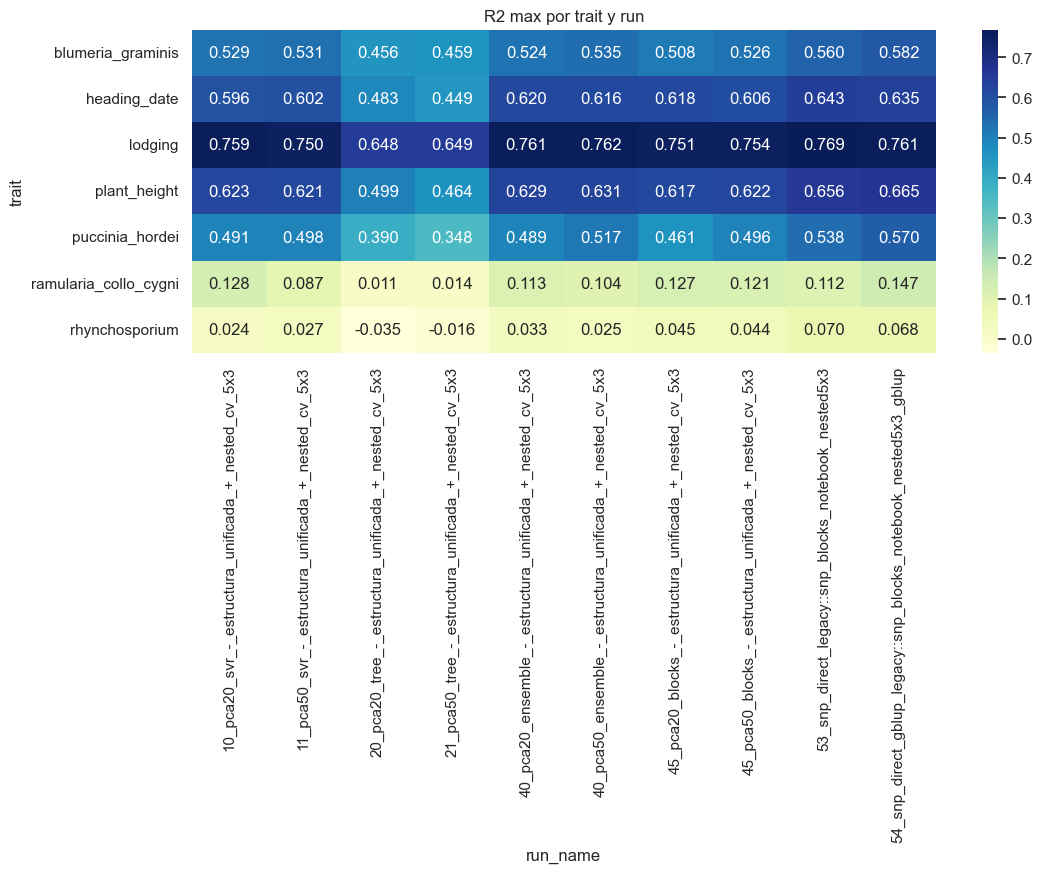

C:\Users\Reyes\AppData\Local\Temp\ipykernel_21292\3722559426.py:26: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


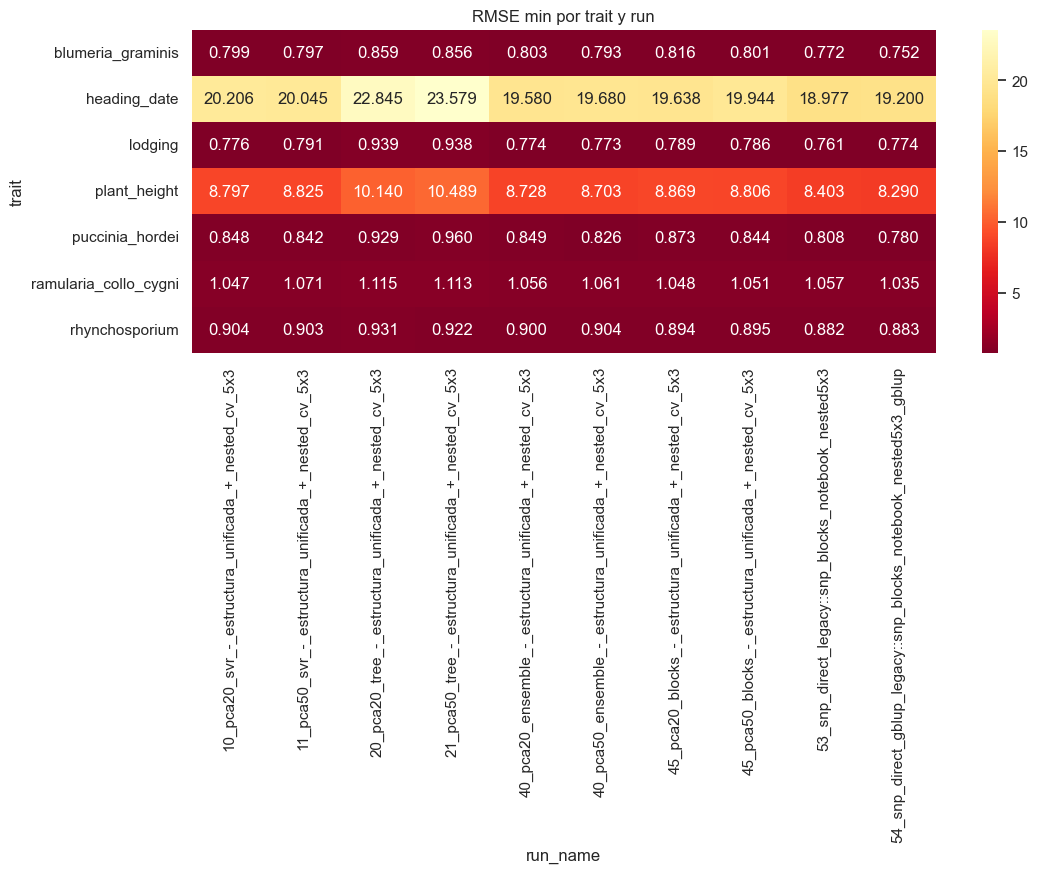

In [64]:
# =========================
# Matrices de comparacion (pivot)
# =========================
if summary_all.empty:
    print('[WARN] Sin datos para pivots.')
else:
    pivot_r2 = summary_all.pivot_table(index='trait', columns='run_name', values='r2', aggfunc='max')
    pivot_rmse = summary_all.pivot_table(index='trait', columns='run_name', values='rmse', aggfunc='min')

    print('Pivot R2 (max por trait/run):')
    display(pivot_r2)
    print('Pivot RMSE (min por trait/run):')
    display(pivot_rmse)

    if pivot_r2.shape[0] > 0 and pivot_r2.shape[1] > 0:
        plt.figure(figsize=(max(8, 1.2 * pivot_r2.shape[1]), max(4, 0.6 * pivot_r2.shape[0])))
        sns.heatmap(pivot_r2, annot=True, fmt='.3f', cmap='YlGnBu')
        plt.title('R2 max por trait y run')
        plt.tight_layout()
        plt.show()

    if pivot_rmse.shape[0] > 0 and pivot_rmse.shape[1] > 0:
        plt.figure(figsize=(max(8, 1.2 * pivot_rmse.shape[1]), max(4, 0.6 * pivot_rmse.shape[0])))
        sns.heatmap(pivot_rmse, annot=True, fmt='.3f', cmap='YlOrRd_r')
        plt.title('RMSE min por trait y run')
        plt.tight_layout()
        plt.show()


In [65]:
# =========================
# Fold-level: dispersion y ranking
# =========================
if folds_all.empty:
    print('[WARN] Sin fold_metrics para analizar dispersion.')
else:
    fold_summary = (
        folds_all
        .groupby(['run_name', 'trait', 'model'], as_index=False)
        .agg(
            r2_mean=('r2', 'mean'),
            r2_std=('r2', 'std'),
            rmse_mean=('rmse', 'mean'),
            rmse_std=('rmse', 'std'),
            n_folds=('fold', 'nunique') if 'fold' in folds_all.columns else ('r2', 'size')
        )
        .sort_values(['trait', 'r2_mean', 'rmse_mean'], ascending=[True, False, True])
        .reset_index(drop=True)
    )

    display(fold_summary.head(40))


,run_name,trait,model,r2_mean,r2_std,rmse_mean,rmse_std,n_folds
0,40_pca50_ensemble_-_estructura_unificada_+_nes...,blumeria_graminis,random_forest,0.534632,0.019134,0.792731,0.034098,5
1,11_pca50_svr_-_estructura_unificada_+_nested_c...,blumeria_graminis,svr_rbf,0.530413,0.030342,0.796214,0.041737,5
2,10_pca20_svr_-_estructura_unificada_+_nested_c...,blumeria_graminis,svr_rbf,0.528300,0.005375,0.798146,0.027792,5
3,45_pca50_blocks_-_estructura_unificada_+_neste...,blumeria_graminis,elasticnet,0.525110,0.021298,0.800781,0.035258,5
4,40_pca20_ensemble_-_estructura_unificada_+_nes...,blumeria_graminis,random_forest,0.522934,0.011157,0.802575,0.026687,5
5,40_pca50_ensemble_-_estructura_unificada_+_nes...,blumeria_graminis,gradient_boosting,0.521444,0.025629,0.803901,0.040036,5
6,45_pca50_blocks_-_estructura_unificada_+_neste...,blumeria_graminis,ridge,0.519790,0.022461,0.805307,0.037743,5
7,40_pca20_ensemble_-_estructura_unificada_+_nes...,blumeria_graminis,gradient_boosting,0.519097,0.025619,0.805746,0.036611,5
8,40_pca50_ensemble_-_estructura_unificada_+_nes...,blumeria_graminis,adaboost,0.508642,0.035338,0.814208,0.040651,5
9,45_pca20_blocks_-_estructura_unificada_+_neste...,blumeria_graminis,xgboost,0.507559,0.025666,0.815369,0.036748,5


In [66]:
# =========================
# Comparacion estadistica opcional (Wilcoxon pareado sobre RMSE por fold)
# =========================
if folds_all.empty or not SCIPY_AVAILABLE:
    print('[INFO] No se puede calcular Wilcoxon (faltan folds o scipy).')
    wilcoxon_df = pd.DataFrame()
else:
    required_cols = {'run_name', 'trait', 'model', 'rmse'}
    if not required_cols.issubset(set(folds_all.columns)):
        print('[INFO] Columnas insuficientes para Wilcoxon:', required_cols - set(folds_all.columns))
        wilcoxon_df = pd.DataFrame()
    else:
        if 'fold' not in folds_all.columns:
            folds_all = folds_all.copy()
            folds_all['fold'] = folds_all.groupby(['run_name', 'trait', 'model']).cumcount() + 1

        rows = []
        for (trait, model), grp in folds_all.groupby(['trait', 'model']):
            run_names = sorted(grp['run_name'].dropna().unique())
            for a, b in itertools.combinations(run_names, 2):
                ga = grp.loc[grp['run_name'] == a, ['fold', 'rmse']].rename(columns={'rmse': 'rmse_a'})
                gb = grp.loc[grp['run_name'] == b, ['fold', 'rmse']].rename(columns={'rmse': 'rmse_b'})
                m = ga.merge(gb, on='fold', how='inner', validate='1:1')
                m = m.dropna(subset=['rmse_a', 'rmse_b'])

                if len(m) < 3:
                    continue

                try:
                    res = wilcoxon(m['rmse_a'].to_numpy(), m['rmse_b'].to_numpy(), alternative='two-sided', method='auto')
                    rows.append({
                        'trait': trait,
                        'model': model,
                        'run_a': a,
                        'run_b': b,
                        'n_paired_folds': int(len(m)),
                        'rmse_mean_a': float(m['rmse_a'].mean()),
                        'rmse_mean_b': float(m['rmse_b'].mean()),
                        'statistic': float(res.statistic),
                        'p_value': float(res.pvalue),
                    })
                except Exception as exc:
                    rows.append({
                        'trait': trait,
                        'model': model,
                        'run_a': a,
                        'run_b': b,
                        'n_paired_folds': int(len(m)),
                        'rmse_mean_a': float(m['rmse_a'].mean()),
                        'rmse_mean_b': float(m['rmse_b'].mean()),
                        'statistic': np.nan,
                        'p_value': np.nan,
                        'error': str(exc),
                    })

        if rows:
            wilcoxon_df = pd.DataFrame(rows).sort_values(['trait', 'model', 'p_value'], na_position='last').reset_index(drop=True)
            display(wilcoxon_df.head(50))
        else:
            wilcoxon_df = pd.DataFrame(columns=['trait', 'model', 'run_a', 'run_b', 'n_paired_folds', 'rmse_mean_a', 'rmse_mean_b', 'statistic', 'p_value'])
            print('[INFO] No hubo pares comparables para Wilcoxon.')


,trait,model,run_a,run_b,n_paired_folds,rmse_mean_a,rmse_mean_b,statistic,p_value
0,blumeria_graminis,adaboost,40_pca20_ensemble_-_estructura_unificada_+_nes...,40_pca50_ensemble_-_estructura_unificada_+_nes...,5,0.817812,0.814208,4.0,0.4375
1,blumeria_graminis,decision_tree,20_pca20_tree_-_estructura_unificada_+_nested_...,21_pca50_tree_-_estructura_unificada_+_nested_...,5,0.857359,0.855916,7.0,1.0000
2,blumeria_graminis,elasticnet,45_pca20_blocks_-_estructura_unificada_+_neste...,45_pca50_blocks_-_estructura_unificada_+_neste...,5,0.922423,0.800781,0.0,0.0625
3,blumeria_graminis,gradient_boosting,40_pca20_ensemble_-_estructura_unificada_+_nes...,40_pca50_ensemble_-_estructura_unificada_+_nes...,5,0.805746,0.803901,5.0,0.6250
4,blumeria_graminis,random_forest,40_pca20_ensemble_-_estructura_unificada_+_nes...,40_pca50_ensemble_-_estructura_unificada_+_nes...,5,0.802575,0.792731,2.0,0.1875
5,blumeria_graminis,ridge,45_pca20_blocks_-_estructura_unificada_+_neste...,45_pca50_blocks_-_estructura_unificada_+_neste...,5,0.993105,0.805307,0.0,0.0625
6,blumeria_graminis,svr_linear,10_pca20_svr_-_estructura_unificada_+_nested_c...,11_pca50_svr_-_estructura_unificada_+_nested_c...,5,0.916958,0.896079,7.0,1.0000
7,blumeria_graminis,svr_rbf,10_pca20_svr_-_estructura_unificada_+_nested_c...,11_pca50_svr_-_estructura_unificada_+_nested_c...,5,0.798146,0.796214,5.0,0.6250
8,blumeria_graminis,xgboost,45_pca20_blocks_-_estructura_unificada_+_neste...,45_pca50_blocks_-_estructura_unificada_+_neste...,5,0.815369,0.817534,6.0,0.8125
9,heading_date,adaboost,40_pca20_ensemble_-_estructura_unificada_+_nes...,40_pca50_ensemble_-_estructura_unificada_+_nes...,5,21.656786,21.253773,2.0,0.1875


## Analisis avanzado para decidir mejor modelo

Este bloque te da criterios accionables para comparar modelos con foco en `pearson_r`, `r2` y `rmse`:

- Ranking por trait y score compuesto: combina las 3 metricas en una unica puntuacion normalizada.
- Ganadores y conteo de victorias: muestra quien gana mas veces por trait/metrica.
- Frontera de Pareto: identifica modelos no dominados (mejor compromiso entre metricas).
- Gaps contra el mejor: cuantifica cuanto pierde cada alternativa frente al top del trait.
- Filtro por umbrales: shortlist de candidatos que cumplen minima calidad.
- Estabilidad en folds: media, desviacion y CV para priorizar modelos robustos.


In [67]:
# =========================
# Analisis avanzado (ranking, Pareto, gaps, umbrales, estabilidad)
# =========================
WEIGHT_R2 = 0.40
WEIGHT_PEARSON = 0.40
WEIGHT_RMSE = 0.20

R2_MIN = 0.50
PEARSON_MIN = 0.70
RMSE_QUANTILE = 0.25


def minmax_norm(series: pd.Series, higher_is_better: bool = True) -> pd.Series:
    s = pd.to_numeric(series, errors='coerce')
    s_min = s.min()
    s_max = s.max()
    if pd.isna(s_min) or pd.isna(s_max):
        return pd.Series(np.nan, index=s.index)
    if s_max == s_min:
        # si no hay variacion, no discrimina: asignamos 1.0
        return pd.Series(1.0, index=s.index)
    if higher_is_better:
        return (s - s_min) / (s_max - s_min)
    return (s_max - s) / (s_max - s_min)


if summary_all.empty:
    print('[WARN] Sin summary_all para analisis avanzado.')
    ranking_trait_df = pd.DataFrame()
    metric_winners_df = pd.DataFrame()
    victories_df = pd.DataFrame()
    topk_counts_df = pd.DataFrame()
    pareto_df = pd.DataFrame()
    gaps_df = pd.DataFrame()
    threshold_candidates_df = pd.DataFrame()
    stability_df = pd.DataFrame()
else:
    work = summary_all.copy()

    # Normalizacion por trait para combinar metricas en una sola puntuacion
    work['r2_norm'] = work.groupby('trait', group_keys=False)['r2'].apply(lambda x: minmax_norm(x, higher_is_better=True))
    work['pearson_norm'] = work.groupby('trait', group_keys=False)['pearson_r'].apply(lambda x: minmax_norm(x, higher_is_better=True))
    work['rmse_norm_inv'] = work.groupby('trait', group_keys=False)['rmse'].apply(lambda x: minmax_norm(x, higher_is_better=False))

    work['score_composite'] = (
        WEIGHT_R2 * work['r2_norm'] +
        WEIGHT_PEARSON * work['pearson_norm'] +
        WEIGHT_RMSE * work['rmse_norm_inv']
    )

    # Ranking por trait usando score compuesto
    ranking_trait_df = (
        work
        .sort_values(['trait', 'score_composite', 'r2', 'pearson_r', 'rmse'], ascending=[True, False, False, False, True])
        .copy()
    )
    ranking_trait_df['rank_trait'] = ranking_trait_df.groupby('trait')['score_composite'].rank(method='dense', ascending=False)

    # Ganador por metrica y por score compuesto
    winner_rows = []
    for trait, g in work.groupby('trait'):
        g_valid = g.dropna(subset=['r2', 'pearson_r', 'rmse'])
        if g_valid.empty:
            continue

        idx_r2 = g_valid['r2'].idxmax()
        idx_pr = g_valid['pearson_r'].idxmax()
        idx_rm = g_valid['rmse'].idxmin()
        idx_sc = g_valid['score_composite'].idxmax()

        for metric, idx in [('r2', idx_r2), ('pearson_r', idx_pr), ('rmse', idx_rm), ('score_composite', idx_sc)]:
            row = g_valid.loc[idx, ['trait', 'run_name', 'model', 'representation', 'r2', 'pearson_r', 'rmse', 'score_composite']].to_dict()
            row['winner_metric'] = metric
            winner_rows.append(row)

    metric_winners_df = pd.DataFrame(winner_rows).sort_values(['trait', 'winner_metric']).reset_index(drop=True)

    # Conteo de victorias
    if not metric_winners_df.empty:
        victories_df = (
            metric_winners_df
            .groupby(['run_name', 'model', 'winner_metric'], as_index=False)
            .size()
            .rename(columns={'size': 'wins'})
            .sort_values(['winner_metric', 'wins'], ascending=[True, False])
            .reset_index(drop=True)
        )
    else:
        victories_df = pd.DataFrame()

    # Top-K por trait en score compuesto
    topk_counts_df = (
        ranking_trait_df.assign(
            top1=lambda d: (d['rank_trait'] == 1).astype(int),
            top3=lambda d: (d['rank_trait'] <= 3).astype(int),
        )
        .groupby(['run_name', 'model'], as_index=False)[['top1', 'top3']]
        .sum()
        .sort_values(['top1', 'top3'], ascending=[False, False])
        .reset_index(drop=True)
    )

    # Frontera de Pareto por trait (max r2, max pearson, min rmse)
    def is_dominated(i: int, arr: np.ndarray) -> bool:
        # arr columns: r2, pearson, rmse
        x = arr[i]
        for j, y in enumerate(arr):
            if j == i:
                continue
            better_or_equal = (y[0] >= x[0]) and (y[1] >= x[1]) and (y[2] <= x[2])
            strictly_better = (y[0] > x[0]) or (y[1] > x[1]) or (y[2] < x[2])
            if better_or_equal and strictly_better:
                return True
        return False

    pareto_parts = []
    for trait, g in work.groupby('trait'):
        gg = g.dropna(subset=['r2', 'pearson_r', 'rmse']).copy()
        if gg.empty:
            continue
        arr = gg[['r2', 'pearson_r', 'rmse']].to_numpy(dtype=float)
        flags = [not is_dominated(i, arr) for i in range(len(gg))]
        gg['is_pareto'] = flags
        pareto_parts.append(gg)

    pareto_df = pd.concat(pareto_parts, ignore_index=True) if pareto_parts else pd.DataFrame()

    # Gaps contra el mejor por trait
    best_trait = (
        work
        .groupby('trait', as_index=False)
        .agg(best_r2=('r2', 'max'), best_pearson=('pearson_r', 'max'), best_rmse=('rmse', 'min'), best_score=('score_composite', 'max'))
    )

    gaps_df = work.merge(best_trait, on='trait', how='left', validate='m:1')
    gaps_df['delta_r2_to_best'] = gaps_df['best_r2'] - gaps_df['r2']
    gaps_df['delta_pearson_to_best'] = gaps_df['best_pearson'] - gaps_df['pearson_r']
    gaps_df['delta_rmse_to_best'] = gaps_df['rmse'] - gaps_df['best_rmse']
    gaps_df['delta_score_to_best'] = gaps_df['best_score'] - gaps_df['score_composite']
    gaps_df = gaps_df.sort_values(['trait', 'delta_score_to_best', 'delta_rmse_to_best']).reset_index(drop=True)

    # Filtro por umbrales (shortlist util)
    rmse_cut = work.groupby('trait')['rmse'].quantile(RMSE_QUANTILE).rename('rmse_cutoff').reset_index()
    threshold_candidates_df = work.merge(rmse_cut, on='trait', how='left', validate='m:1')
    threshold_candidates_df = threshold_candidates_df[
        (threshold_candidates_df['r2'] >= R2_MIN) &
        (threshold_candidates_df['pearson_r'] >= PEARSON_MIN) &
        (threshold_candidates_df['rmse'] <= threshold_candidates_df['rmse_cutoff'])
    ].sort_values(['trait', 'score_composite', 'r2', 'pearson_r', 'rmse'], ascending=[True, False, False, False, True]).reset_index(drop=True)

    # Estabilidad fold-level (solo runs con folds disponibles)
    if folds_all.empty:
        stability_df = pd.DataFrame()
    else:
        stability_df = (
            folds_all
            .groupby(['run_name', 'trait', 'model'], as_index=False)
            .agg(
                r2_mean=('r2', 'mean'), r2_std=('r2', 'std'),
                pearson_mean=('pearson_r', 'mean'), pearson_std=('pearson_r', 'std'),
                rmse_mean=('rmse', 'mean'), rmse_std=('rmse', 'std'),
                n_folds=('fold', 'nunique') if 'fold' in folds_all.columns else ('r2', 'size')
            )
        )
        for m in ['r2', 'pearson', 'rmse']:
            mean_col = f'{m}_mean'
            std_col = f'{m}_std'
            cv_col = f'{m}_cv'
            stability_df[cv_col] = np.where(
                pd.to_numeric(stability_df[mean_col], errors='coerce').abs() > 1e-12,
                pd.to_numeric(stability_df[std_col], errors='coerce') / pd.to_numeric(stability_df[mean_col], errors='coerce').abs(),
                np.nan,
            )
        stability_df = stability_df.sort_values(['trait', 'r2_mean', 'pearson_mean', 'rmse_mean'], ascending=[True, False, False, True]).reset_index(drop=True)

    print()
    print('[RESUMEN ANALISIS AVANZADO]')
    print('Filas ranking_trait_df:', len(ranking_trait_df))
    print('Filas metric_winners_df:', len(metric_winners_df))
    print('Filas pareto_df:', len(pareto_df), '| Pareto total:', int(pareto_df['is_pareto'].sum()) if not pareto_df.empty else 0)
    print('Filas threshold_candidates_df:', len(threshold_candidates_df))

    print()
    print('Top-1/Top-3 por run-model (score compuesto):')
    display(topk_counts_df.head(20))

    print()
    print('Ganador por trait y metrica:')
    display(metric_winners_df.head(40))

    print()
    print('Candidatos por umbrales:')
    display(threshold_candidates_df.head(40))



[RESUMEN ANALISIS AVANZADO]
Filas ranking_trait_df: 154
Filas metric_winners_df: 28
Filas pareto_df: 154 | Pareto total: 7
Filas threshold_candidates_df: 29

Top-1/Top-3 por run-model (score compuesto):


,run_name,model,top1,top3
0,54_snp_direct_gblup_legacy::snp_blocks_noteboo...,gblup,4,6
1,53_snp_direct_legacy::snp_blocks_notebook_nest...,xgboost,2,5
2,53_snp_direct_legacy::snp_blocks_notebook_nest...,ridge,1,5
3,53_snp_direct_legacy::snp_blocks_notebook_nest...,elasticnet,0,2
4,10_pca20_svr_-_estructura_unificada_+_nested_c...,svr_rbf,0,1
5,40_pca50_ensemble_-_estructura_unificada_+_nes...,random_forest,0,1
6,45_pca20_blocks_-_estructura_unificada_+_neste...,elasticnet,0,1
7,10_pca20_svr_-_estructura_unificada_+_nested_c...,svr_linear,0,0
8,11_pca50_svr_-_estructura_unificada_+_nested_c...,svr_linear,0,0
9,11_pca50_svr_-_estructura_unificada_+_nested_c...,svr_rbf,0,0



Ganador por trait y metrica:


,trait,run_name,model,representation,r2,pearson_r,rmse,score_composite,winner_metric
0,blumeria_graminis,54_snp_direct_gblup_legacy::snp_blocks_noteboo...,gblup,snp_direct,0.582337,0.763178,0.752221,1.0,pearson_r
1,blumeria_graminis,54_snp_direct_gblup_legacy::snp_blocks_noteboo...,gblup,snp_direct,0.582337,0.763178,0.752221,1.0,r2
2,blumeria_graminis,54_snp_direct_gblup_legacy::snp_blocks_noteboo...,gblup,snp_direct,0.582337,0.763178,0.752221,1.0,rmse
3,blumeria_graminis,54_snp_direct_gblup_legacy::snp_blocks_noteboo...,gblup,snp_direct,0.582337,0.763178,0.752221,1.0,score_composite
4,heading_date,53_snp_direct_legacy::snp_blocks_notebook_nest...,xgboost,snp_direct,0.643340,0.802406,18.977351,1.0,pearson_r
5,heading_date,53_snp_direct_legacy::snp_blocks_notebook_nest...,xgboost,snp_direct,0.643340,0.802406,18.977351,1.0,r2
6,heading_date,53_snp_direct_legacy::snp_blocks_notebook_nest...,xgboost,snp_direct,0.643340,0.802406,18.977351,1.0,rmse
7,heading_date,53_snp_direct_legacy::snp_blocks_notebook_nest...,xgboost,snp_direct,0.643340,0.802406,18.977351,1.0,score_composite
8,lodging,53_snp_direct_legacy::snp_blocks_notebook_nest...,ridge,snp_direct,0.768605,0.877308,0.761419,1.0,pearson_r
9,lodging,53_snp_direct_legacy::snp_blocks_notebook_nest...,ridge,snp_direct,0.768605,0.877308,0.761419,1.0,r2



Candidatos por umbrales:


,representation,trait,model,n_individuos,n_features,cv_outer,cv_inner,pearson_r,pearson_p,rmse,mae,r2,fit_time_s,best_params_mode_outer,run_name,run_path,n_configs_model,fits_por_config,fits_ejecutados_config,cv,r2_norm,pearson_norm,rmse_norm_inv,score_composite,rmse_cutoff
0,snp_direct,blumeria_graminis,gblup,1110,61139,"KFold(5, shuffle=True, random_state=42)","KFold(3, shuffle=True, random_state=42)",0.763178,2.366859e-212,0.752221,0.586938,0.582337,75.793400,"fit_intercept=True, grm=vanraden, jitter=1e-08...",54_snp_direct_gblup_legacy::snp_blocks_noteboo...,results\snp_blocks_notebook_nested5x3_gblup,1.0,15.0,20.0,"NestedKFold_manual(outer=5, inner=3, random_st...",1.000000,1.000000,1.000000,1.000000,0.797450
1,snp_direct,blumeria_graminis,xgboost,1110,61139,"KFold(5, shuffle=True, random_state=42)","KFold(3, shuffle=True, random_state=42)",0.748690,4.828184e-200,0.771705,NaN,0.560421,1717.856760,"colsample_bytree=0.1, learning_rate=0.05, max_...",53_snp_direct_legacy::snp_blocks_notebook_nest...,results\snp_blocks_notebook_nested5x3,1.0,15.0,20.0,"NestedKFold_manual(outer=5, inner=3, random_st...",0.946324,0.929913,0.936246,0.937744,0.797450
2,snp_direct,blumeria_graminis,ridge,1110,61139,"KFold(5, shuffle=True, random_state=42)","KFold(3, shuffle=True, random_state=42)",0.748370,8.841230e-200,0.772391,NaN,0.559639,418.507412,alpha=1.0,53_snp_direct_legacy::snp_blocks_notebook_nest...,results\snp_blocks_notebook_nested5x3,1.0,15.0,20.0,"NestedKFold_manual(outer=5, inner=3, random_st...",0.944409,0.928362,0.934001,0.935909,0.797450
3,snp_direct,blumeria_graminis,elasticnet,1110,61139,"KFold(5, shuffle=True, random_state=42)","KFold(3, shuffle=True, random_state=42)",0.735424,1.722671e-189,0.789258,NaN,0.540195,133.836221,"alpha=0.1, l1_ratio=0.1",53_snp_direct_legacy::snp_blocks_notebook_nest...,results\snp_blocks_notebook_nested5x3,1.0,15.0,20.0,"NestedKFold_manual(outer=5, inner=3, random_st...",0.896790,0.865737,0.878808,0.880772,0.797450
4,pca50,blumeria_graminis,random_forest,1110,50,"KFold(5, shuffle=True, random_state=42)","KFold(3, shuffle=True, random_state=42)",0.731778,1.061200e-186,0.793317,0.613436,0.535454,1117.775828,"{""model__max_depth"": 15, ""model__max_features""...",40_pca50_ensemble_-_estructura_unificada_+_nes...,outputs_nested5x3\40_pca50_ensemble_-_estructu...,NaN,NaN,NaN,NaN,0.885179,0.848096,0.865528,0.866416,0.797450
5,pca50,blumeria_graminis,svr_rbf,1110,50,"KFold(5, shuffle=True, random_state=42)","KFold(3, shuffle=True, random_state=42)",0.729331,7.439351e-185,0.797089,0.623334,0.531026,13.973322,"{""model__C"": 1, ""model__epsilon"": 0.5, ""model_...",11_pca50_svr_-_estructura_unificada_+_nested_c...,outputs_nested5x3\11_pca50_svr_-_estructura_un...,NaN,NaN,NaN,NaN,0.874335,0.836262,0.853186,0.854876,0.797450
6,snp_direct,heading_date,xgboost,1110,61139,"KFold(5, shuffle=True, random_state=42)","KFold(3, shuffle=True, random_state=42)",0.802406,1.190222e-250,18.977351,NaN,0.643340,1705.786745,"colsample_bytree=0.1, learning_rate=0.05, max_...",53_snp_direct_legacy::snp_blocks_notebook_nest...,results\snp_blocks_notebook_nested5x3,1.0,15.0,20.0,"NestedKFold_manual(outer=5, inner=3, random_st...",1.000000,1.000000,1.000000,1.000000,19.648576
7,snp_direct,heading_date,elasticnet,1110,61139,"KFold(5, shuffle=True, random_state=42)","KFold(3, shuffle=True, random_state=42)",0.800564,1.156808e-248,19.049703,NaN,0.640615,184.616214,"alpha=0.1, l1_ratio=0.1",53_snp_direct_legacy::snp_blocks_notebook_nest...,results\snp_blocks_notebook_nested5x3,1.0,15.0,20.0,"NestedKFold_manual(outer=5, inner=3, random_st...",0.985950,0.985195,0.984276,0.985313,19.648576
8,snp_direct,heading_date,gblup,1110,61139,"KFold(5, shuffle=True, random_state=42)","KFold(3, shuffle=True, random_state=42)",0.797251,3.857791e-245,19.199901,12.987290,0.634926,70.764905,"fit_intercept=True, grm=vanraden, jitter=1e-08...",54_snp_direct_gblup_legacy::snp_blocks_noteboo...,results\snp_blocks_notebook_nested5x3_gblup,1.0,15.0,20.0,"

## Vista Pearson (trait por trait)

Bloque centrado en `pearson_r` para comparar de forma directa todos los modelos (incluidos ensemble y blocks, que tienen varios modelos por run).

Tablas clave:
- `pearson_trait_leaderboard_df`: ranking completo por trait y modelo (ordenado por Pearson).
- `pearson_trait_compact_df`: tabla compacta por trait con el mejor modelo de cada run.
- `pearson_top3_per_trait_df`: top-3 global por trait segun Pearson.
- `pearson_matrix_trait_model_df`: matriz detallada trait x (run|model).


In [68]:
# =========================
# Pearson-first: tablas claras por trait
# =========================
if summary_all.empty:
    print('[WARN] Sin summary_all para bloque Pearson.')
    pearson_trait_leaderboard_df = pd.DataFrame()
    pearson_top3_per_trait_df = pd.DataFrame()
    pearson_best_run_trait_df = pd.DataFrame()
    pearson_trait_compact_df = pd.DataFrame()
    pearson_matrix_trait_model_df = pd.DataFrame()
    pearson_matrix_trait_run_df = pd.DataFrame()
    model_counts_run_trait_df = pd.DataFrame()
else:
    pearson_base = summary_all.copy()
    pearson_base['pearson_r'] = pd.to_numeric(pearson_base['pearson_r'], errors='coerce')
    pearson_base['r2'] = pd.to_numeric(pearson_base['r2'], errors='coerce')
    pearson_base['rmse'] = pd.to_numeric(pearson_base['rmse'], errors='coerce')

    # id legible run+model para matrices
    pearson_base['run_model'] = pearson_base['run_name'].astype(str) + ' | ' + pearson_base['model'].astype(str)

    # ranking por trait priorizando Pearson; desempates con R2 y RMSE
    pearson_trait_leaderboard_df = (
        pearson_base
        .sort_values(['trait', 'pearson_r', 'r2', 'rmse'], ascending=[True, False, False, True])
        .copy()
    )
    pearson_trait_leaderboard_df['rank_pearson_trait'] = (
        pearson_trait_leaderboard_df.groupby('trait')['pearson_r'].rank(method='dense', ascending=False)
    )
    best_pearson_trait = pearson_trait_leaderboard_df.groupby('trait')['pearson_r'].transform('max')
    pearson_trait_leaderboard_df['delta_pearson_to_best'] = best_pearson_trait - pearson_trait_leaderboard_df['pearson_r']

    # top-3 por trait
    pearson_top3_per_trait_df = (
        pearson_trait_leaderboard_df[pearson_trait_leaderboard_df['rank_pearson_trait'] <= 3]
        .sort_values(['trait', 'rank_pearson_trait', 'r2', 'rmse'], ascending=[True, True, False, True])
        .reset_index(drop=True)
    )

    # mejor modelo de cada run dentro de cada trait (importante para ensemble/blocks)
    pearson_best_run_trait_df = (
        pearson_trait_leaderboard_df
        .groupby(['trait', 'run_name'], as_index=False)
        .first()
        .sort_values(['trait', 'pearson_r', 'r2', 'rmse'], ascending=[True, False, False, True])
        .reset_index(drop=True)
    )

    # tabla compacta por trait con texto "pearson | modelo"
    compact = pearson_best_run_trait_df.copy()
    compact['pearson_model'] = compact.apply(lambda r: f"{r['pearson_r']:.4f} | {r['model']}", axis=1)
    pearson_trait_compact_df = (
        compact.pivot(index='trait', columns='run_name', values='pearson_model')
        .sort_index()
    )

    # matriz detallada con todos los modelos
    pearson_matrix_trait_model_df = (
        pearson_base.pivot_table(index='trait', columns='run_model', values='pearson_r', aggfunc='max')
        .sort_index(axis=1)
    )

    # matriz simplificada por run (mejor Pearson por run/trait)
    pearson_matrix_trait_run_df = (
        pearson_base.pivot_table(index='trait', columns='run_name', values='pearson_r', aggfunc='max')
        .sort_index(axis=1)
    )

    # cuantos modelos por trait/run (para visibilizar ensemble/blocks multi-modelo)
    model_counts_run_trait_df = (
        pearson_base
        .groupby(['trait', 'run_name'], as_index=False)['model']
        .nunique()
        .rename(columns={'model': 'n_models_in_run_trait'})
        .sort_values(['trait', 'n_models_in_run_trait', 'run_name'], ascending=[True, False, True])
        .reset_index(drop=True)
    )

    print('[PEARSON] Ranking completo por trait/model:')
    display(pearson_trait_leaderboard_df[['trait','run_name','model','representation','pearson_r','r2','rmse','rank_pearson_trait','delta_pearson_to_best']].head(60))

    print('[PEARSON] Top-3 por trait:')
    display(pearson_top3_per_trait_df[['trait','rank_pearson_trait','run_name','model','pearson_r','r2','rmse']].head(60))

    print('[PEARSON] Mejor por run dentro de cada trait:')
    display(pearson_best_run_trait_df[['trait','run_name','model','pearson_r','r2','rmse']].head(80))

    print('[PEARSON] Tabla compacta trait x run (valor|modelo):')
    display(pearson_trait_compact_df)

    print('[PEARSON] Numero de modelos por trait/run (ensembles y blocks deben tener >1):')
    display(model_counts_run_trait_df.head(80))


[PEARSON] Ranking completo por trait/model:


,trait,run_name,model,representation,pearson_r,r2,rmse,rank_pearson_trait,delta_pearson_to_best
147,blumeria_graminis,54_snp_direct_gblup_legacy::snp_blocks_noteboo...,gblup,snp_direct,0.763178,0.582337,0.752221,1.0,0.000000
126,blumeria_graminis,53_snp_direct_legacy::snp_blocks_notebook_nest...,xgboost,snp_direct,0.748690,0.560421,0.771705,2.0,0.014488
127,blumeria_graminis,53_snp_direct_legacy::snp_blocks_notebook_nest...,ridge,snp_direct,0.748370,0.559639,0.772391,3.0,0.014809
128,blumeria_graminis,53_snp_direct_legacy::snp_blocks_notebook_nest...,elasticnet,snp_direct,0.735424,0.540195,0.789258,4.0,0.027754
63,blumeria_graminis,40_pca50_ensemble_-_estructura_unificada_+_nes...,random_forest,pca50,0.731778,0.535454,0.793317,5.0,0.031401
21,blumeria_graminis,11_pca50_svr_-_estructura_unificada_+_nested_c...,svr_rbf,pca50,0.729331,0.531026,0.797089,6.0,0.033847
7,blumeria_graminis,10_pca20_svr_-_estructura_unificada_+_nested_c...,svr_rbf,pca20,0.728660,0.529325,0.798533,7.0,0.034518
112,blumeria_graminis,45_pca50_blocks_-_estructura_unificada_+_neste...,elasticnet,pca50,0.727560,0.525938,0.801401,8.0,0.035618
42,blumeria_graminis,40_pca20_ensemble_-_estructura_unificada_+_nes...,random_forest,pca20,0.724054,0.524128,0.802930,9.0,0.039124
70,blumeria_graminis,40_pca50_ensemble_-_estructura_unificada_+_nes...,gradient_boosting,pca50,0.722518,0.522030,0.804698,10.0,0.040661


[PEARSON] Top-3 por trait:


,trait,rank_pearson_trait,run_name,model,pearson_r,r2,rmse
0,blumeria_graminis,1.0,54_snp_direct_gblup_legacy::snp_blocks_noteboo...,gblup,0.763178,0.582337,0.752221
1,blumeria_graminis,2.0,53_snp_direct_legacy::snp_blocks_notebook_nest...,xgboost,0.748690,0.560421,0.771705
2,blumeria_graminis,3.0,53_snp_direct_legacy::snp_blocks_notebook_nest...,ridge,0.748370,0.559639,0.772391
3,heading_date,1.0,53_snp_direct_legacy::snp_blocks_notebook_nest...,xgboost,0.802406,0.643340,18.977351
4,heading_date,2.0,53_snp_direct_legacy::snp_blocks_notebook_nest...,elasticnet,0.800564,0.640615,19.049703
5,heading_date,3.0,54_snp_direct_gblup_legacy::snp_blocks_noteboo...,gblup,0.797251,0.634926,19.199901
6,lodging,1.0,53_snp_direct_legacy::snp_blocks_notebook_nest...,ridge,0.877308,0.768605,0.761419
7,lodging,2.0,53_snp_direct_legacy::snp_blocks_notebook_nest...,xgboost,0.874352,0.763854,0.769197
8,lodging,3.0,40_pca50_ensemble_-_estructura_unificada_+_nes...,random_forest,0.873200,0.761525,0.772980
9,plant_height,1.0,54_snp_direct_gblup_legacy::snp_blocks_noteboo...,gblup,0.815771,0.665413,8.289570


[PEARSON] Mejor por run dentro de cada trait:


,trait,run_name,model,pearson_r,r2,rmse
0,blumeria_graminis,54_snp_direct_gblup_legacy::snp_blocks_noteboo...,gblup,0.763178,0.582337,0.752221
1,blumeria_graminis,53_snp_direct_legacy::snp_blocks_notebook_nest...,xgboost,0.748690,0.560421,0.771705
2,blumeria_graminis,40_pca50_ensemble_-_estructura_unificada_+_nes...,random_forest,0.731778,0.535454,0.793317
3,blumeria_graminis,11_pca50_svr_-_estructura_unificada_+_nested_c...,svr_rbf,0.729331,0.531026,0.797089
4,blumeria_graminis,10_pca20_svr_-_estructura_unificada_+_nested_c...,svr_rbf,0.728660,0.529325,0.798533
...,...,...,...,...,...,...
65,rhynchosporium,45_pca50_blocks_-_estructura_unificada_+_neste...,ridge,0.209756,0.043749,0.895028
66,rhynchosporium,11_pca50_svr_-_estructura_unificada_+_nested_c...,svr_linear,0.190090,0.026812,0.902919
67,rhynchosporium,10_pca20_svr_-_estructura_unificada_+_nested_c...,svr_linear,0.170986,0.023550,0.904431
68,rhynchosporium,20_pca20_tree_-_estructura_unificada_+_nested_...,decision_tree,0.087366,-0.035263,0.931270


[PEARSON] Tabla compacta trait x run (valor|modelo):


run_name,10_pca20_svr_-_estructura_unificada_+_nested_cv_5x3,11_pca50_svr_-_estructura_unificada_+_nested_cv_5x3,20_pca20_tree_-_estructura_unificada_+_nested_cv_5x3,21_pca50_tree_-_estructura_unificada_+_nested_cv_5x3,40_pca20_ensemble_-_estructura_unificada_+_nested_cv_5x3,40_pca50_ensemble_-_estructura_unificada_+_nested_cv_5x3,45_pca20_blocks_-_estructura_unificada_+_nested_cv_5x3,45_pca50_blocks_-_estructura_unificada_+_nested_cv_5x3,53_snp_direct_legacy::snp_blocks_notebook_nested5x3,54_snp_direct_gblup_legacy::snp_blocks_notebook_nested5x3_gblup
trait,,,,,,,,,,
blumeria_graminis,0.7287 | svr_rbf,0.7293 | svr_rbf,0.6767 | decision_tree,0.6788 | decision_tree,0.7241 | random_forest,0.7318 | random_forest,0.7143 | xgboost,0.7276 | elasticnet,0.7487 | xgboost,0.7632 | gblup
heading_date,0.7791 | svr_rbf,0.7811 | svr_rbf,0.7027 | decision_tree,0.6780 | decision_tree,0.7883 | random_forest,0.7855 | gradient_boosting,0.7862 | xgboost,0.7786 | xgboost,0.8024 | xgboost,0.7973 | gblup
lodging,0.8716 | svr_rbf,0.8663 | svr_rbf,0.8073 | decision_tree,0.8084 | decision_tree,0.8726 | random_forest,0.8732 | random_forest,0.8669 | xgboost,0.8682 | xgboost,0.8773 | ridge,0.8724 | gblup
plant_height,0.7904 | svr_rbf,0.7892 | svr_rbf,0.7133 | decision_tree,0.6904 | decision_tree,0.7936 | random_forest,0.7958 | random_forest,0.7857 | xgboost,0.7890 | xgboost,0.8107 | elasticnet,0.8158 | gblup
puccinia_hordei,0.7023 | svr_rbf,0.7071 | svr_rbf,0.6290 | decision_tree,0.6052 | decision_tree,0.6995 | random_forest,0.7193 | gradient_boosting,0.6814 | xgboost,0.7047 | xgboost,0.7341 | xgboost,0.7551 | gblup
ramularia_collo_cygni,0.3617 | svr_rbf,0.3073 | svr_rbf,0.2538 | decision_tree,0.2141 | decision_tree,0.3461 | random_forest,0.3298 | random_forest,0.3575 | elasticnet,0.3481 | elasticnet,0.3457 | xgboost,0.3852 | gblup
rhynchosporium,0.1710 | svr_linear,0.1901 | svr_linear,0.0874 | decision_tree,0.0710 | decision_tree,0.2103 | random_forest,0.2180 | random_forest,0.2139 | ridge,0.2098 | ridge,0.2857 | xgboost,0.2739 | gblup


[PEARSON] Numero de modelos por trait/run (ensembles y blocks deben tener >1):


,trait,run_name,n_models_in_run_trait
0,blumeria_graminis,40_pca20_ensemble_-_estructura_unificada_+_nes...,3
1,blumeria_graminis,40_pca50_ensemble_-_estructura_unificada_+_nes...,3
2,blumeria_graminis,45_pca20_blocks_-_estructura_unificada_+_neste...,3
3,blumeria_graminis,45_pca50_blocks_-_estructura_unificada_+_neste...,3
4,blumeria_graminis,53_snp_direct_legacy::snp_blocks_notebook_nest...,3
...,...,...,...
65,rhynchosporium,10_pca20_svr_-_estructura_unificada_+_nested_c...,2
66,rhynchosporium,11_pca50_svr_-_estructura_unificada_+_nested_c...,2
67,rhynchosporium,20_pca20_tree_-_estructura_unificada_+_nested_...,1
68,rhynchosporium,21_pca50_tree_-_estructura_unificada_+_nested_...,1


## Comparativa directa PCA20 vs PCA50

Comparacion pareada por `trait` y `model` para ver si usar 20 o 50 PCs mejora `pearson_r`, `r2` y `rmse`.

Tablas:
- `pca20_vs_pca50_df`: comparativa por `trait-model` (delta 50-20).
- `pca20_vs_pca50_trait_best_df`: mejor modelo por trait dentro de cada representacion y comparativa final 20 vs 50.
- `pca_model_delta_summary_df`: resumen por modelo (deltas medios y numero de victorias de PCA50 frente a PCA20).


In [69]:
# =========================
# PCA20 vs PCA50 (pareado por trait y model)
# =========================
if summary_all.empty:
    print('[WARN] Sin summary_all para comparativa PCA20 vs PCA50.')
    pca20_vs_pca50_df = pd.DataFrame()
    pca20_vs_pca50_trait_best_df = pd.DataFrame()
    pca_model_delta_summary_df = pd.DataFrame()
else:
    pca_only = summary_all[summary_all['representation'].isin(['pca20', 'pca50'])].copy()

    if pca_only.empty:
        print('[WARN] No hay filas PCA20/PCA50 en summary_all.')
        pca20_vs_pca50_df = pd.DataFrame()
        pca20_vs_pca50_trait_best_df = pd.DataFrame()
        pca_model_delta_summary_df = pd.DataFrame()
    else:
        for col in ['pearson_r', 'r2', 'rmse']:
            pca_only[col] = pd.to_numeric(pca_only[col], errors='coerce')

        # 1) por trait-model-representation nos quedamos con el mejor run
        pca_best_rep = (
            pca_only
            .sort_values(['trait', 'model', 'representation', 'pearson_r', 'r2', 'rmse'], ascending=[True, True, True, False, False, True])
            .groupby(['trait', 'model', 'representation'], as_index=False)
            .first()
        )

        idx = ['trait', 'model']
        run_w = pca_best_rep.pivot_table(index=idx, columns='representation', values='run_name', aggfunc='first')
        pr_w = pca_best_rep.pivot_table(index=idx, columns='representation', values='pearson_r', aggfunc='first')
        r2_w = pca_best_rep.pivot_table(index=idx, columns='representation', values='r2', aggfunc='first')
        rm_w = pca_best_rep.pivot_table(index=idx, columns='representation', values='rmse', aggfunc='first')

        pca20_vs_pca50_df = pd.DataFrame({'trait': sorted(pca_best_rep['trait'].unique())})
        pca20_vs_pca50_df = pca_best_rep[['trait', 'model']].drop_duplicates().merge(
            run_w.reset_index().rename(columns={'pca20': 'run_pca20', 'pca50': 'run_pca50'}),
            on=idx,
            how='left'
        )
        pca20_vs_pca50_df = pca20_vs_pca50_df.merge(
            pr_w.reset_index().rename(columns={'pca20': 'pearson_pca20', 'pca50': 'pearson_pca50'}),
            on=idx,
            how='left'
        )
        pca20_vs_pca50_df = pca20_vs_pca50_df.merge(
            r2_w.reset_index().rename(columns={'pca20': 'r2_pca20', 'pca50': 'r2_pca50'}),
            on=idx,
            how='left'
        )
        pca20_vs_pca50_df = pca20_vs_pca50_df.merge(
            rm_w.reset_index().rename(columns={'pca20': 'rmse_pca20', 'pca50': 'rmse_pca50'}),
            on=idx,
            how='left'
        )

        pca20_vs_pca50_df['delta_pearson_50_minus_20'] = pca20_vs_pca50_df['pearson_pca50'] - pca20_vs_pca50_df['pearson_pca20']
        pca20_vs_pca50_df['delta_r2_50_minus_20'] = pca20_vs_pca50_df['r2_pca50'] - pca20_vs_pca50_df['r2_pca20']
        pca20_vs_pca50_df['delta_rmse_50_minus_20'] = pca20_vs_pca50_df['rmse_pca50'] - pca20_vs_pca50_df['rmse_pca20']

        pca20_vs_pca50_df['winner_pearson'] = np.where(
            pca20_vs_pca50_df['delta_pearson_50_minus_20'] > 0, 'pca50',
            np.where(pca20_vs_pca50_df['delta_pearson_50_minus_20'] < 0, 'pca20', 'tie')
        )
        pca20_vs_pca50_df['winner_r2'] = np.where(
            pca20_vs_pca50_df['delta_r2_50_minus_20'] > 0, 'pca50',
            np.where(pca20_vs_pca50_df['delta_r2_50_minus_20'] < 0, 'pca20', 'tie')
        )
        pca20_vs_pca50_df['winner_rmse'] = np.where(
            pca20_vs_pca50_df['delta_rmse_50_minus_20'] < 0, 'pca50',
            np.where(pca20_vs_pca50_df['delta_rmse_50_minus_20'] > 0, 'pca20', 'tie')
        )

        pca20_vs_pca50_df = pca20_vs_pca50_df.sort_values(['trait', 'delta_pearson_50_minus_20', 'delta_r2_50_minus_20'], ascending=[True, False, False]).reset_index(drop=True)

        # 2) mejor modelo por trait dentro de cada representacion
        pca_best_trait_rep = (
            pca_only
            .sort_values(['trait', 'representation', 'pearson_r', 'r2', 'rmse'], ascending=[True, True, False, False, True])
            .groupby(['trait', 'representation'], as_index=False)
            .first()
        )

        t_pr = pca_best_trait_rep.pivot_table(index='trait', columns='representation', values='pearson_r', aggfunc='first')
        t_r2 = pca_best_trait_rep.pivot_table(index='trait', columns='representation', values='r2', aggfunc='first')
        t_rm = pca_best_trait_rep.pivot_table(index='trait', columns='representation', values='rmse', aggfunc='first')
        t_model = pca_best_trait_rep.pivot_table(index='trait', columns='representation', values='model', aggfunc='first')
        t_run = pca_best_trait_rep.pivot_table(index='trait', columns='representation', values='run_name', aggfunc='first')

        pca20_vs_pca50_trait_best_df = pd.DataFrame({'trait': sorted(pca_best_trait_rep['trait'].unique())})
        pca20_vs_pca50_trait_best_df = pca20_vs_pca50_trait_best_df.merge(t_model.reset_index().rename(columns={'pca20':'best_model_pca20','pca50':'best_model_pca50'}), on='trait', how='left')
        pca20_vs_pca50_trait_best_df = pca20_vs_pca50_trait_best_df.merge(t_run.reset_index().rename(columns={'pca20':'best_run_pca20','pca50':'best_run_pca50'}), on='trait', how='left')
        pca20_vs_pca50_trait_best_df = pca20_vs_pca50_trait_best_df.merge(t_pr.reset_index().rename(columns={'pca20':'best_pearson_pca20','pca50':'best_pearson_pca50'}), on='trait', how='left')
        pca20_vs_pca50_trait_best_df = pca20_vs_pca50_trait_best_df.merge(t_r2.reset_index().rename(columns={'pca20':'best_r2_pca20','pca50':'best_r2_pca50'}), on='trait', how='left')
        pca20_vs_pca50_trait_best_df = pca20_vs_pca50_trait_best_df.merge(t_rm.reset_index().rename(columns={'pca20':'best_rmse_pca20','pca50':'best_rmse_pca50'}), on='trait', how='left')

        pca20_vs_pca50_trait_best_df['delta_best_pearson_50_minus_20'] = pca20_vs_pca50_trait_best_df['best_pearson_pca50'] - pca20_vs_pca50_trait_best_df['best_pearson_pca20']
        pca20_vs_pca50_trait_best_df['delta_best_r2_50_minus_20'] = pca20_vs_pca50_trait_best_df['best_r2_pca50'] - pca20_vs_pca50_trait_best_df['best_r2_pca20']
        pca20_vs_pca50_trait_best_df['delta_best_rmse_50_minus_20'] = pca20_vs_pca50_trait_best_df['best_rmse_pca50'] - pca20_vs_pca50_trait_best_df['best_rmse_pca20']

        pca20_vs_pca50_trait_best_df['winner_best_pearson'] = np.where(
            pca20_vs_pca50_trait_best_df['delta_best_pearson_50_minus_20'] > 0, 'pca50',
            np.where(pca20_vs_pca50_trait_best_df['delta_best_pearson_50_minus_20'] < 0, 'pca20', 'tie')
        )

        pca20_vs_pca50_trait_best_df = pca20_vs_pca50_trait_best_df.sort_values(['delta_best_pearson_50_minus_20', 'delta_best_r2_50_minus_20'], ascending=[False, False]).reset_index(drop=True)

        # 3) resumen por modelo
        pca_model_delta_summary_df = (
            pca20_vs_pca50_df
            .groupby('model', as_index=False)
            .agg(
                n_traits=('trait', 'nunique'),
                mean_delta_pearson=('delta_pearson_50_minus_20', 'mean'),
                mean_delta_r2=('delta_r2_50_minus_20', 'mean'),
                mean_delta_rmse=('delta_rmse_50_minus_20', 'mean'),
                wins_pca50_pearson=('winner_pearson', lambda s: int((s == 'pca50').sum())),
                wins_pca20_pearson=('winner_pearson', lambda s: int((s == 'pca20').sum())),
                ties_pearson=('winner_pearson', lambda s: int((s == 'tie').sum())),
            )
            .sort_values(['mean_delta_pearson', 'mean_delta_r2'], ascending=[False, False])
            .reset_index(drop=True)
        )

        print('[PCA20 vs PCA50] Comparativa pareada por trait-model:')
        display(pca20_vs_pca50_df.head(120))

        print('[PCA20 vs PCA50] Mejor por trait dentro de cada representacion:')
        display(pca20_vs_pca50_trait_best_df)

        print('[PCA20 vs PCA50] Resumen por modelo:')
        display(pca_model_delta_summary_df)


[PCA20 vs PCA50] Comparativa pareada por trait-model:


,trait,model,run_pca20,run_pca50,pearson_pca20,pearson_pca50,r2_pca20,r2_pca50,rmse_pca20,rmse_pca50,delta_pearson_50_minus_20,delta_r2_50_minus_20,delta_rmse_50_minus_20,winner_pearson,winner_r2,winner_rmse
0,blumeria_graminis,ridge,45_pca20_blocks_-_estructura_unificada_+_neste...,45_pca50_blocks_-_estructura_unificada_+_neste...,0.556463,0.722202,0.174020,0.520465,1.057833,0.806014,0.165739,0.346444,-0.251819,pca50,pca50,pca50
1,blumeria_graminis,elasticnet,45_pca20_blocks_-_estructura_unificada_+_neste...,45_pca50_blocks_-_estructura_unificada_+_neste...,0.617177,0.727560,0.335105,0.525938,0.949094,0.801401,0.110384,0.190833,-0.147692,pca50,pca50,pca50
2,blumeria_graminis,svr_linear,10_pca20_svr_-_estructura_unificada_+_nested_c...,11_pca50_svr_-_estructura_unificada_+_nested_c...,0.632739,0.660439,0.352681,0.397784,0.936466,0.903251,0.027701,0.045104,-0.033214,pca50,pca50,pca50
3,blumeria_graminis,random_forest,40_pca20_ensemble_-_estructura_unificada_+_nes...,40_pca50_ensemble_-_estructura_unificada_+_nes...,0.724054,0.731778,0.524128,0.535454,0.802930,0.793317,0.007723,0.011326,-0.009613,pca50,pca50,pca50
4,blumeria_graminis,adaboost,40_pca20_ensemble_-_estructura_unificada_+_nes...,40_pca50_ensemble_-_estructura_unificada_+_nes...,0.713558,0.716103,0.505398,0.509689,0.818579,0.815020,0.002544,0.004291,-0.003559,pca50,pca50,pca50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58,rhynchosporium,ridge,45_pca20_blocks_-_estructura_unificada_+_neste...,45_pca50_blocks_-_estructura_unificada_+_neste...,0.213864,0.209756,0.045232,0.043749,0.894333,0.895028,-0.004108,-0.001483,0.000694,pca20,pca20,pca20
59,rhynchosporium,gradient_boosting,40_pca20_ensemble_-_estructura_unificada_+_nes...,40_pca50_ensemble_-_estructura_unificada_+_nes...,0.186429,0.179098,0.032549,0.024874,0.900254,0.903818,-0.007331,-0.007675,0.003564,pca20,pca20,pca20
60,rhynchosporium,adaboost,40_pca20_ensemble_-_estructura_unificada_+_nes...,40_pca50_ensemble_-_estructura_unificada_+_nes...,0.163256,0.154533,-0.042322,-0.007370,0.934440,0.918639,-0.008723,0.034952,-0.015801,pca20,pca50,pca50
61,rhynchosporium,decision_tree,20_pca20_tree_-_estructura_unificada_+_nested_...,21_pca50_tree_-_estructura_unificada_+_nested_...,0.087366,0.071001,-0.035263,-0.015795,0.931270,0.922473,-0.016365,0.019468,-0.008798,pca20,pca50,pca50


[PCA20 vs PCA50] Mejor por trait dentro de cada representacion:


,trait,best_model_pca20,best_model_pca50,best_run_pca20,best_run_pca50,best_pearson_pca20,best_pearson_pca50,best_r2_pca20,best_r2_pca50,best_rmse_pca20,best_rmse_pca50,delta_best_pearson_50_minus_20,delta_best_r2_50_minus_20,delta_best_rmse_50_minus_20,winner_best_pearson
0,puccinia_hordei,svr_rbf,gradient_boosting,10_pca20_svr_-_estructura_unificada_+_nested_c...,40_pca50_ensemble_-_estructura_unificada_+_nes...,0.702348,0.719285,0.491093,0.516881,0.847950,0.826185,0.016937,0.025789,-0.021764,pca50
1,rhynchosporium,ridge,random_forest,45_pca20_blocks_-_estructura_unificada_+_neste...,40_pca50_ensemble_-_estructura_unificada_+_nes...,0.213864,0.217963,0.045232,0.022961,0.894333,0.904704,0.004099,-0.022271,0.010370,pca50
2,blumeria_graminis,svr_rbf,random_forest,10_pca20_svr_-_estructura_unificada_+_nested_c...,40_pca50_ensemble_-_estructura_unificada_+_nes...,0.728660,0.731778,0.529325,0.535454,0.798533,0.793317,0.003118,0.006129,-0.005216,pca50
3,plant_height,random_forest,random_forest,40_pca20_ensemble_-_estructura_unificada_+_nes...,40_pca50_ensemble_-_estructura_unificada_+_nes...,0.793593,0.795763,0.629066,0.631221,8.728224,8.702831,0.002170,0.002155,-0.025393,pca50
4,lodging,random_forest,random_forest,40_pca20_ensemble_-_estructura_unificada_+_nes...,40_pca50_ensemble_-_estructura_unificada_+_nes...,0.872573,0.873200,0.761035,0.761525,0.773775,0.772980,0.000627,0.000491,-0.000795,pca50
5,heading_date,random_forest,gradient_boosting,40_pca20_ensemble_-_estructura_unificada_+_nes...,40_pca50_ensemble_-_estructura_unificada_+_nes...,0.788280,0.785520,0.620310,0.616420,19.580469,19.680495,-0.002760,-0.003889,0.100026,pca20
6,ramularia_collo_cygni,svr_rbf,elasticnet,10_pca20_svr_-_estructura_unificada_+_nested_c...,45_pca50_blocks_-_estructura_unificada_+_neste...,0.361721,0.348122,0.128292,0.120905,1.046627,1.051053,-0.013599,-0.007387,0.004426,pca20


[PCA20 vs PCA50] Resumen por modelo:


,model,n_traits,mean_delta_pearson,mean_delta_r2,mean_delta_rmse,wins_pca50_pearson,wins_pca20_pearson,ties_pearson
0,ridge,7,0.039689,0.073816,-0.207757,6,1,0
1,elasticnet,7,0.025103,0.045966,-0.192781,5,2,0
2,svr_linear,7,0.011452,0.010784,-0.230105,5,2,0
3,gradient_boosting,7,0.002165,0.005596,-0.026534,5,2,0
4,random_forest,7,0.002128,0.003558,0.016683,5,2,0
5,xgboost,7,0.001450,0.000638,0.032359,4,3,0
6,adaboost,7,-0.003164,0.006209,-0.049107,4,3,0
7,svr_rbf,7,-0.007745,-0.006270,-0.014225,3,4,0
8,decision_tree,7,-0.017742,-0.012007,0.157232,2,5,0


## Visual comparatives by trait (PCA20 vs PCA50 + Pareto)

This block gives quick visual evidence to decide representation/model:

- Delta heatmaps (`PCA50 - PCA20`) for Pearson, R2, and RMSE by `trait x model`.
- Dumbbell chart per `trait` to compare Pearson of each model (`PCA20` vs `PCA50`).
- Pareto view per `trait` (`RMSE` vs `Pearson`, point size = `R2`) highlighting non-dominated points.


In [70]:
# =========================
# Visual prep tables (PCA20 vs PCA50 + Pareto subset + heritability refs)
# =========================
pearson_delta_matrix_df = pd.DataFrame()
r2_delta_matrix_df = pd.DataFrame()
rmse_delta_matrix_df = pd.DataFrame()
pareto_pca_df = pd.DataFrame()
pareto_pca_counts_df = pd.DataFrame()
heritability_df = pd.DataFrame()


def resolve_varcomp_path(filename: str) -> Path:
    candidates = [
        Path('nested5x3_unificados') / 'pheno_data' / filename,
        Path('pheno_data') / filename,
        OUTPUT_BASE.parent / 'pheno_data' / filename,
        Path.cwd() / 'nested5x3_unificados' / 'pheno_data' / filename,
        Path.cwd() / 'pheno_data' / filename,
    ]
    for p in candidates:
        if p.exists() and p.is_file():
            return p
    return candidates[0]


def load_varcomp(path: Path, season_label: str) -> pd.DataFrame:
    if not path.exists():
        print(f'[WARN] Varcomp file not found: {path}')
        return pd.DataFrame(columns=['trait', f'h2_{season_label}'])

    try:
        df = pd.read_csv(path, sep='	')
    except Exception as exc:
        print(f'[WARN] Could not read {path.name}: {exc}')
        return pd.DataFrame(columns=['trait', f'h2_{season_label}'])

    # robust column detection
    trait_col = next((c for c in df.columns if str(c).strip().lower() in ['trait', 'traits']), None)
    h2_col = next((c for c in df.columns if str(c).strip().lower() in ['h2.gen', 'h2_gen', 'h2', 'heritability']), None)

    if trait_col is None or h2_col is None:
        print(f'[WARN] Missing trait/h2 columns in {path.name}. Columns: {list(df.columns)}')
        return pd.DataFrame(columns=['trait', f'h2_{season_label}'])

    out = df[[trait_col, h2_col]].copy()
    out.columns = ['trait', f'h2_{season_label}']
    out['trait'] = out['trait'].astype(str).str.strip().str.lower()
    out[f'h2_{season_label}'] = pd.to_numeric(out[f'h2_{season_label}'], errors='coerce')
    out = out.dropna(subset=['trait']).drop_duplicates(subset=['trait'], keep='first').reset_index(drop=True)
    return out


spring_path = resolve_varcomp_path('varcomp_spring.tsv')
winter_path = resolve_varcomp_path('varcomp_winter.tsv')

h2_spring_df = load_varcomp(spring_path, 'spring')
h2_winter_df = load_varcomp(winter_path, 'winter')

heritability_df = h2_spring_df.merge(h2_winter_df, on='trait', how='outer', validate='1:1')
if not heritability_df.empty:
    heritability_df['h2_mean'] = heritability_df[['h2_spring', 'h2_winter']].mean(axis=1, skipna=True)
    heritability_df = heritability_df.sort_values('trait').reset_index(drop=True)

print(f'[INFO] varcomp_spring: {spring_path}')
print(f'[INFO] varcomp_winter: {winter_path}')
if heritability_df.empty:
    print('[WARN] Heritability table is empty.')
else:
    print('[INFO] Heritability references loaded:')
    display(heritability_df)

if 'pca20_vs_pca50_df' not in globals() or pca20_vs_pca50_df.empty:
    print('[WARN] pca20_vs_pca50_df vacio. Ejecuta primero la celda de comparativa PCA20 vs PCA50.')
else:
    viz_base = pca20_vs_pca50_df.copy()
    for col in ['delta_pearson_50_minus_20', 'delta_r2_50_minus_20', 'delta_rmse_50_minus_20']:
        viz_base[col] = pd.to_numeric(viz_base[col], errors='coerce')

    pearson_delta_matrix_df = (
        viz_base
        .pivot_table(index='trait', columns='model', values='delta_pearson_50_minus_20', aggfunc='mean')
        .sort_index(axis=0)
        .sort_index(axis=1)
    )
    r2_delta_matrix_df = (
        viz_base
        .pivot_table(index='trait', columns='model', values='delta_r2_50_minus_20', aggfunc='mean')
        .sort_index(axis=0)
        .sort_index(axis=1)
    )
    rmse_delta_matrix_df = (
        viz_base
        .pivot_table(index='trait', columns='model', values='delta_rmse_50_minus_20', aggfunc='mean')
        .sort_index(axis=0)
        .sort_index(axis=1)
    )

    print('[INFO] Matriz delta Pearson (PCA50 - PCA20):')
    display(pearson_delta_matrix_df)

if 'pareto_df' in globals() and isinstance(pareto_df, pd.DataFrame) and not pareto_df.empty:
    required_cols = {'trait', 'representation', 'model', 'r2', 'pearson_r', 'rmse', 'is_pareto'}
    if required_cols.issubset(set(pareto_df.columns)):
        pareto_pca_df = pareto_df[pareto_df['representation'].isin(['pca20', 'pca50'])].copy()
        pareto_pca_df['pareto_flag'] = np.where(pareto_pca_df['is_pareto'], 'pareto', 'dominated')

        pareto_pca_counts_df = (
            pareto_pca_df
            .groupby(['trait', 'representation', 'pareto_flag'], as_index=False)
            .size()
            .rename(columns={'size': 'n_points'})
            .sort_values(['trait', 'representation', 'pareto_flag'])
            .reset_index(drop=True)
        )

        print('[INFO] Conteo de puntos Pareto/dominated por trait y representacion:')
        display(pareto_pca_counts_df)
    else:
        print('[WARN] pareto_df no tiene columnas necesarias para vista Pareto PCA.')
else:
    print('[WARN] pareto_df vacio. Ejecuta la celda de analisis avanzado.')


[INFO] varcomp_spring: pheno_data\varcomp_spring.tsv
[INFO] varcomp_winter: pheno_data\varcomp_winter.tsv
[INFO] Heritability references loaded:


,trait,h2_spring,h2_winter,h2_mean
0,blumeria_graminis,0.910882,0.765471,0.838176
1,heading_date,0.964975,0.954348,0.959661
2,lodging,0.910945,0.890526,0.900735
3,plant_height,0.926603,0.947101,0.936852
4,puccinia_hordei,0.882549,0.915813,0.899181
5,ramularia_collo_cygni,0.536954,0.000002,0.268478
6,rhynchosporium,0.050286,0.888750,0.469518


[INFO] Matriz delta Pearson (PCA50 - PCA20):


model,adaboost,decision_tree,elasticnet,gradient_boosting,random_forest,ridge,svr_linear,svr_rbf,xgboost
trait,,,,,,,,,
blumeria_graminis,0.002544,0.002134,0.110384,0.001044,0.007723,0.165739,0.027701,0.000671,-0.001565
heading_date,0.010259,-0.024759,0.019100,0.002020,-0.002821,0.020786,0.024943,0.002030,-0.007617
lodging,0.000669,0.001123,0.026735,0.003109,0.000627,0.026206,-0.010679,-0.005335,0.001220
plant_height,-0.000246,-0.022952,0.022437,0.004717,0.002170,0.022531,0.025391,-0.001224,0.003321
puccinia_hordei,0.013397,-0.023754,0.028831,0.029104,0.015820,0.024650,-0.020970,0.004739,0.023218
ramularia_collo_cygni,-0.040050,-0.039618,-0.009384,-0.017504,-0.016282,0.022022,0.014676,-0.054372,-0.017194
rhynchosporium,-0.008723,-0.016365,-0.022384,-0.007331,0.007657,-0.004108,0.019104,-0.000725,0.008767


[INFO] Conteo de puntos Pareto/dominated por trait y representacion:


,trait,representation,pareto_flag,n_points
0,blumeria_graminis,pca20,dominated,9
1,blumeria_graminis,pca50,dominated,9
2,heading_date,pca20,dominated,9
3,heading_date,pca50,dominated,9
4,lodging,pca20,dominated,9
5,lodging,pca50,dominated,9
6,plant_height,pca20,dominated,9
7,plant_height,pca50,dominated,9
8,puccinia_hordei,pca20,dominated,9
9,puccinia_hordei,pca50,dominated,9


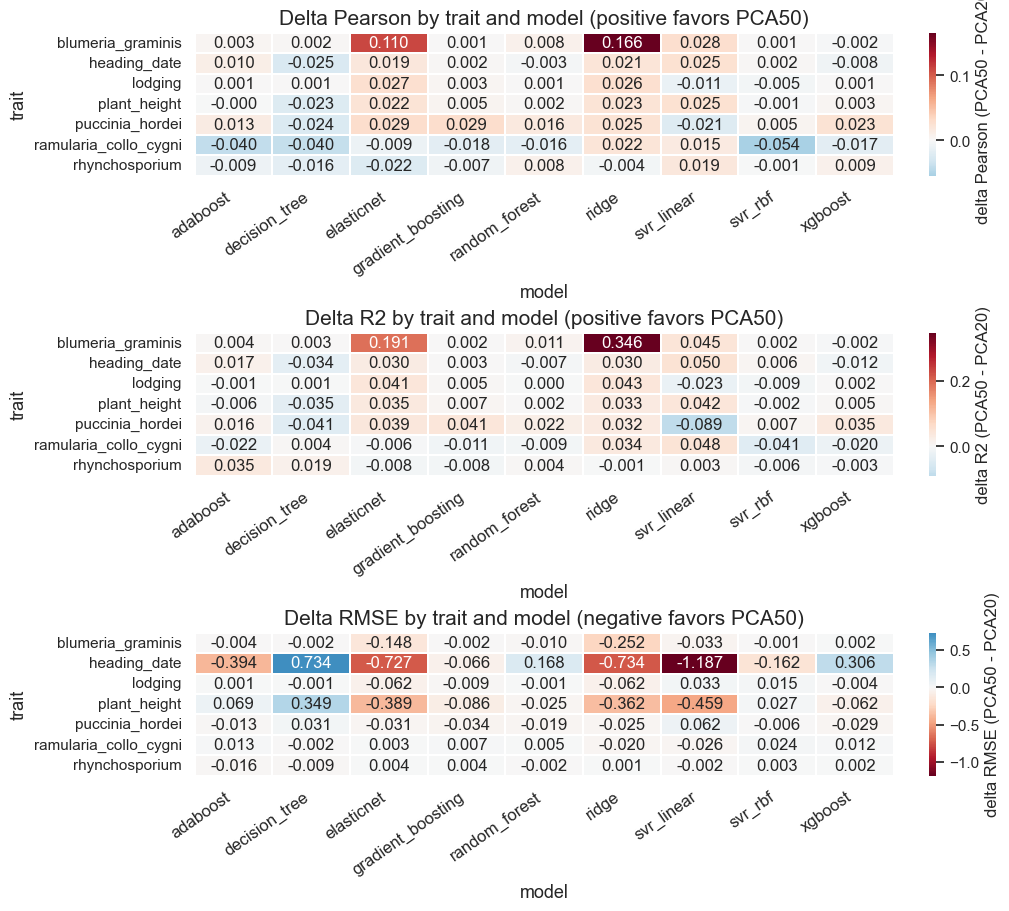

In [71]:
# =========================
# Heatmaps de deltas PCA50-PCA20 por trait x model
# =========================
if pearson_delta_matrix_df.empty:
    print('[WARN] Sin matriz de deltas para graficar heatmaps.')
else:
    n_models = pearson_delta_matrix_df.shape[1]
    n_traits = pearson_delta_matrix_df.shape[0]
    fig_h = max(9, 2.2 * 3 + 0.2 * n_traits)
    fig_w = max(10, 1.0 * n_models)

    fig, axes = plt.subplots(3, 1, figsize=(fig_w, fig_h), constrained_layout=True)

    sns.heatmap(
        pearson_delta_matrix_df,
        ax=axes[0],
        cmap='RdBu_r',
        center=0,
        annot=True,
        fmt='.3f',
        linewidths=0.3,
        cbar_kws={'label': 'delta Pearson (PCA50 - PCA20)'}
    )
    axes[0].set_title('Delta Pearson by trait and model (positive favors PCA50)', fontsize=15)
    axes[0].set_xlabel('model', fontsize=13)
    axes[0].set_ylabel('trait', fontsize=13)

    sns.heatmap(
        r2_delta_matrix_df,
        ax=axes[1],
        cmap='RdBu_r',
        center=0,
        annot=True,
        fmt='.3f',
        linewidths=0.3,
        cbar_kws={'label': 'delta R2 (PCA50 - PCA20)'}
    )
    axes[1].set_title('Delta R2 by trait and model (positive favors PCA50)', fontsize=15)
    axes[1].set_xlabel('model', fontsize=13)
    axes[1].set_ylabel('trait', fontsize=13)

    sns.heatmap(
        rmse_delta_matrix_df,
        ax=axes[2],
        cmap='RdBu',
        center=0,
        annot=True,
        fmt='.3f',
        linewidths=0.3,
        cbar_kws={'label': 'delta RMSE (PCA50 - PCA20)'}
    )
    axes[2].set_title('Delta RMSE by trait and model (negative favors PCA50)', fontsize=15)
    axes[2].set_xlabel('model', fontsize=13)
    axes[2].set_ylabel('trait', fontsize=13)

    for ax in axes:
        ax.tick_params(axis='x', labelsize=12)
        ax.tick_params(axis='y', labelsize=11)
        for lbl in ax.get_xticklabels():
            lbl.set_rotation(35)
            lbl.set_ha('right')

    plt.show()


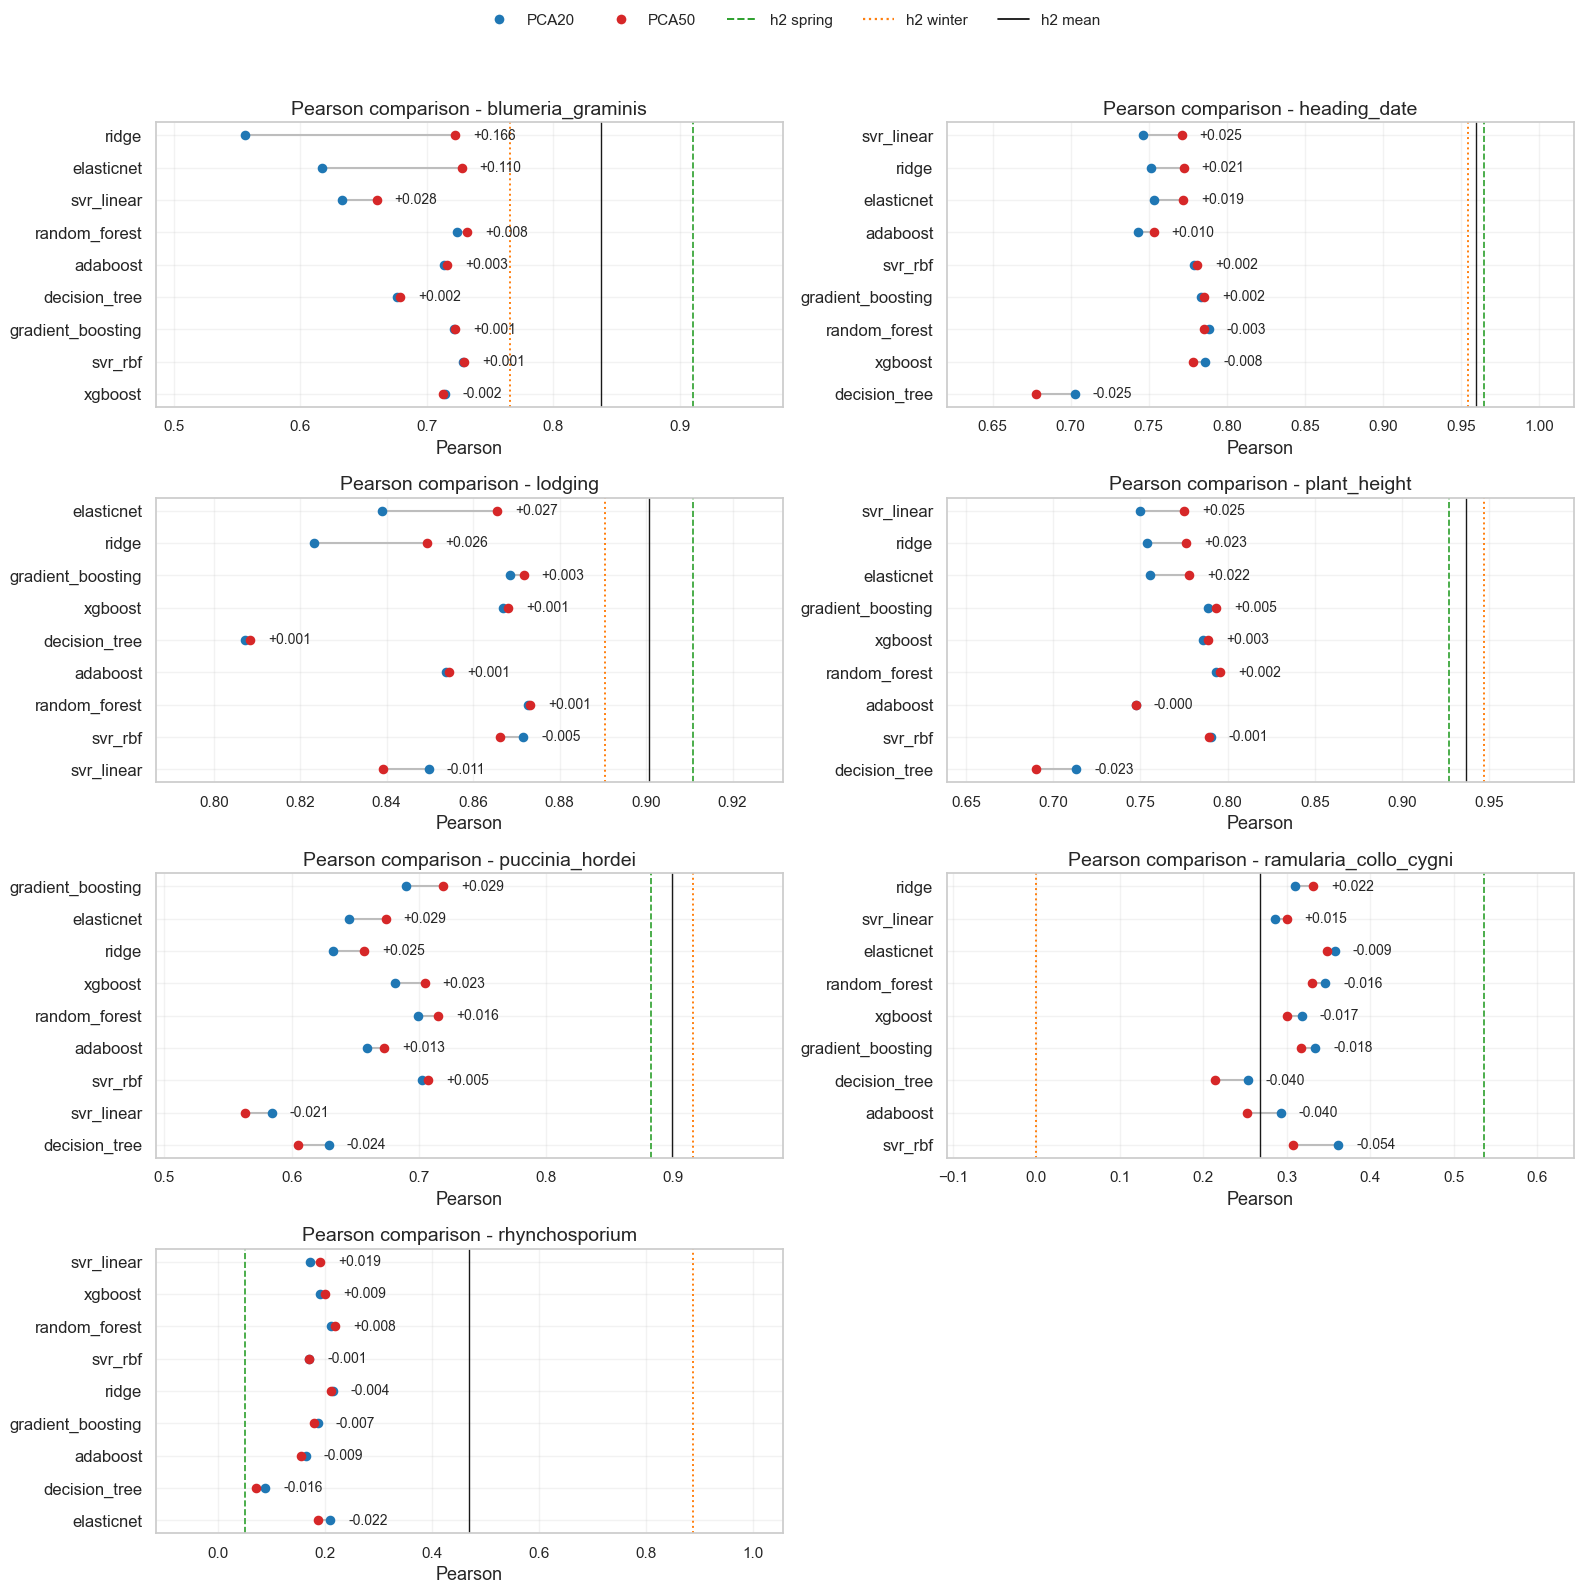

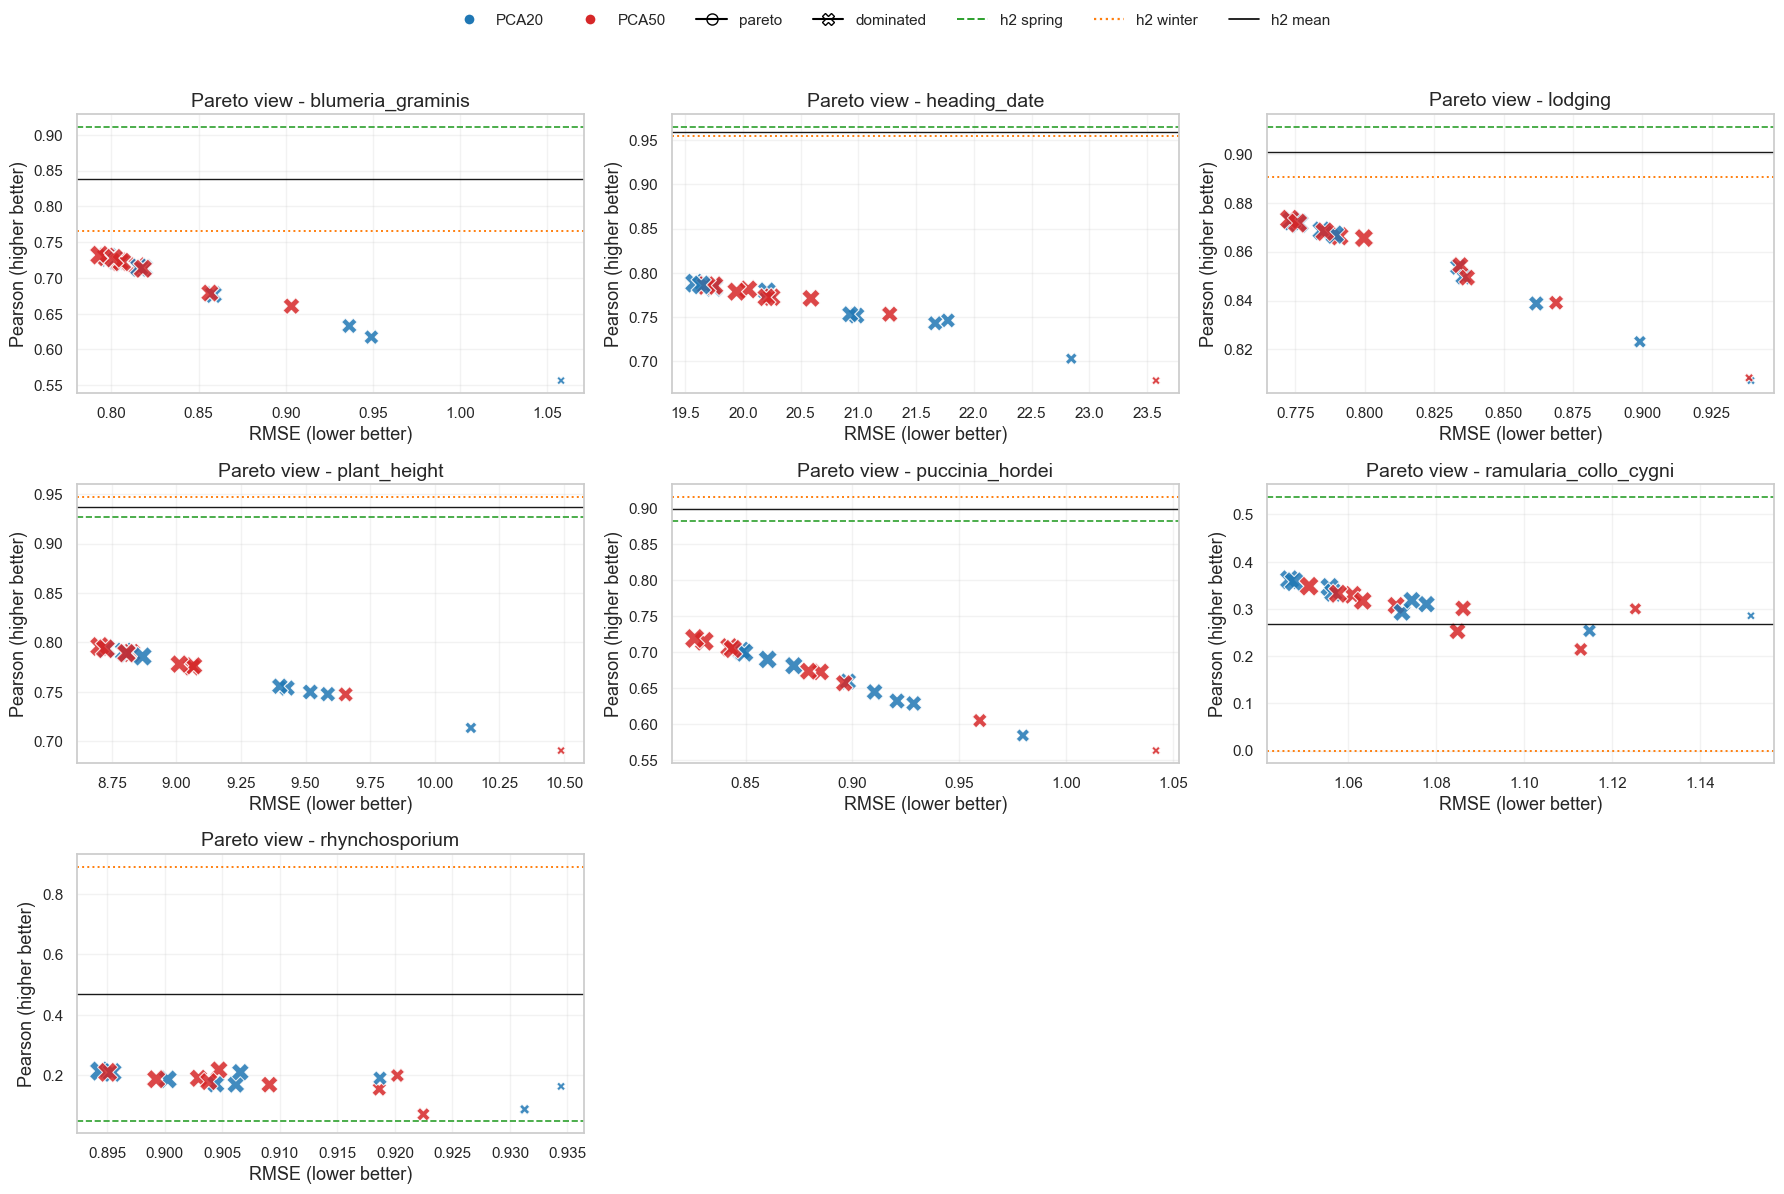

In [72]:
# =========================
# Trait visuals: dumbbell Pearson + Pareto scatter (with heritability refs)
# =========================
# Options: 'all' | 'mean_only' | 'season_only'
H2_LINE_MODE = 'all'

h2_map_spring = {}
h2_map_winter = {}
h2_map_mean = {}
if 'heritability_df' in globals() and isinstance(heritability_df, pd.DataFrame) and not heritability_df.empty:
    h2_tmp = heritability_df.copy()
    h2_tmp['trait'] = h2_tmp['trait'].astype(str).str.strip().str.lower()
    if 'h2_spring' in h2_tmp.columns:
        h2_map_spring = h2_tmp.set_index('trait')['h2_spring'].to_dict()
    if 'h2_winter' in h2_tmp.columns:
        h2_map_winter = h2_tmp.set_index('trait')['h2_winter'].to_dict()
    if 'h2_mean' in h2_tmp.columns:
        h2_map_mean = h2_tmp.set_index('trait')['h2_mean'].to_dict()


def get_h2_refs(trait_key: str) -> dict:
    refs = {}
    if H2_LINE_MODE in ['all', 'season_only']:
        refs['h2_spring'] = h2_map_spring.get(trait_key, np.nan)
        refs['h2_winter'] = h2_map_winter.get(trait_key, np.nan)
    if H2_LINE_MODE in ['all', 'mean_only']:
        refs['h2_mean'] = h2_map_mean.get(trait_key, np.nan)
    return refs


def draw_h2_lines(ax, refs: dict, orientation: str = 'vertical') -> None:
    for key, val in refs.items():
        if pd.isna(val):
            continue
        if key == 'h2_spring':
            kwargs = dict(color='#2ca02c', linestyle='--', linewidth=1.2)
        elif key == 'h2_winter':
            kwargs = dict(color='#ff7f0e', linestyle=':', linewidth=1.4)
        else:
            kwargs = dict(color='black', linestyle='-', linewidth=1.0, alpha=0.9)

        if orientation == 'vertical':
            ax.axvline(val, **kwargs)
        else:
            ax.axhline(val, **kwargs)


def h2_legend_handles() -> list:
    handles = []
    if H2_LINE_MODE in ['all', 'season_only']:
        handles.append(plt.Line2D([0], [0], color='#2ca02c', linestyle='--', linewidth=1.4, label='h2 spring'))
        handles.append(plt.Line2D([0], [0], color='#ff7f0e', linestyle=':', linewidth=1.6, label='h2 winter'))
    if H2_LINE_MODE in ['all', 'mean_only']:
        handles.append(plt.Line2D([0], [0], color='black', linestyle='-', linewidth=1.2, label='h2 mean'))
    return handles


if 'pca20_vs_pca50_df' not in globals() or pca20_vs_pca50_df.empty:
    print('[WARN] No hay comparativa PCA20/PCA50 para hacer graficos por trait.')
else:
    # A) Dumbbell Pearson per trait
    trait_list = sorted(pca20_vs_pca50_df['trait'].dropna().astype(str).str.strip().str.lower().unique().tolist())
    if trait_list:
        ncols = 2
        nrows = int(np.ceil(len(trait_list) / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(16, max(4 * nrows, 5)), squeeze=False)
        axes_flat = axes.flatten()

        for i, trait in enumerate(trait_list):
            ax = axes_flat[i]
            g = (
                pca20_vs_pca50_df[pca20_vs_pca50_df['trait'].astype(str).str.strip().str.lower() == trait]
                .dropna(subset=['pearson_pca20', 'pearson_pca50'])
                .sort_values('delta_pearson_50_minus_20')
                .reset_index(drop=True)
            )

            if g.empty:
                ax.set_visible(False)
                continue

            y = np.arange(len(g))
            x20 = g['pearson_pca20'].to_numpy(dtype=float)
            x50 = g['pearson_pca50'].to_numpy(dtype=float)

            ax.hlines(y, x20, x50, color='#bdbdbd', linewidth=1.5)
            ax.scatter(x20, y, color='#1f77b4', s=35, label='PCA20', zorder=3)
            ax.scatter(x50, y, color='#d62728', s=35, label='PCA50', zorder=3)

            refs = get_h2_refs(trait)
            draw_h2_lines(ax, refs, orientation='vertical')

            xmin = np.nanmin(np.r_[x20, x50])
            xmax = np.nanmax(np.r_[x20, x50])
            hrefs = [v for v in refs.values() if pd.notna(v)]
            if hrefs:
                xmin = min(xmin, np.nanmin(hrefs))
                xmax = max(xmax, np.nanmax(hrefs))
            span = max(0.02, xmax - xmin)
            xpad = 0.20 * span

            for yi, delta in enumerate(g['delta_pearson_50_minus_20'].to_numpy(dtype=float)):
                xpos = max(x20[yi], x50[yi]) + 0.04 * span
                ax.text(xpos, yi, f'{delta:+.3f}', va='center', fontsize=10)

            ax.set_xlim(xmin - xpad, xmax + xpad)
            ax.set_yticks(y)
            ax.set_yticklabels(g['model'].tolist(), fontsize=12)
            ax.set_title(f'Pearson comparison - {trait}', fontsize=14)
            ax.set_xlabel('Pearson', fontsize=13)
            ax.grid(alpha=0.25)

        for j in range(len(trait_list), len(axes_flat)):
            axes_flat[j].set_visible(False)

        handles = [
            plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#1f77b4', markersize=8, label='PCA20'),
            plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#d62728', markersize=8, label='PCA50'),
        ] + h2_legend_handles()

        fig.legend(handles=handles, loc='upper center', ncol=max(2, len(handles)), frameon=False)
        fig.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

if pareto_pca_df.empty:
    print('[WARN] No hay puntos Pareto PCA20/PCA50 para graficar.')
else:
    from matplotlib.lines import Line2D

    trait_list = sorted(pareto_pca_df['trait'].dropna().astype(str).str.strip().str.lower().unique().tolist())
    ncols = 3
    nrows = int(np.ceil(len(trait_list) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, max(4 * nrows, 5)), squeeze=False)
    axes_flat = axes.flatten()

    palette = {'pca20': '#1f77b4', 'pca50': '#d62728'}
    markers = {'pareto': 'o', 'dominated': 'X'}

    for i, trait in enumerate(trait_list):
        ax = axes_flat[i]
        g = pareto_pca_df[pareto_pca_df['trait'].astype(str).str.strip().str.lower() == trait].copy()

        sns.scatterplot(
            data=g,
            x='rmse',
            y='pearson_r',
            hue='representation',
            style='pareto_flag',
            markers=markers,
            size='r2',
            sizes=(40, 220),
            palette=palette,
            alpha=0.85,
            ax=ax,
            legend=False,
        )

        refs = get_h2_refs(trait)
        draw_h2_lines(ax, refs, orientation='horizontal')

        # annotate only pareto points for readability
        g_p = g[g['is_pareto']].copy()
        for _, row in g_p.iterrows():
            ax.text(row['rmse'], row['pearson_r'], f" {row['model']}", fontsize=11, alpha=0.9)

        ax.set_title(f'Pareto view - {trait}', fontsize=14)
        ax.set_xlabel('RMSE (lower better)', fontsize=13)
        ax.set_ylabel('Pearson (higher better)', fontsize=13)
        ax.grid(alpha=0.25)

    for j in range(len(trait_list), len(axes_flat)):
        axes_flat[j].set_visible(False)

    legend_handles = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#1f77b4', markersize=8, label='PCA20'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#d62728', markersize=8, label='PCA50'),
        Line2D([0], [0], marker='o', color='black', markerfacecolor='none', markersize=8, label='pareto'),
        Line2D([0], [0], marker='X', color='black', markerfacecolor='none', markersize=8, label='dominated'),
    ] + h2_legend_handles()

    fig.legend(handles=legend_handles, loc='upper center', ncol=max(4, len(legend_handles)), frameon=False)
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()


,trait,pca20_r,pca50_r,snp_r,gblup_r
0,blumeria_graminis,0.729,0.732,0.749,0.763
1,heading_date,0.788,0.786,0.802,0.797
2,lodging,0.873,0.873,0.877,0.872
3,plant_height,0.794,0.796,0.811,0.816
4,puccinia_hordei,0.702,0.719,0.734,0.755
5,ramularia_collo_cygni,0.362,0.348,0.346,0.385
6,rhynchosporium,0.214,0.218,0.286,0.274


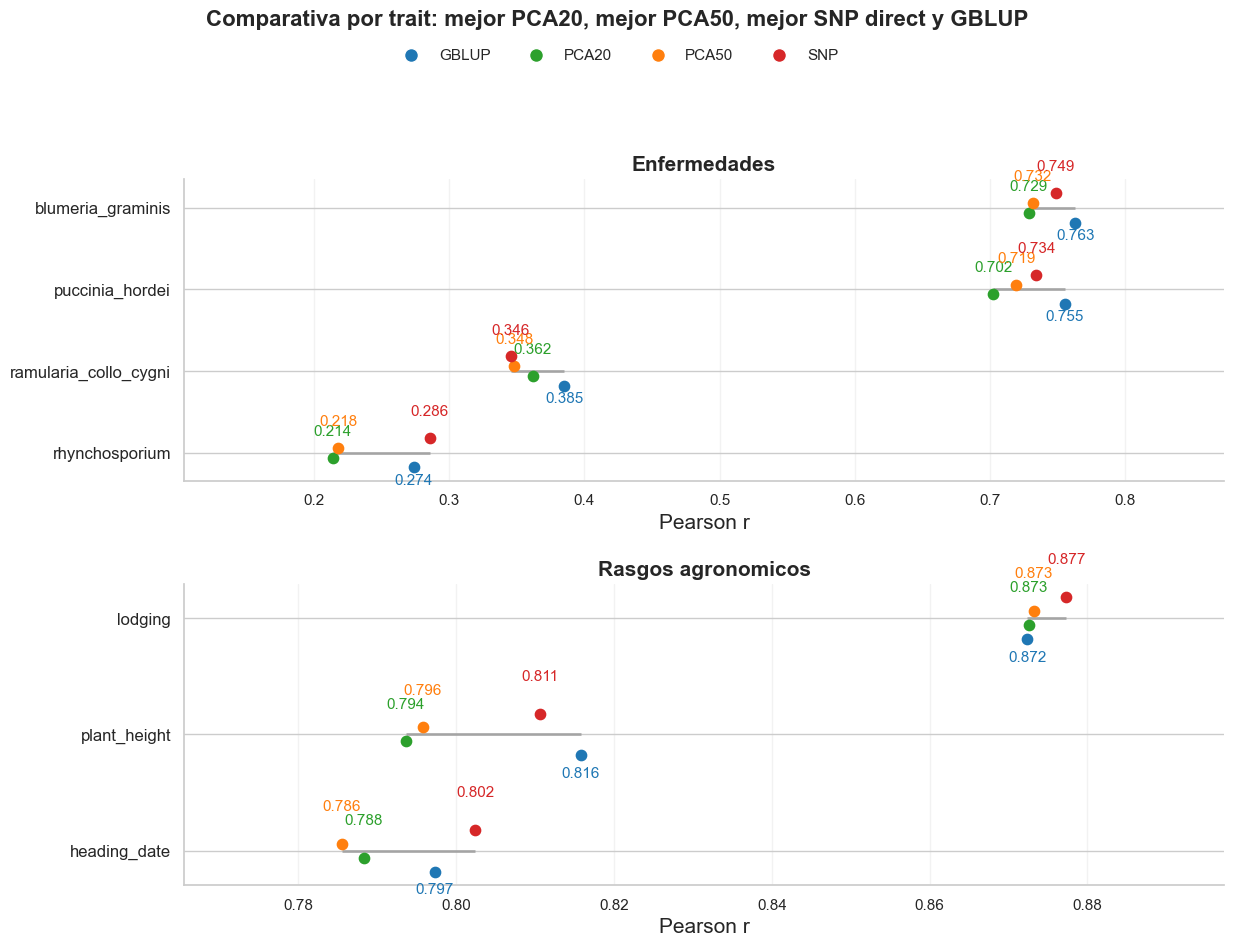

Guardado: outputs_nested5x3\_comparativas\trait_compare_best4_absolute_2panels_fixed.png


In [90]:
# =========================================================
# FIX: tabla best4 por trait (sin mezclar GBLUP dentro de SNP)
# + plot con etiquetas para los 4 metodos
# =========================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

cmp = summary_all.copy()
for c in ["pearson_r", "r2", "rmse"]:
    cmp[c] = pd.to_numeric(cmp[c], errors="coerce")

cmp["trait"] = cmp["trait"].astype(str).str.strip().str.lower()
cmp["model"] = cmp["model"].astype(str).str.strip().str.lower()
cmp["representation"] = cmp["representation"].astype(str).str.strip().str.lower()

# Mejor por representacion, EXCLUYENDO GBLUP del pool ML
def best_by_rep(rep_value, out_col):
    d = cmp[(cmp["representation"] == rep_value) & (cmp["model"] != "gblup")].copy()
    if d.empty:
        return pd.DataFrame(columns=["trait", out_col])
    d = (
        d.sort_values(["trait", "pearson_r", "r2", "rmse"], ascending=[True, False, False, True])
         .groupby("trait", as_index=False).first()[["trait", "pearson_r"]]
         .rename(columns={"pearson_r": out_col})
    )
    return d

pca20_best = best_by_rep("pca20", "pca20_r")
pca50_best = best_by_rep("pca50", "pca50_r")
snp_best   = best_by_rep("snp_direct", "snp_r")   # <-- ya no mete gblup

# Mejor GBLUP por trait
gblup_best = (
    cmp[cmp["model"] == "gblup"]
    .sort_values(["trait", "pearson_r", "r2", "rmse"], ascending=[True, False, False, True])
    .groupby("trait", as_index=False).first()[["trait", "pearson_r"]]
    .rename(columns={"pearson_r": "gblup_r"})
)

traits_df = pd.DataFrame({"trait": sorted(cmp["trait"].unique())})
best4_by_trait_df = (
    traits_df
    .merge(pca20_best, on="trait", how="left")
    .merge(pca50_best, on="trait", how="left")
    .merge(snp_best,   on="trait", how="left")
    .merge(gblup_best, on="trait", how="left")
)

display(best4_by_trait_df.style.format({
    "pca20_r":"{:.3f}", "pca50_r":"{:.3f}", "snp_r":"{:.3f}", "gblup_r":"{:.3f}"
}))

# -------------------- Figura (2 paneles) --------------------
traits_enf = ["blumeria_graminis", "puccinia_hordei", "ramularia_collo_cygni", "rhynchosporium"]
traits_agr = ["heading_date", "lodging", "plant_height"]

def sort_block(d):
    d = d.copy()
    d["best_ml_r"] = d[["pca20_r", "pca50_r", "snp_r"]].max(axis=1, skipna=True)
    return d.sort_values("best_ml_r", ascending=False).reset_index(drop=True)

df_enf = sort_block(best4_by_trait_df[best4_by_trait_df["trait"].isin(traits_enf)])
df_agr = sort_block(best4_by_trait_df[best4_by_trait_df["trait"].isin(traits_agr)])

colors = {"gblup_r":"#1f77b4","pca20_r":"#2ca02c","pca50_r":"#ff7f0e","snp_r":"#d62728"}
labels = {"gblup_r":"GBLUP","pca20_r":"PCA20","pca50_r":"PCA50","snp_r":"SNP"}
offsets = {"gblup_r":-0.18,"pca20_r":-0.06,"pca50_r":0.06,"snp_r":0.18}
# offsets de texto para que no se pisen
text_offsets = {"gblup_r":-0.34,"pca20_r":0.26,"pca50_r":0.38,"snp_r":0.50}

def panel_limits(d):
    vals = d[["gblup_r","pca20_r","pca50_r","snp_r"]].to_numpy().astype(float).ravel()
    vals = vals[~np.isnan(vals)]
    lo, hi = vals.min(), vals.max()
    pad = max(0.02, (hi - lo) * 0.20)
    return max(0.0, lo - pad), min(1.0, hi + pad)

def draw_panel(ax, d, title):
    y_base = np.arange(len(d))[::-1]
    ax.set_yticks(y_base)
    ax.set_yticklabels(d["trait"], fontsize=12)

    for i, row in d.iterrows():
        y = y_base[i]
        vals = [row[c] for c in ["gblup_r","pca20_r","pca50_r","snp_r"] if pd.notna(row[c])]
        if vals:
            ax.hlines(y, min(vals), max(vals), color="#9a9a9a", linewidth=2, alpha=0.8)

        for c in ["gblup_r","pca20_r","pca50_r","snp_r"]:
            v = row[c]
            if pd.notna(v):
                ax.scatter(v, y + offsets[c], s=55, color=colors[c], zorder=3)
                ax.text(v, y + text_offsets[c], f"{v:.3f}", fontsize=11, ha="center", va="center", color=colors[c])

    x0, x1 = panel_limits(d)
    ax.set_xlim(x0, x1)
    ax.set_title(title, fontsize=15, fontweight="bold")
    ax.grid(axis="x", alpha=0.25)
    ax.set_xlabel("Pearson r", fontsize=15)
    sns.despine(ax=ax, left=False, bottom=False)

fig, axes = plt.subplots(2, 1, figsize=(12.5, 9.5), constrained_layout=False)
draw_panel(axes[0], df_enf, "Enfermedades")
draw_panel(axes[1], df_agr, "Rasgos agronomicos")

fig.suptitle("Comparativa por trait: mejor PCA20, mejor PCA50, mejor SNP direct y GBLUP",
             fontsize=16, fontweight="bold", y=0.995)

legend_handles = [Line2D([0],[0], marker='o', color='w', markerfacecolor=colors[k], markersize=10, label=labels[k])
                  for k in ["gblup_r","pca20_r","pca50_r","snp_r"]]
fig.legend(handles=legend_handles, loc="upper center", ncol=4, frameon=False, bbox_to_anchor=(0.5, 0.968))

plt.tight_layout(rect=[0, 0, 1, 0.90])

out_png = EXPORT_DIR / "trait_compare_best4_absolute_2panels_fixed.png"
plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.show()
print("Guardado:", out_png)


Orden de tu dumbbell (enfermedades primero y luego agronómicos):

| Rasgo | Mejor modelo | Representación | Pearson r (ML) | Pearson r (GBLUP) | Δ (ML - GBLUP) | H² (rango) |
| --- | --- | --- | ---:| ---:| ---:| --- |
| blumeria_graminis | xgboost | snp_direct | 0.749 | 0.763 | -0.014 | 0.765-0.911 |
| puccinia_hordei | xgboost | snp_direct | 0.734 | 0.755 | -0.021 | 0.883-0.916 |
| ramularia_collo_cygni | svr_rbf | pca20 | 0.362 | 0.385 | -0.023 | 0.000-0.537 |
| rhynchosporium | xgboost | snp_direct | 0.286 | 0.274 | +0.012 | 0.050-0.889 |
| heading_date | xgboost | snp_direct | 0.802 | 0.797 | +0.005 | 0.954-0.965 |
| lodging | ridge | snp_direct | 0.877 | 0.872 | +0.005 | 0.891-0.911 |
| plant_height | elasticnet | snp_direct | 0.811 | 0.816 | -0.005 | 0.927-0.947 |

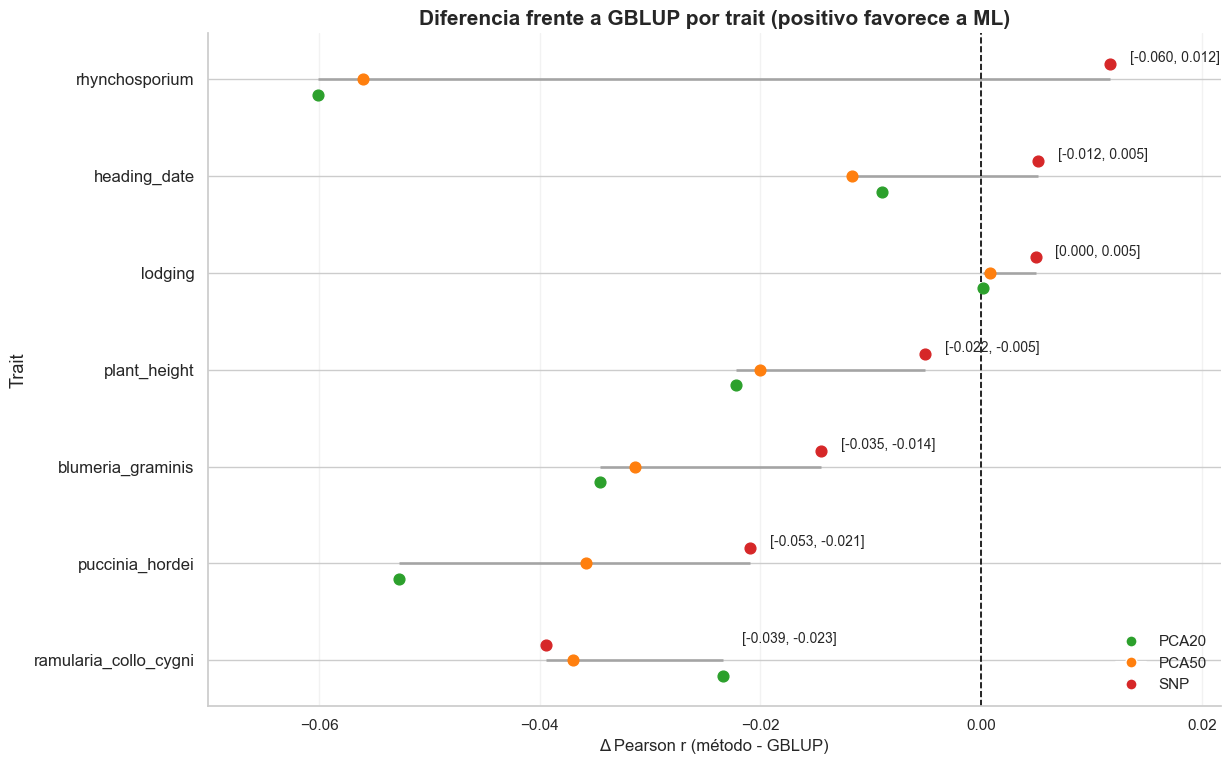

Guardado: outputs_nested5x3\_comparativas\trait_compare_delta_vs_gblup_fixed_v2.png


,trait,delta_pca20,delta_pca50,delta_snp,delta_min,delta_max
6,rhynchosporium,-0.060084,-0.055985,0.011707,-0.060084,0.011707
1,heading_date,-0.008971,-0.011731,0.005156,-0.011731,0.005156
2,lodging,0.000201,0.000829,0.004936,0.000201,0.004936
3,plant_height,-0.022178,-0.020008,-0.005111,-0.022178,-0.005111
0,blumeria_graminis,-0.034518,-0.031401,-0.014488,-0.034518,-0.014488
4,puccinia_hordei,-0.052752,-0.035816,-0.020961,-0.052752,-0.020961
5,ramularia_collo_cygni,-0.023430,-0.037029,-0.039462,-0.039462,-0.023430


In [74]:
# =========================================================
# Delta vs GBLUP por trait (corregido: labels de corchetes)
# =========================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

req = {"trait", "pca20_r", "pca50_r", "snp_r", "gblup_r"}
if "best4_by_trait_df" not in globals() or not req.issubset(best4_by_trait_df.columns):
    raise RuntimeError("Falta best4_by_trait_df con columnas esperadas.")

delta_wide = best4_by_trait_df.copy()
delta_wide["trait"] = delta_wide["trait"].astype(str).str.strip().str.lower()
for c in ["pca20_r", "pca50_r", "snp_r", "gblup_r"]:
    delta_wide[c] = pd.to_numeric(delta_wide[c], errors="coerce")

# Deltas explícitos por método (método - GBLUP)
delta_wide["delta_pca20"] = delta_wide["pca20_r"] - delta_wide["gblup_r"]
delta_wide["delta_pca50"] = delta_wide["pca50_r"] - delta_wide["gblup_r"]
delta_wide["delta_snp"]   = delta_wide["snp_r"]   - delta_wide["gblup_r"]

# Rango por trait para línea y corchetes
delta_cols = ["delta_pca20", "delta_pca50", "delta_snp"]
delta_wide["delta_min"] = delta_wide[delta_cols].min(axis=1, skipna=True)
delta_wide["delta_max"] = delta_wide[delta_cols].max(axis=1, skipna=True)

# Tabla larga para puntos
long = (
    delta_wide[["trait", "delta_pca20", "delta_pca50", "delta_snp"]]
    .melt(id_vars="trait", var_name="method", value_name="delta_vs_gblup")
    .dropna(subset=["delta_vs_gblup"])
    .copy()
)

method_map = {
    "delta_pca20": "PCA20",
    "delta_pca50": "PCA50",
    "delta_snp": "SNP",
}
method_color = {
    "delta_pca20": "#2ca02c",
    "delta_pca50": "#ff7f0e",
    "delta_snp": "#d62728",
}
method_offset = {
    "delta_pca20": -0.16,
    "delta_pca50": 0.00,
    "delta_snp": 0.16,
}

# Orden traits por mejor mejora vs GBLUP
trait_order = delta_wide.sort_values("delta_max", ascending=False)["trait"].tolist()
y_map = {t: i for i, t in enumerate(trait_order[::-1])}  # top->bottom

# límites x
vals = long["delta_vs_gblup"].to_numpy()
x_min, x_max = float(np.min(vals)), float(np.max(vals))
pad = max(0.01, 0.12 * (x_max - x_min if x_max > x_min else 1.0))

fig, ax = plt.subplots(figsize=(12.5, 7.8))

for t in trait_order:
    y0 = y_map[t]
    row = delta_wide.loc[delta_wide["trait"] == t].iloc[0]
    sub = long[long["trait"] == t]

    # segmento min-max del trait
    ax.hlines(y0, row["delta_min"], row["delta_max"], color="#9a9a9a", linewidth=2, alpha=0.8, zorder=1)

    # puntos métodos
    for _, r in sub.iterrows():
        ax.scatter(
            r["delta_vs_gblup"],
            y0 + method_offset[r["method"]],
            s=60,
            color=method_color[r["method"]],
            zorder=3
        )

    # etiqueta de corchetes CORRECTA (de delta_wide)
    ax.text(
        row["delta_max"] + 0.0018,
        y0 + 0.22,
        f"[{row['delta_min']:.3f}, {row['delta_max']:.3f}]",
        fontsize=10,
        va="center"
    )

# línea de empate
ax.axvline(0, color="black", linestyle="--", linewidth=1.2)

ax.set_yticks([y_map[t] for t in trait_order])
ax.set_yticklabels(trait_order, fontsize=12)
ax.set_xlim(x_min - pad, x_max + pad)
ax.set_xlabel("Δ Pearson r (método - GBLUP)")
ax.set_ylabel("Trait", fontsize=13)
ax.set_title("Diferencia frente a GBLUP por trait (positivo favorece a ML)", fontsize=15, fontweight="bold")
ax.grid(axis="x", alpha=0.25)
sns.despine(ax=ax)

handles = [
    Line2D([0], [0], marker="o", color="w",
           markerfacecolor=method_color[m], markersize=8, label=method_map[m])
    for m in ["delta_pca20", "delta_pca50", "delta_snp"]
]
ax.legend(handles=handles, loc="lower right", frameon=False)

plt.tight_layout()
out_png = EXPORT_DIR / "trait_compare_delta_vs_gblup_fixed_v2.png"
plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.show()

print("Guardado:", out_png)

# (opcional) auditoría rápida por tabla
audit_cols = ["trait", "delta_pca20", "delta_pca50", "delta_snp", "delta_min", "delta_max"]
display(delta_wide[audit_cols].sort_values("delta_max", ascending=False))


C:\Users\Reyes\AppData\Local\Temp\ipykernel_21292\2940190373.py:95: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=13)


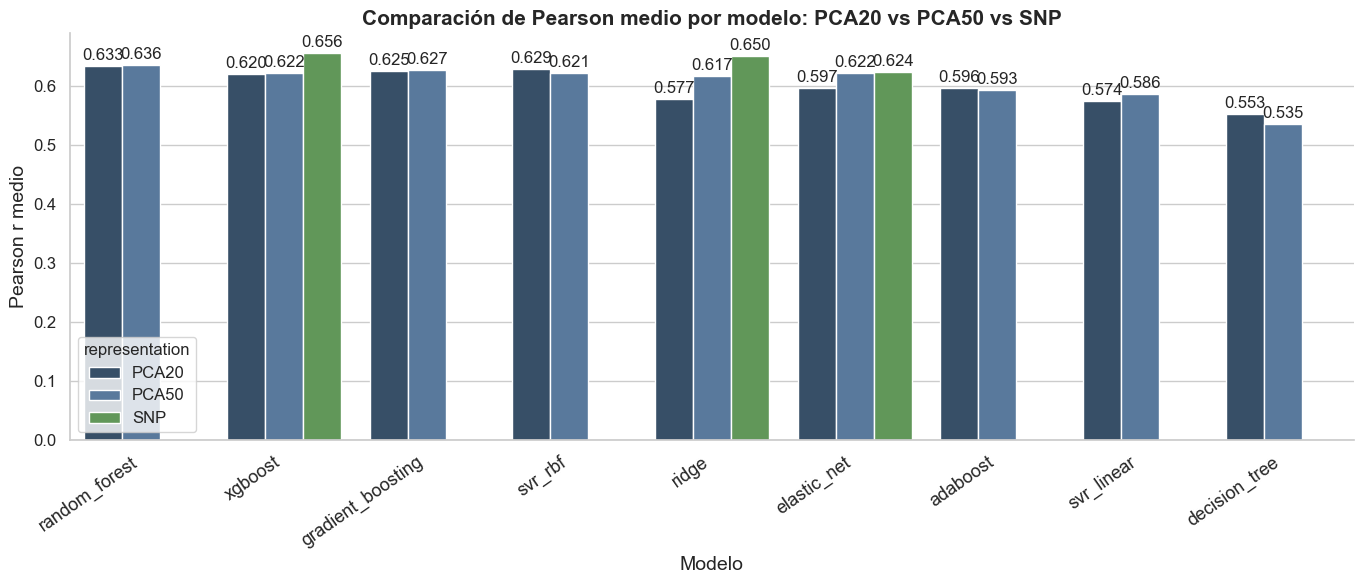

Guardado: C:\Users\Reyes\OneDrive\PC_REYES\Master_Big_Data_Data_Science\14MBID\2026\Code\repo\outputs_nested5x3\_comparativas\barplot_mean_pearson_pca20_pca50_snp.png


In [75]:
# =========================================================
# Barplot comparativo PCA20 vs PCA50 vs SNP (incluyendo ajuste de nombres)
# =========================================================

from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

root = Path.cwd().resolve()
if not (root / "results").exists():
    candidates = [
        root / "repo",
        root / "nested5x3_unificados",
        root.parent,
        root.parent / "repo",
        root.parent / "nested5x3_unificados",
    ]
    for cand in candidates:
        if (cand / "results").exists():
            root = cand
            break

pca20_path = root / "results/pca20_summary_nested5x3/pca20_nested5x3_model_summary.csv"
pca50_path = root / "results/pca50_summary_nested5x3/pca50_nested5x3_model_summary.csv"
snp_path   = root / "results/snp_summary_nested5x3/snp_nested5x3_model_summary.csv"

def normalize_model_name(s):
    s = str(s).strip().lower()
    mapping = {
        "elasticnet": "elastic_net",
        "elastic net": "elastic_net",
        "elastic-net": "elastic_net",
        "randomforest": "random_forest",
        "random forest": "random_forest",
        "randomforestregressor": "random_forest",
        "gradientboosting": "gradient_boosting",
        "gradient boosting": "gradient_boosting",
        "gradientboostingregressor": "gradient_boosting",
        "adaboostregressor": "adaboost",
    }
    return mapping.get(s, s)

def load_summary(path, rep_label):
    df = pd.read_csv(path).copy()
    mean_col = "mean_r" if "mean_r" in df.columns else "mean_pearson_r"
    out = df[["model", mean_col]].rename(columns={mean_col: "mean_r"})
    out["model"] = out["model"].map(normalize_model_name)
    out["representation"] = rep_label
    return out

p20 = load_summary(pca20_path, "PCA20")
p50 = load_summary(pca50_path, "PCA50")
snp = load_summary(snp_path, "SNP")

plot_df = pd.concat([p20, p50, snp], ignore_index=True)

# Orden de modelos de mejor a peor (media global entre representaciones disponibles)
model_order = (
    plot_df.groupby("model", as_index=False)["mean_r"]
    .mean()
    .sort_values("mean_r", ascending=False)["model"]
    .tolist()
)

# Rehacer gráfico con ese orden
plt.figure(figsize=(13.8, 6.0))
ax = sns.barplot(
    data=plot_df,
    x="model",
    y="mean_r",
    hue="representation",
    order=model_order,
    hue_order=["PCA20", "PCA50", "SNP"],
    palette=["#2F4F6F", "#4E79A7", "#59A14F"],
    errorbar=None
)

for p in ax.patches:
    h = p.get_height()
    if pd.notna(h) and h > 0:
        ax.annotate(
            f"{h:.3f}",
            (p.get_x() + p.get_width()/2, h),
            ha="center",
            va="bottom",
            fontsize=12,
            xytext=(0, 2),
            textcoords="offset points"
        )

ax.set_title("Comparación de Pearson medio por modelo: PCA20 vs PCA50 vs SNP", fontsize=15, fontweight="bold")
ax.set_xlabel("Modelo", fontsize=14)
ax.set_ylabel("Pearson r medio", fontsize=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=13)
ax.tick_params(axis="y", labelsize=12)
if ax.legend_ is not None:
    ax.legend_.set_title(ax.legend_.get_title().get_text(), prop={"size": 12})
    for txt in ax.legend_.get_texts():
        txt.set_fontsize(12)
sns.despine()
plt.tight_layout()

out_dir = root / "outputs_nested5x3" / "_comparativas"
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "barplot_mean_pearson_pca20_pca50_snp.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Guardado: {out_path}")


## GBLUP vs Mejor ML Por Trait

Comparativa puntual por rasgo entre `GBLUP` y el mejor modelo de ML considerando conjuntamente PCA20, PCA50 y SNP direct.

Best ML por trait:


,trait,best_ml_model,best_ml_representation,best_ml_run,best_ml_r,best_ml_r2,best_ml_rmse
0,lodging,ridge,snp_direct,53_snp_direct_legacy::snp_blocks_notebook_nest...,0.877308,0.768605,0.761419
1,plant_height,elasticnet,snp_direct,53_snp_direct_legacy::snp_blocks_notebook_nest...,0.810661,0.656217,8.402720
2,heading_date,xgboost,snp_direct,53_snp_direct_legacy::snp_blocks_notebook_nest...,0.802406,0.643340,18.977351
3,blumeria_graminis,xgboost,snp_direct,53_snp_direct_legacy::snp_blocks_notebook_nest...,0.748690,0.560421,0.771705
4,puccinia_hordei,xgboost,snp_direct,53_snp_direct_legacy::snp_blocks_notebook_nest...,0.734139,0.538311,0.807654
5,ramularia_collo_cygni,svr_rbf,pca20,10_pca20_svr_-_estructura_unificada_+_nested_c...,0.361721,0.128292,1.046627
6,rhynchosporium,xgboost,snp_direct,53_snp_direct_legacy::snp_blocks_notebook_nest...,0.285655,0.070401,0.882466


Top 3 ML por trait:


,trait,rank_ml_trait,model,representation,run_name,pearson_r,r2,rmse
0,blumeria_graminis,1,xgboost,snp_direct,53_snp_direct_legacy::snp_blocks_notebook_nest...,0.748690,0.560421,0.771705
1,blumeria_graminis,2,ridge,snp_direct,53_snp_direct_legacy::snp_blocks_notebook_nest...,0.748370,0.559639,0.772391
2,blumeria_graminis,3,elasticnet,snp_direct,53_snp_direct_legacy::snp_blocks_notebook_nest...,0.735424,0.540195,0.789258
3,heading_date,1,xgboost,snp_direct,53_snp_direct_legacy::snp_blocks_notebook_nest...,0.802406,0.643340,18.977351
4,heading_date,2,elasticnet,snp_direct,53_snp_direct_legacy::snp_blocks_notebook_nest...,0.800564,0.640615,19.049703
5,heading_date,3,ridge,snp_direct,53_snp_direct_legacy::snp_blocks_notebook_nest...,0.795218,0.631161,19.298644
6,lodging,1,ridge,snp_direct,53_snp_direct_legacy::snp_blocks_notebook_nest...,0.877308,0.768605,0.761419
7,lodging,2,xgboost,snp_direct,53_snp_direct_legacy::snp_blocks_notebook_nest...,0.874352,0.763854,0.769197
8,lodging,3,random_forest,pca50,40_pca50_ensemble_-_estructura_unificada_+_nes...,0.873200,0.761525,0.772980
9,plant_height,1,elasticnet,snp_direct,53_snp_direct_legacy::snp_blocks_notebook_nest...,0.810661,0.656217,8.402720


GBLUP vs mejor ML por trait:


,trait,gblup_run,gblup_r,gblup_r2,gblup_rmse,best_ml_model,best_ml_representation,best_ml_run,best_ml_r,best_ml_r2,best_ml_rmse,delta_bestml_minus_gblup
0,rhynchosporium,54_snp_direct_gblup_legacy::snp_blocks_noteboo...,0.273948,0.068389,0.883421,xgboost,snp_direct,53_snp_direct_legacy::snp_blocks_notebook_nest...,0.285655,0.070401,0.882466,0.011707
1,heading_date,54_snp_direct_gblup_legacy::snp_blocks_noteboo...,0.797251,0.634926,19.199901,xgboost,snp_direct,53_snp_direct_legacy::snp_blocks_notebook_nest...,0.802406,0.643340,18.977351,0.005156
2,lodging,54_snp_direct_gblup_legacy::snp_blocks_noteboo...,0.872372,0.760624,0.774439,ridge,snp_direct,53_snp_direct_legacy::snp_blocks_notebook_nest...,0.877308,0.768605,0.761419,0.004936
3,plant_height,54_snp_direct_gblup_legacy::snp_blocks_noteboo...,0.815771,0.665413,8.289570,elasticnet,snp_direct,53_snp_direct_legacy::snp_blocks_notebook_nest...,0.810661,0.656217,8.402720,-0.005111
4,blumeria_graminis,54_snp_direct_gblup_legacy::snp_blocks_noteboo...,0.763178,0.582337,0.752221,xgboost,snp_direct,53_snp_direct_legacy::snp_blocks_notebook_nest...,0.748690,0.560421,0.771705,-0.014488
5,puccinia_hordei,54_snp_direct_gblup_legacy::snp_blocks_noteboo...,0.755101,0.569889,0.779544,xgboost,snp_direct,53_snp_direct_legacy::snp_blocks_notebook_nest...,0.734139,0.538311,0.807654,-0.020961
6,ramularia_collo_cygni,54_snp_direct_gblup_legacy::snp_blocks_noteboo...,0.385151,0.146777,1.035470,svr_rbf,pca20,10_pca20_svr_-_estructura_unificada_+_nested_c...,0.361721,0.128292,1.046627,-0.023430


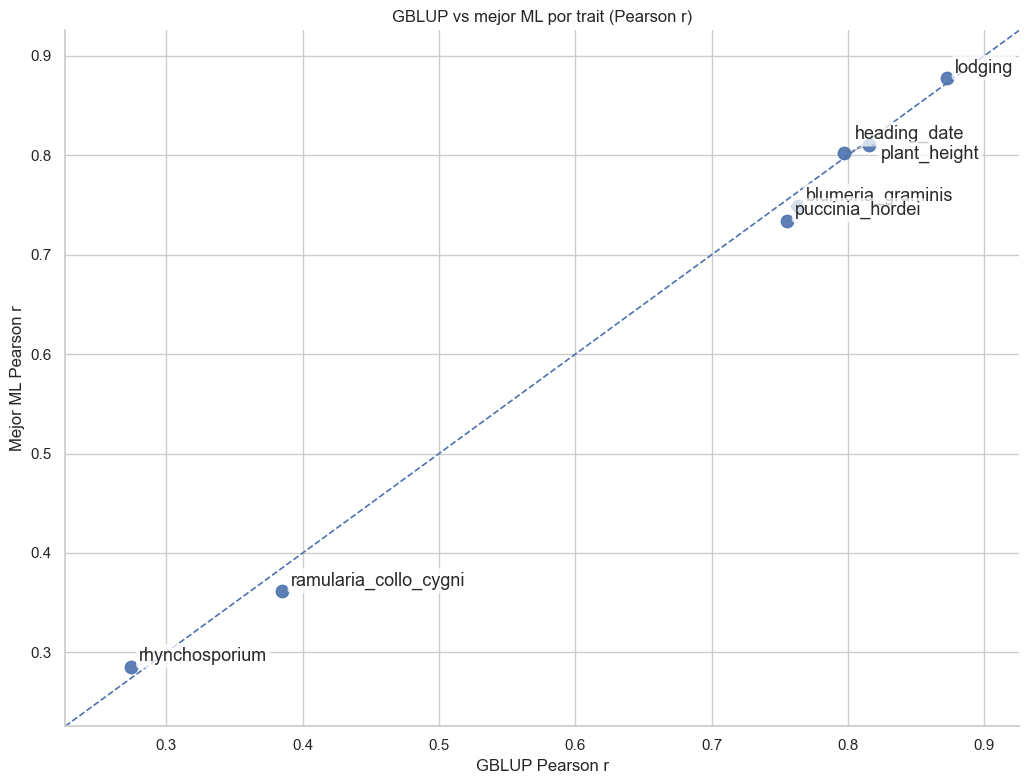

[OK] Exportes comparativa GBLUP vs ML:
- outputs_nested5x3\_comparativas\best_ml_by_trait_all_sources.csv
- outputs_nested5x3\_comparativas\top3_ml_by_trait_all_sources.csv
- outputs_nested5x3\_comparativas\gblup_vs_best_ml_by_trait.csv
- outputs_nested5x3\_comparativas\scatter_gblup_vs_best_ml_pearson.png
- outputs_nested5x3\_comparativas\gblup_vs_best_ml_report.xlsx


In [76]:
# =========================
# GBLUP vs mejor ML (tabla best, top3 y scatter)
# =========================
if summary_all.empty:
    print('[WARN] Sin summary_all para comparativa GBLUP vs ML.')
    best_ml_by_trait_df = pd.DataFrame()
    top3_ml_by_trait_df = pd.DataFrame()
    gblup_vs_best_ml_df = pd.DataFrame()
else:
    cmp = summary_all.copy()

    for col in ['pearson_r', 'r2', 'rmse']:
        if col in cmp.columns:
            cmp[col] = pd.to_numeric(cmp[col], errors='coerce')

    cmp['model'] = cmp['model'].astype(str).str.strip().str.lower()
    cmp['trait'] = cmp['trait'].astype(str).str.strip().str.lower()

    if 'representation' in cmp.columns:
        cmp['representation'] = cmp['representation'].astype(str).str.strip().str.lower()
    else:
        cmp['representation'] = 'unknown'

    # pool ML: todos menos gblup
    ml_pool = cmp[cmp['model'] != 'gblup'].copy()

    # ranking por trait (Pearson principal, desempate por R2 y RMSE)
    ml_ranked = (
        ml_pool
        .sort_values(['trait', 'pearson_r', 'r2', 'rmse'], ascending=[True, False, False, True])
        .reset_index(drop=True)
    )

    best_ml_by_trait_df = (
        ml_ranked
        .groupby('trait', as_index=False)
        .first()[['trait', 'model', 'representation', 'run_name', 'pearson_r', 'r2', 'rmse']]
        .rename(columns={
            'model': 'best_ml_model',
            'representation': 'best_ml_representation',
            'run_name': 'best_ml_run',
            'pearson_r': 'best_ml_r',
            'r2': 'best_ml_r2',
            'rmse': 'best_ml_rmse'
        })
        .sort_values('best_ml_r', ascending=False)
        .reset_index(drop=True)
    )

    top3_ml_by_trait_df = (
        ml_ranked
        .groupby('trait', group_keys=False)
        .head(3)
        .copy()
    )
    top3_ml_by_trait_df['rank_ml_trait'] = top3_ml_by_trait_df.groupby('trait').cumcount() + 1
    top3_ml_by_trait_df = top3_ml_by_trait_df[
        ['trait', 'rank_ml_trait', 'model', 'representation', 'run_name', 'pearson_r', 'r2', 'rmse']
    ].sort_values(['trait', 'rank_ml_trait']).reset_index(drop=True)

    # GBLUP por trait (si hay varios runs, tomar mejor por Pearson)
    gblup_best_df = (
        cmp[cmp['model'] == 'gblup']
        .sort_values(['trait', 'pearson_r', 'r2', 'rmse'], ascending=[True, False, False, True])
        .groupby('trait', as_index=False)
        .first()[['trait', 'run_name', 'pearson_r', 'r2', 'rmse']]
        .rename(columns={
            'run_name': 'gblup_run',
            'pearson_r': 'gblup_r',
            'r2': 'gblup_r2',
            'rmse': 'gblup_rmse'
        })
    )

    gblup_vs_best_ml_df = (
        gblup_best_df
        .merge(best_ml_by_trait_df, on='trait', how='inner')
        .copy()
    )
    gblup_vs_best_ml_df['delta_bestml_minus_gblup'] = gblup_vs_best_ml_df['best_ml_r'] - gblup_vs_best_ml_df['gblup_r']
    gblup_vs_best_ml_df = gblup_vs_best_ml_df.sort_values('delta_bestml_minus_gblup', ascending=False).reset_index(drop=True)

    print('Best ML por trait:')
    display(best_ml_by_trait_df)
    print('Top 3 ML por trait:')
    display(top3_ml_by_trait_df)
    print('GBLUP vs mejor ML por trait:')
    display(gblup_vs_best_ml_df)

    # Scatter GBLUP vs mejor ML
    if not gblup_vs_best_ml_df.empty:
        x = gblup_vs_best_ml_df['gblup_r']
        y = gblup_vs_best_ml_df['best_ml_r']

        xy_min = float(np.nanmin([x.min(), y.min()]))
        xy_max = float(np.nanmax([x.max(), y.max()]))
        pad = max(0.02, 0.08 * (xy_max - xy_min if xy_max > xy_min else 1.0))

        plt.figure(figsize=(10.5, 8.0))
        ax = plt.gca()
        ax.scatter(x, y, s=80, alpha=0.9)
        ax.plot([xy_min - pad, xy_max + pad], [xy_min - pad, xy_max + pad], linestyle='--', linewidth=1.2)

        # Etiquetas con offsets autom?ticos para evitar solapes en puntos cercanos
        label_df = gblup_vs_best_ml_df[['trait', 'gblup_r', 'best_ml_r']].copy()
        bin_size = 0.03
        label_df['cluster_x'] = (label_df['gblup_r'] / bin_size).round().astype(int)
        label_df['cluster_y'] = (label_df['best_ml_r'] / bin_size).round().astype(int)
        label_df['cluster'] = label_df['cluster_x'].astype(str) + '_' + label_df['cluster_y'].astype(str)

        cluster_offsets = [
            (8, 10), (8, -10), (-48, 10), (-48, -10),
            (12, 0), (-52, 0), (0, 14), (0, -14),
        ]

        for _, grp in label_df.groupby('cluster', sort=False):
            grp = grp.sort_values(['gblup_r', 'best_ml_r']).reset_index(drop=True)
            for j, row in grp.iterrows():
                if len(grp) > 1:
                    dx, dy = cluster_offsets[j % len(cluster_offsets)]
                else:
                    dx, dy = (6, 4)

                ax.annotate(
                    row['trait'],
                    (row['gblup_r'], row['best_ml_r']),
                    xytext=(dx, dy),
                    textcoords='offset points',
                    fontsize=13,
                    alpha=0.98,
                    bbox=dict(boxstyle='round,pad=0.18', fc='white', ec='none', alpha=0.75),
                    arrowprops=dict(arrowstyle='-', lw=0.6, color='#666666', alpha=0.55),
                )

        ax.set_xlim(xy_min - pad, xy_max + pad)
        ax.set_ylim(xy_min - pad, xy_max + pad)
        ax.set_xlabel('GBLUP Pearson r')
        ax.set_ylabel('Mejor ML Pearson r')
        ax.set_title('GBLUP vs mejor ML por trait (Pearson r)')
        sns.despine()
        plt.tight_layout()

        scatter_png = EXPORT_DIR / 'scatter_gblup_vs_best_ml_pearson.png'
        plt.savefig(scatter_png, dpi=300, bbox_inches='tight')
        plt.show()

        # Export especifico de este bloque
        best_ml_csv = EXPORT_DIR / 'best_ml_by_trait_all_sources.csv'
        top3_ml_csv = EXPORT_DIR / 'top3_ml_by_trait_all_sources.csv'
        gblup_vs_ml_csv = EXPORT_DIR / 'gblup_vs_best_ml_by_trait.csv'

        best_ml_by_trait_df.to_csv(best_ml_csv, index=False)
        top3_ml_by_trait_df.to_csv(top3_ml_csv, index=False)
        gblup_vs_best_ml_df.to_csv(gblup_vs_ml_csv, index=False)

        scatter_xlsx = EXPORT_DIR / 'gblup_vs_best_ml_report.xlsx'
        with pd.ExcelWriter(scatter_xlsx) as writer:
            best_ml_by_trait_df.to_excel(writer, index=False, sheet_name='best_ml_by_trait')
            top3_ml_by_trait_df.to_excel(writer, index=False, sheet_name='top3_ml_by_trait')
            gblup_vs_best_ml_df.to_excel(writer, index=False, sheet_name='gblup_vs_best_ml')

        print('[OK] Exportes comparativa GBLUP vs ML:')
        print('-', best_ml_csv)
        print('-', top3_ml_csv)
        print('-', gblup_vs_ml_csv)
        print('-', scatter_png)
        print('-', scatter_xlsx)
    else:
        print('[INFO] No hay interseccion trait entre GBLUP y ML para scatter.')

In [77]:
# =========================================================
# Tabla solicitada: GBLUP vs mejor ML por rasgo
# =========================================================

# Requiere que exista summary_all (como en el bloque del comparador)
cmp = summary_all.copy()

for col in ["pearson_r", "r2", "rmse"]:
    if col in cmp.columns:
        cmp[col] = pd.to_numeric(cmp[col], errors="coerce")

cmp["model"] = cmp["model"].astype(str).str.strip().str.lower()
cmp["trait"] = cmp["trait"].astype(str).str.strip().str.lower()
cmp["representation"] = cmp["representation"].astype(str).str.strip().str.lower()

# ML pool (todo menos gblup)
ml_pool = cmp[cmp["model"] != "gblup"].copy()

# Mejor ML por rasgo (criterio: pearson_r desc, luego r2 desc, luego rmse asc)
best_ml = (
    ml_pool
    .sort_values(["trait", "pearson_r", "r2", "rmse"], ascending=[True, False, False, True])
    .groupby("trait", as_index=False)
    .first()[["trait", "model", "representation", "pearson_r"]]
    .rename(columns={
        "trait": "Rasgo",
        "model": "Mejor modelo ML",
        "representation": "Representación",
        "pearson_r": "Pearson r"
    })
)

# Mejor GBLUP por rasgo (si hubiera más de un run, el de mejor Pearson)
gblup_best = (
    cmp[cmp["model"] == "gblup"]
    .sort_values(["trait", "pearson_r", "r2", "rmse"], ascending=[True, False, False, True])
    .groupby("trait", as_index=False)
    .first()[["trait", "pearson_r"]]
    .rename(columns={"trait": "Rasgo", "pearson_r": "valor GBLUP"})
)

tabla_gblup_vs_ml = (
    best_ml
    .merge(gblup_best, on="Rasgo", how="left")
    .sort_values("Pearson r", ascending=False)
    .reset_index(drop=True)
)

# Redondeo y display
tabla_gblup_vs_ml[["Pearson r", "valor GBLUP"]] = tabla_gblup_vs_ml[["Pearson r", "valor GBLUP"]].round(3)

display(tabla_gblup_vs_ml)

# Export opcional
out_csv = EXPORT_DIR / "tabla_gblup_vs_mejor_ml_por_rasgo.csv"
out_xlsx = EXPORT_DIR / "tabla_gblup_vs_mejor_ml_por_rasgo.xlsx"
tabla_gblup_vs_ml.to_csv(out_csv, index=False)
tabla_gblup_vs_ml.to_excel(out_xlsx, index=False)

print(f"Guardado: {out_csv}")
print(f"Guardado: {out_xlsx}")


,Rasgo,Mejor modelo ML,Representación,Pearson r,valor GBLUP
0,lodging,ridge,snp_direct,0.877,0.872
1,plant_height,elasticnet,snp_direct,0.811,0.816
2,heading_date,xgboost,snp_direct,0.802,0.797
3,blumeria_graminis,xgboost,snp_direct,0.749,0.763
4,puccinia_hordei,xgboost,snp_direct,0.734,0.755
5,ramularia_collo_cygni,svr_rbf,pca20,0.362,0.385
6,rhynchosporium,xgboost,snp_direct,0.286,0.274


Guardado: outputs_nested5x3\_comparativas\tabla_gblup_vs_mejor_ml_por_rasgo.csv
Guardado: outputs_nested5x3\_comparativas\tabla_gblup_vs_mejor_ml_por_rasgo.xlsx


In [78]:
# =========================
# Export consolidado
# =========================
coverage_csv = EXPORT_DIR / 'coverage_runs.csv'
leaderboard_csv = EXPORT_DIR / 'leaderboard_summary_all.csv'
best_by_run_trait_csv = EXPORT_DIR / 'best_by_run_trait.csv'
best_global_trait_csv = EXPORT_DIR / 'best_global_trait.csv'
fold_summary_csv = EXPORT_DIR / 'fold_summary.csv'
wilcoxon_csv = EXPORT_DIR / 'wilcoxon_fold_rmse.csv'
errors_csv = EXPORT_DIR / 'errors_all.csv'

# exports analisis avanzado
ranking_trait_csv = EXPORT_DIR / 'ranking_trait_score_composite.csv'
metric_winners_csv = EXPORT_DIR / 'metric_winners_by_trait.csv'
victories_csv = EXPORT_DIR / 'victories_count_by_metric.csv'
topk_counts_csv = EXPORT_DIR / 'topk_counts_score_composite.csv'
pareto_csv = EXPORT_DIR / 'pareto_front_by_trait.csv'
gaps_csv = EXPORT_DIR / 'gaps_vs_best_by_trait.csv'
threshold_candidates_csv = EXPORT_DIR / 'threshold_candidates.csv'
stability_csv = EXPORT_DIR / 'stability_fold_level.csv'

# exports pearson-first
pearson_leaderboard_csv = EXPORT_DIR / 'pearson_trait_leaderboard.csv'
pearson_top3_csv = EXPORT_DIR / 'pearson_top3_per_trait.csv'
pearson_best_run_trait_csv = EXPORT_DIR / 'pearson_best_run_trait.csv'
pearson_compact_csv = EXPORT_DIR / 'pearson_trait_compact.csv'
pearson_matrix_model_csv = EXPORT_DIR / 'pearson_matrix_trait_model.csv'
pearson_matrix_run_csv = EXPORT_DIR / 'pearson_matrix_trait_run.csv'
model_counts_run_trait_csv = EXPORT_DIR / 'model_counts_run_trait.csv'

# exports pca20 vs pca50
pca20_vs_pca50_csv = EXPORT_DIR / 'pca20_vs_pca50_by_trait_model.csv'
pca20_vs_pca50_trait_best_csv = EXPORT_DIR / 'pca20_vs_pca50_trait_best.csv'
pca_model_delta_summary_csv = EXPORT_DIR / 'pca20_vs_pca50_model_summary.csv'

# exports visual comparatives
viz_pearson_delta_matrix_csv = EXPORT_DIR / 'viz_delta_pearson_trait_model.csv'
viz_r2_delta_matrix_csv = EXPORT_DIR / 'viz_delta_r2_trait_model.csv'
viz_rmse_delta_matrix_csv = EXPORT_DIR / 'viz_delta_rmse_trait_model.csv'
pareto_pca_points_csv = EXPORT_DIR / 'pareto_pca20_pca50_points.csv'
pareto_pca_counts_csv = EXPORT_DIR / 'pareto_pca20_pca50_counts.csv'
heritability_csv = EXPORT_DIR / 'heritability_trait_reference.csv'

report_xlsx = EXPORT_DIR / 'reporte_comparativo_nested5x3.xlsx'

coverage_df.to_csv(coverage_csv, index=False)

if not summary_all.empty:
    leaderboard = summary_all.sort_values(PRIMARY_SORT, ascending=PRIMARY_ASC).reset_index(drop=True)
    best_by_run_trait = leaderboard.groupby(['run_name', 'trait'], as_index=False).first()
    best_global_trait = leaderboard.groupby(['trait'], as_index=False).first()

    leaderboard.to_csv(leaderboard_csv, index=False)
    best_by_run_trait.to_csv(best_by_run_trait_csv, index=False)
    best_global_trait.to_csv(best_global_trait_csv, index=False)
else:
    leaderboard = pd.DataFrame()
    best_by_run_trait = pd.DataFrame()
    best_global_trait = pd.DataFrame()

if not folds_all.empty:
    fold_summary = (
        folds_all
        .groupby(['run_name', 'trait', 'model'], as_index=False)
        .agg(r2_mean=('r2', 'mean'), r2_std=('r2', 'std'), rmse_mean=('rmse', 'mean'), rmse_std=('rmse', 'std'))
    )
    fold_summary.to_csv(fold_summary_csv, index=False)
else:
    fold_summary = pd.DataFrame()

if not errors_all.empty:
    errors_all.to_csv(errors_csv, index=False)

if 'wilcoxon_df' in globals() and not wilcoxon_df.empty:
    wilcoxon_df.to_csv(wilcoxon_csv, index=False)

for df, path in [
    (globals().get('ranking_trait_df', pd.DataFrame()), ranking_trait_csv),
    (globals().get('metric_winners_df', pd.DataFrame()), metric_winners_csv),
    (globals().get('victories_df', pd.DataFrame()), victories_csv),
    (globals().get('topk_counts_df', pd.DataFrame()), topk_counts_csv),
    (globals().get('pareto_df', pd.DataFrame()), pareto_csv),
    (globals().get('gaps_df', pd.DataFrame()), gaps_csv),
    (globals().get('threshold_candidates_df', pd.DataFrame()), threshold_candidates_csv),
    (globals().get('stability_df', pd.DataFrame()), stability_csv),
    (globals().get('pearson_trait_leaderboard_df', pd.DataFrame()), pearson_leaderboard_csv),
    (globals().get('pearson_top3_per_trait_df', pd.DataFrame()), pearson_top3_csv),
    (globals().get('pearson_best_run_trait_df', pd.DataFrame()), pearson_best_run_trait_csv),
    (globals().get('pearson_trait_compact_df', pd.DataFrame()), pearson_compact_csv),
    (globals().get('pearson_matrix_trait_model_df', pd.DataFrame()), pearson_matrix_model_csv),
    (globals().get('pearson_matrix_trait_run_df', pd.DataFrame()), pearson_matrix_run_csv),
    (globals().get('model_counts_run_trait_df', pd.DataFrame()), model_counts_run_trait_csv),
    (globals().get('pca20_vs_pca50_df', pd.DataFrame()), pca20_vs_pca50_csv),
    (globals().get('pca20_vs_pca50_trait_best_df', pd.DataFrame()), pca20_vs_pca50_trait_best_csv),
    (globals().get('pca_model_delta_summary_df', pd.DataFrame()), pca_model_delta_summary_csv),
    (globals().get('pearson_delta_matrix_df', pd.DataFrame()), viz_pearson_delta_matrix_csv),
    (globals().get('r2_delta_matrix_df', pd.DataFrame()), viz_r2_delta_matrix_csv),
    (globals().get('rmse_delta_matrix_df', pd.DataFrame()), viz_rmse_delta_matrix_csv),
    (globals().get('pareto_pca_df', pd.DataFrame()), pareto_pca_points_csv),
    (globals().get('pareto_pca_counts_df', pd.DataFrame()), pareto_pca_counts_csv),
    (globals().get('heritability_df', pd.DataFrame()), heritability_csv),
]:
    if isinstance(df, pd.DataFrame) and not df.empty:
        df.to_csv(path, index=True if 'matrix' in path.name or 'compact' in path.name else False)

with pd.ExcelWriter(report_xlsx) as writer:
    coverage_df.to_excel(writer, index=False, sheet_name='coverage')
    summary_all.to_excel(writer, index=False, sheet_name='summary_all')
    folds_all.to_excel(writer, index=False, sheet_name='folds_all')
    preds_all.to_excel(writer, index=False, sheet_name='preds_all')
    errors_all.to_excel(writer, index=False, sheet_name='errors_all')
    leaderboard.to_excel(writer, index=False, sheet_name='leaderboard')
    best_by_run_trait.to_excel(writer, index=False, sheet_name='best_by_run_trait')
    best_global_trait.to_excel(writer, index=False, sheet_name='best_global_trait')
    fold_summary.to_excel(writer, index=False, sheet_name='fold_summary')

    if 'wilcoxon_df' in globals() and isinstance(wilcoxon_df, pd.DataFrame) and not wilcoxon_df.empty:
        wilcoxon_df.to_excel(writer, index=False, sheet_name='wilcoxon_fold_rmse')

    if 'ranking_trait_df' in globals() and not ranking_trait_df.empty:
        ranking_trait_df.to_excel(writer, index=False, sheet_name='ranking_trait')
    if 'metric_winners_df' in globals() and not metric_winners_df.empty:
        metric_winners_df.to_excel(writer, index=False, sheet_name='metric_winners')
    if 'victories_df' in globals() and not victories_df.empty:
        victories_df.to_excel(writer, index=False, sheet_name='victories')
    if 'topk_counts_df' in globals() and not topk_counts_df.empty:
        topk_counts_df.to_excel(writer, index=False, sheet_name='topk_counts')
    if 'pareto_df' in globals() and not pareto_df.empty:
        pareto_df.to_excel(writer, index=False, sheet_name='pareto_front')
    if 'gaps_df' in globals() and not gaps_df.empty:
        gaps_df.to_excel(writer, index=False, sheet_name='gaps_vs_best')
    if 'threshold_candidates_df' in globals() and not threshold_candidates_df.empty:
        threshold_candidates_df.to_excel(writer, index=False, sheet_name='threshold_candidates')
    if 'stability_df' in globals() and not stability_df.empty:
        stability_df.to_excel(writer, index=False, sheet_name='stability')

    if 'pearson_trait_leaderboard_df' in globals() and not pearson_trait_leaderboard_df.empty:
        pearson_trait_leaderboard_df.to_excel(writer, index=False, sheet_name='pearson_leaderboard')
    if 'pearson_top3_per_trait_df' in globals() and not pearson_top3_per_trait_df.empty:
        pearson_top3_per_trait_df.to_excel(writer, index=False, sheet_name='pearson_top3')
    if 'pearson_best_run_trait_df' in globals() and not pearson_best_run_trait_df.empty:
        pearson_best_run_trait_df.to_excel(writer, index=False, sheet_name='pearson_best_run_trait')
    if 'pearson_trait_compact_df' in globals() and not pearson_trait_compact_df.empty:
        pearson_trait_compact_df.to_excel(writer, sheet_name='pearson_compact')
    if 'pearson_matrix_trait_model_df' in globals() and not pearson_matrix_trait_model_df.empty:
        pearson_matrix_trait_model_df.to_excel(writer, sheet_name='pearson_matrix_model')
    if 'pearson_matrix_trait_run_df' in globals() and not pearson_matrix_trait_run_df.empty:
        pearson_matrix_trait_run_df.to_excel(writer, sheet_name='pearson_matrix_run')
    if 'model_counts_run_trait_df' in globals() and not model_counts_run_trait_df.empty:
        model_counts_run_trait_df.to_excel(writer, index=False, sheet_name='model_counts_run_trait')

    if 'pca20_vs_pca50_df' in globals() and not pca20_vs_pca50_df.empty:
        pca20_vs_pca50_df.to_excel(writer, index=False, sheet_name='pca20_vs_pca50')
    if 'pca20_vs_pca50_trait_best_df' in globals() and not pca20_vs_pca50_trait_best_df.empty:
        pca20_vs_pca50_trait_best_df.to_excel(writer, index=False, sheet_name='pca20_vs_pca50_trait')
    if 'pca_model_delta_summary_df' in globals() and not pca_model_delta_summary_df.empty:
        pca_model_delta_summary_df.to_excel(writer, index=False, sheet_name='pca20_vs_pca50_model')

    if 'pearson_delta_matrix_df' in globals() and not pearson_delta_matrix_df.empty:
        pearson_delta_matrix_df.to_excel(writer, sheet_name='delta_pearson_mat')
    if 'r2_delta_matrix_df' in globals() and not r2_delta_matrix_df.empty:
        r2_delta_matrix_df.to_excel(writer, sheet_name='delta_r2_mat')
    if 'rmse_delta_matrix_df' in globals() and not rmse_delta_matrix_df.empty:
        rmse_delta_matrix_df.to_excel(writer, sheet_name='delta_rmse_mat')
    if 'pareto_pca_df' in globals() and not pareto_pca_df.empty:
        pareto_pca_df.to_excel(writer, index=False, sheet_name='pareto_pca_points')
    if 'pareto_pca_counts_df' in globals() and not pareto_pca_counts_df.empty:
        pareto_pca_counts_df.to_excel(writer, index=False, sheet_name='pareto_pca_counts')
    if 'heritability_df' in globals() and not heritability_df.empty:
        heritability_df.to_excel(writer, index=False, sheet_name='heritability_ref')

print('[OK] Exportes generados:')
for p in [
    coverage_csv, leaderboard_csv, best_by_run_trait_csv, best_global_trait_csv,
    fold_summary_csv, wilcoxon_csv, errors_csv,
    ranking_trait_csv, metric_winners_csv, victories_csv, topk_counts_csv,
    pareto_csv, gaps_csv, threshold_candidates_csv, stability_csv,
    pearson_leaderboard_csv, pearson_top3_csv, pearson_best_run_trait_csv,
    pearson_compact_csv, pearson_matrix_model_csv, pearson_matrix_run_csv,
    model_counts_run_trait_csv,
    pca20_vs_pca50_csv, pca20_vs_pca50_trait_best_csv, pca_model_delta_summary_csv,
    viz_pearson_delta_matrix_csv, viz_r2_delta_matrix_csv, viz_rmse_delta_matrix_csv,
    pareto_pca_points_csv, pareto_pca_counts_csv, heritability_csv,
    report_xlsx,
]:
    if p.exists():
        print('-', p)


[OK] Exportes generados:
- outputs_nested5x3\_comparativas\coverage_runs.csv
- outputs_nested5x3\_comparativas\leaderboard_summary_all.csv
- outputs_nested5x3\_comparativas\best_by_run_trait.csv
- outputs_nested5x3\_comparativas\best_global_trait.csv
- outputs_nested5x3\_comparativas\fold_summary.csv
- outputs_nested5x3\_comparativas\wilcoxon_fold_rmse.csv
- outputs_nested5x3\_comparativas\ranking_trait_score_composite.csv
- outputs_nested5x3\_comparativas\metric_winners_by_trait.csv
- outputs_nested5x3\_comparativas\victories_count_by_metric.csv
- outputs_nested5x3\_comparativas\topk_counts_score_composite.csv
- outputs_nested5x3\_comparativas\pareto_front_by_trait.csv
- outputs_nested5x3\_comparativas\gaps_vs_best_by_trait.csv
- outputs_nested5x3\_comparativas\threshold_candidates.csv
- outputs_nested5x3\_comparativas\stability_fold_level.csv
- outputs_nested5x3\_comparativas\pearson_trait_leaderboard.csv
- outputs_nested5x3\_comparativas\pearson_top3_per_trait.csv
- outputs_nested5x

# Comparativa NN vs GBLUP (Pearson)

Scatter con el mismo formato que el gráfico GBLUP vs mejor ML.


In [79]:
from pathlib import Path

# localizar carpeta de NN
nn_dir = None
candidates = [
    Path('nested5x3_unificados') / 'results' / 'nn_snp_nested5x3',
    Path('results') / 'nn_snp_nested5x3',
    Path.cwd() / 'nested5x3_unificados' / 'results' / 'nn_snp_nested5x3',
    Path.cwd() / 'results' / 'nn_snp_nested5x3',
]
for c in candidates:
    if c.exists():
        nn_dir = c
        break

if nn_dir is None:
    raise FileNotFoundError('No se encontró results/nn_snp_nested5x3')

summary_path = nn_dir / 'nn_snp_nested5x3_summary.csv'
folds_path = nn_dir / 'nn_snp_nested5x3_fold_results.csv'

nn_summary = pd.read_csv(summary_path)
nn_folds = pd.read_csv(folds_path) if folds_path.exists() else pd.DataFrame()

# mapear columnas al formato summary_all
nn_summary = nn_summary.rename(columns={
    'pearson_r_mean': 'pearson_r',
    'r2_mean': 'r2',
    'rmse_mean': 'rmse',
    'mae_mean': 'mae',
})
nn_summary['model'] = 'mlp_a'
nn_summary['representation'] = 'snp_direct'
nn_summary['cv'] = 'outer=5, inner=3, random_state=42'
nn_summary['run_name'] = '72_nn_snp_nested5x3_mlp_a'
nn_summary['run_path'] = str(nn_dir)

# añadir al summary_all
summary_all = pd.concat([summary_all, nn_summary], ignore_index=True)

# (opcional) añadir folds_all si lo usas
if 'folds_all' in globals() and not nn_folds.empty:
    nn_folds['model'] = 'mlp_a'
    nn_folds['representation'] = 'snp_direct'
    nn_folds['run_name'] = '72_nn_snp_nested5x3_mlp_a'
    nn_folds['run_path'] = str(nn_dir)
    folds_all = pd.concat([folds_all, nn_folds], ignore_index=True)

print('NN añadido. run_name presente:', '72_nn_snp_nested5x3_mlp_a' in summary_all['run_name'].values)


NN añadido. run_name presente: True


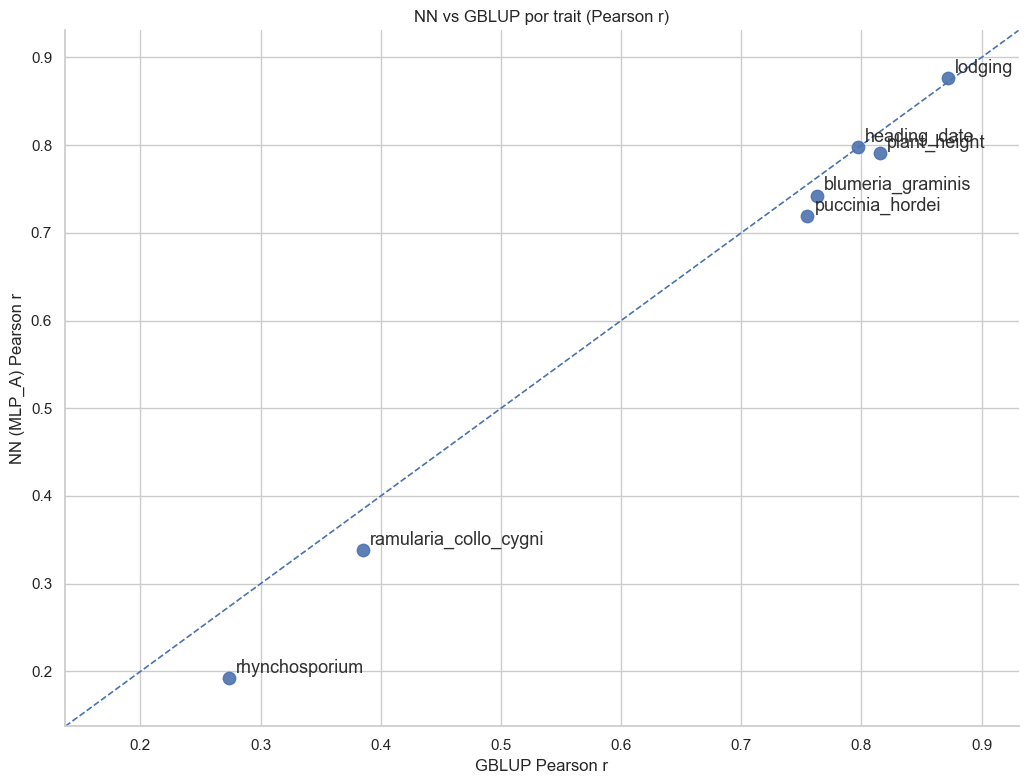

Guardado: outputs_nested5x3\_comparativas\scatter_nn_vs_gblup_pearson.png


,trait,gblup_r,nn_r
0,blumeria_graminis,0.763178,0.742517
1,heading_date,0.797251,0.798041
2,lodging,0.872372,0.876023
3,plant_height,0.815771,0.790891
4,puccinia_hordei,0.755101,0.718912
5,ramularia_collo_cygni,0.385151,0.338382
6,rhynchosporium,0.273948,0.192231


In [88]:
# Scatter NN vs GBLUP (mismo formato que el scatter anterior)
if summary_all.empty:
    print('[WARN] Sin summary_all para comparar.')
else:
    # Normalizar texto para evitar problema de intersección
    cmp = summary_all.copy()
    cmp['trait'] = cmp['trait'].astype(str).str.strip().str.lower()
    cmp['model'] = cmp['model'].astype(str).str.strip().str.lower()

    gblup_best = (
        cmp[cmp['model'] == 'gblup']
        .sort_values(['trait', 'pearson_r', 'r2', 'rmse'], ascending=[True, False, False, True])
        .groupby('trait', as_index=False)
        .first()[['trait', 'pearson_r']]
        .rename(columns={'pearson_r': 'gblup_r'})
    )

    nn_best = (
        cmp[(cmp['model'] == 'mlp_a') & (cmp['run_name'] == '72_nn_snp_nested5x3_mlp_a')]
        .sort_values(['trait', 'pearson_r', 'r2', 'rmse'], ascending=[True, False, False, True])
        .groupby('trait', as_index=False)
        .first()[['trait', 'pearson_r']]
        .rename(columns={'pearson_r': 'nn_r'})
    )

    nn_vs_gblup = gblup_best.merge(nn_best, on='trait', how='inner')

    if nn_vs_gblup.empty:
        print('[WARN] No hay intersección trait entre GBLUP y NN para scatter.')
    else:
        x = nn_vs_gblup['gblup_r']
        y = nn_vs_gblup['nn_r']

        xy_min = float(np.nanmin([x.min(), y.min()]))
        xy_max = float(np.nanmax([x.max(), y.max()]))
        pad = max(0.02, 0.08 * (xy_max - xy_min if xy_max > xy_min else 1.0))

        plt.figure(figsize=(10.5, 8.0))
        ax = plt.gca()
        ax.scatter(x, y, s=80, alpha=0.9)
        ax.plot([xy_min - pad, xy_max + pad], [xy_min - pad, xy_max + pad], linestyle='--', linewidth=1.2)

        for _, row in nn_vs_gblup.iterrows():
            ax.annotate(
                row['trait'],
                (row['gblup_r'], row['nn_r']),
                xytext=(5, 4),
                textcoords='offset points',
                fontsize=13,
                alpha=0.95
            )

        ax.set_xlim(xy_min - pad, xy_max + pad)
        ax.set_ylim(xy_min - pad, xy_max + pad)
        ax.set_xlabel('GBLUP Pearson r')
        ax.set_ylabel('NN (MLP_A) Pearson r')
        ax.set_title('NN vs GBLUP por trait (Pearson r)')
        sns.despine()
        plt.tight_layout()

        out_png = EXPORT_DIR / 'scatter_nn_vs_gblup_pearson.png'
        plt.savefig(out_png, dpi=300, bbox_inches='tight')
        plt.show()
        print('Guardado:', out_png)

        display(nn_vs_gblup.sort_values('trait'))


In [81]:
summary_all['run_name'].dropna().unique()


array(['10_pca20_svr_-_estructura_unificada_+_nested_cv_5x3',
       '11_pca50_svr_-_estructura_unificada_+_nested_cv_5x3',
       '20_pca20_tree_-_estructura_unificada_+_nested_cv_5x3',
       '21_pca50_tree_-_estructura_unificada_+_nested_cv_5x3',
       '40_pca20_ensemble_-_estructura_unificada_+_nested_cv_5x3',
       '40_pca50_ensemble_-_estructura_unificada_+_nested_cv_5x3',
       '45_pca20_blocks_-_estructura_unificada_+_nested_cv_5x3',
       '45_pca50_blocks_-_estructura_unificada_+_nested_cv_5x3',
       '53_snp_direct_legacy::snp_blocks_notebook_nested5x3',
       '54_snp_direct_gblup_legacy::snp_blocks_notebook_nested5x3_gblup',
       '72_nn_snp_nested5x3_mlp_a'], dtype=object)

In [82]:
# Tabla simple: Pearson GBLUP vs NN
if summary_all.empty:
    print('[WARN] Sin summary_all para comparar.')
else:
    cmp = summary_all.copy()
    cmp['trait'] = cmp['trait'].astype(str).str.strip().str.lower()
    cmp['model'] = cmp['model'].astype(str).str.strip().str.lower()

    gblup_best = (
        cmp[cmp['model'] == 'gblup']
        .sort_values(['trait', 'pearson_r', 'r2'], ascending=[True, False, False])
        .groupby('trait', as_index=False)
        .first()[['trait', 'pearson_r', 'r2']]
        .rename(columns={'pearson_r': 'gblup_r', 'r2': 'gblup_r2'})
    )

    nn_best = (
        cmp[(cmp['model'] == 'mlp_a') & (cmp['run_name'] == '72_nn_snp_nested5x3_mlp_a')]
        .sort_values(['trait', 'pearson_r', 'r2'], ascending=[True, False, False])
        .groupby('trait', as_index=False)
        .first()[['trait', 'pearson_r', 'r2']]
        .rename(columns={'pearson_r': 'nn_r', 'r2': 'nn_r2'})
    )

    gblup_vs_nn = gblup_best.merge(nn_best, on='trait', how='inner')
    gblup_vs_nn['delta_nn_minus_gblup'] = gblup_vs_nn['nn_r'] - gblup_vs_nn['gblup_r']

    display(gblup_vs_nn.sort_values('delta_nn_minus_gblup', ascending=False))


,trait,gblup_r,gblup_r2,nn_r,nn_r2,delta_nn_minus_gblup
2,lodging,0.872372,0.760624,0.876023,0.762001,0.003651
1,heading_date,0.797251,0.634926,0.798041,0.627648,0.000790
0,blumeria_graminis,0.763178,0.582337,0.742517,0.535497,-0.020661
3,plant_height,0.815771,0.665413,0.790891,0.596788,-0.024880
4,puccinia_hordei,0.755101,0.569889,0.718912,0.476069,-0.036189
5,ramularia_collo_cygni,0.385151,0.146777,0.338382,0.086338,-0.046769
6,rhynchosporium,0.273948,0.068389,0.192231,-0.273445,-0.081717


In [83]:
# Mejor resultado por modelo y trait (Pearson + R2)
if summary_all.empty:
    print('[WARN] Sin summary_all para comparar.')
else:
    cmp = summary_all.copy()
    cmp['trait'] = cmp['trait'].astype(str).str.strip().str.lower()
    cmp['model'] = cmp['model'].astype(str).str.strip().str.lower()

    best_by_model_trait = (
        cmp
        .sort_values(['trait', 'model', 'pearson_r', 'r2'], ascending=[True, True, False, False])
        .groupby(['trait', 'model'], as_index=False)
        .first()[['trait', 'model', 'representation', 'run_name', 'pearson_r', 'r2', 'rmse']]
        .sort_values(['trait', 'pearson_r'], ascending=[True, False])
    )

    display(best_by_model_trait)


,trait,model,representation,run_name,pearson_r,r2,rmse
3,blumeria_graminis,gblup,snp_direct,54_snp_direct_gblup_legacy::snp_blocks_noteboo...,0.763178,0.582337,0.752221
10,blumeria_graminis,xgboost,snp_direct,53_snp_direct_legacy::snp_blocks_notebook_nest...,0.748690,0.560421,0.771705
7,blumeria_graminis,ridge,snp_direct,53_snp_direct_legacy::snp_blocks_notebook_nest...,0.748370,0.559639,0.772391
5,blumeria_graminis,mlp_a,snp_direct,72_nn_snp_nested5x3_mlp_a,0.742517,0.535497,0.791472
2,blumeria_graminis,elasticnet,snp_direct,53_snp_direct_legacy::snp_blocks_notebook_nest...,0.735424,0.540195,0.789258
...,...,...,...,...,...,...,...
74,rhynchosporium,svr_linear,pca50,11_pca50_svr_-_estructura_unificada_+_nested_c...,0.190090,0.026812,0.902919
70,rhynchosporium,gradient_boosting,pca20,40_pca20_ensemble_-_estructura_unificada_+_nes...,0.186429,0.032549,0.900254
75,rhynchosporium,svr_rbf,pca20,10_pca20_svr_-_estructura_unificada_+_nested_c...,0.169679,0.019808,0.906162
66,rhynchosporium,adaboost,pca20,40_pca20_ensemble_-_estructura_unificada_+_nes...,0.163256,-0.042322,0.934440


## Comparativa 73 (PCA+MLP) vs 72 (MLP_A) y GBLUP

Bloque anadido al final para comparar de forma directa los resultados del cuaderno 73 frente a los baselines finales del proyecto.


In [84]:
# =========================
# Tabla comparativa 73 vs 72 vs GBLUP (Pearson, R2, RMSE)
# =========================
root_candidates = [
    Path('nested5x3_unificados'),
    Path('.'),
    Path.cwd() / 'nested5x3_unificados',
    Path.cwd(),
]

def resolve_project_root() -> Path:
    for c in root_candidates:
        if (c / 'results').exists():
            return c
    return root_candidates[0]

project_root = resolve_project_root()

p73_path = project_root / 'results' / 'nn_snp_pca_nested5x3' / 'nn_snp_pca_nested5x3_summary.csv'
p72_path = project_root / 'results' / 'nn_snp_nested5x3' / 'nn_snp_nested5x3_summary.csv'
pgb_path = project_root / 'results' / 'snp_blocks_notebook_nested5x3_gblup' / 'gblup_results.csv'

if not p73_path.exists():
    raise FileNotFoundError(f'No se encontro resumen del cuaderno 73: {p73_path}')

p73 = pd.read_csv(p73_path)[['trait', 'pearson_r_mean', 'r2_mean', 'rmse_mean']].copy()
p73 = p73.rename(columns={
    'pearson_r_mean': 'r_73_pca',
    'r2_mean': 'r2_73_pca',
    'rmse_mean': 'rmse_73_pca',
})

p73['trait'] = p73['trait'].astype(str).str.strip().str.lower()

# 72: primero desde summary_all (si existe), con fallback al CSV del run 72
p72 = pd.DataFrame()
if 'summary_all' in globals() and isinstance(summary_all, pd.DataFrame) and not summary_all.empty:
    tmp = summary_all.copy()
    tmp['trait'] = tmp['trait'].astype(str).str.strip().str.lower()
    tmp['model'] = tmp['model'].astype(str).str.strip().str.lower()

    p72 = (
        tmp[(tmp['model'] == 'mlp_a') & (tmp['run_name'] == '72_nn_snp_nested5x3_mlp_a')]
        .sort_values(['trait', 'pearson_r', 'r2', 'rmse'], ascending=[True, False, False, True])
        .groupby('trait', as_index=False)
        .first()[['trait', 'pearson_r', 'r2', 'rmse']]
        .rename(columns={'pearson_r': 'r_72_mlp_a', 'r2': 'r2_72_mlp_a', 'rmse': 'rmse_72_mlp_a'})
    )

if p72.empty:
    if not p72_path.exists():
        raise FileNotFoundError(f'No se encontro baseline 72 en summary_all ni en CSV: {p72_path}')
    p72 = pd.read_csv(p72_path)[['trait', 'pearson_r_mean', 'r2_mean', 'rmse_mean']].copy()
    p72 = p72.rename(columns={
        'pearson_r_mean': 'r_72_mlp_a',
        'r2_mean': 'r2_72_mlp_a',
        'rmse_mean': 'rmse_72_mlp_a',
    })
    p72['trait'] = p72['trait'].astype(str).str.strip().str.lower()

# GBLUP: primero desde summary_all (si existe), con fallback al CSV legacy
gblup = pd.DataFrame()
if 'summary_all' in globals() and isinstance(summary_all, pd.DataFrame) and not summary_all.empty:
    tmp = summary_all.copy()
    tmp['trait'] = tmp['trait'].astype(str).str.strip().str.lower()
    tmp['model'] = tmp['model'].astype(str).str.strip().str.lower()

    gblup = (
        tmp[tmp['model'] == 'gblup']
        .sort_values(['trait', 'pearson_r', 'r2', 'rmse'], ascending=[True, False, False, True])
        .groupby('trait', as_index=False)
        .first()[['trait', 'pearson_r', 'r2', 'rmse']]
        .rename(columns={'pearson_r': 'r_gblup', 'r2': 'r2_gblup', 'rmse': 'rmse_gblup'})
    )

if gblup.empty:
    if not pgb_path.exists():
        raise FileNotFoundError(f'No se encontro baseline GBLUP en summary_all ni en CSV: {pgb_path}')
    gblup = pd.read_csv(pgb_path)[['trait', 'pearson_r', 'r2', 'rmse']].copy()
    gblup = gblup.rename(columns={'pearson_r': 'r_gblup', 'r2': 'r2_gblup', 'rmse': 'rmse_gblup'})
    gblup['trait'] = gblup['trait'].astype(str).str.strip().str.lower()

cmp73 = p73.merge(p72, on='trait', how='inner').merge(gblup, on='trait', how='inner')

cmp73['delta_r_73_minus_72'] = cmp73['r_73_pca'] - cmp73['r_72_mlp_a']
cmp73['delta_r_73_minus_gblup'] = cmp73['r_73_pca'] - cmp73['r_gblup']
cmp73['delta_r2_73_minus_72'] = cmp73['r2_73_pca'] - cmp73['r2_72_mlp_a']
cmp73['delta_r2_73_minus_gblup'] = cmp73['r2_73_pca'] - cmp73['r2_gblup']
cmp73['delta_rmse_73_minus_72'] = cmp73['rmse_73_pca'] - cmp73['rmse_72_mlp_a']
cmp73['delta_rmse_73_minus_gblup'] = cmp73['rmse_73_pca'] - cmp73['rmse_gblup']

print('[73 vs 72 vs GBLUP] Tabla por trait:')
display(cmp73.sort_values('trait').reset_index(drop=True))

resumen_cmp73 = pd.DataFrame([{
    'mean_r_73': float(cmp73['r_73_pca'].mean()),
    'mean_r_72': float(cmp73['r_72_mlp_a'].mean()),
    'mean_r_gblup': float(cmp73['r_gblup'].mean()),
    'mean_delta_r_73_minus_72': float(cmp73['delta_r_73_minus_72'].mean()),
    'mean_delta_r_73_minus_gblup': float(cmp73['delta_r_73_minus_gblup'].mean()),
    'traits_73_better_than_72': int((cmp73['delta_r_73_minus_72'] > 0).sum()),
    'traits_73_better_than_gblup': int((cmp73['delta_r_73_minus_gblup'] > 0).sum()),
}])

print('[73 vs 72 vs GBLUP] Resumen global:')
display(resumen_cmp73)

cmp73_csv = EXPORT_DIR / 'tabla_73_vs_72_vs_gblup_por_trait.csv'
cmp73_summary_csv = EXPORT_DIR / 'tabla_73_vs_72_vs_gblup_resumen.csv'
cmp73.sort_values('trait').to_csv(cmp73_csv, index=False)
resumen_cmp73.to_csv(cmp73_summary_csv, index=False)
print('Guardado:', cmp73_csv)
print('Guardado:', cmp73_summary_csv)


[73 vs 72 vs GBLUP] Tabla por trait:


,trait,r_73_pca,r2_73_pca,rmse_73_pca,r_72_mlp_a,r2_72_mlp_a,rmse_72_mlp_a,r_gblup,r2_gblup,rmse_gblup,delta_r_73_minus_72,delta_r_73_minus_gblup,delta_r2_73_minus_72,delta_r2_73_minus_gblup,delta_rmse_73_minus_72,delta_rmse_73_minus_gblup
0,blumeria_graminis,0.712002,0.470701,0.844971,0.742517,0.535497,0.791472,0.763178,0.582337,0.752221,-0.030515,-0.051176,-0.064796,-0.111636,0.053499,0.092751
1,heading_date,0.774286,0.593633,20.136904,0.798041,0.627648,19.256234,0.797251,0.634926,19.199901,-0.023755,-0.022964,-0.034015,-0.041293,0.880670,0.937003
2,lodging,0.865690,0.729774,0.819361,0.876023,0.762001,0.768932,0.872372,0.760624,0.774439,-0.010333,-0.006681,-0.032227,-0.030850,0.050429,0.044923
3,plant_height,0.780727,0.597062,9.028096,0.790891,0.596788,9.036102,0.815771,0.665413,8.289570,-0.010164,-0.035044,0.000274,-0.068351,-0.008006,0.738526
4,puccinia_hordei,0.675632,0.426987,0.896089,0.718912,0.476069,0.855008,0.755101,0.569889,0.779544,-0.043280,-0.079469,-0.049082,-0.142902,0.041081,0.116544
5,ramularia_collo_cygni,0.304412,0.069203,1.079149,0.338382,0.086338,1.069353,0.385151,0.146777,1.035470,-0.033970,-0.080738,-0.017136,-0.077575,0.009797,0.043679
6,rhynchosporium,0.192365,-0.027453,0.912643,0.192231,-0.273445,1.020886,0.273948,0.068389,0.883421,0.000134,-0.081582,0.245991,-0.095843,-0.108243,0.029222


[73 vs 72 vs GBLUP] Resumen global:


,mean_r_73,mean_r_72,mean_r_gblup,mean_delta_r_73_minus_72,mean_delta_r_73_minus_gblup,traits_73_better_than_72,traits_73_better_than_gblup
0,0.615017,0.636714,0.66611,-0.021697,-0.051094,1,0


Guardado: outputs_nested5x3\_comparativas\tabla_73_vs_72_vs_gblup_por_trait.csv
Guardado: outputs_nested5x3\_comparativas\tabla_73_vs_72_vs_gblup_resumen.csv


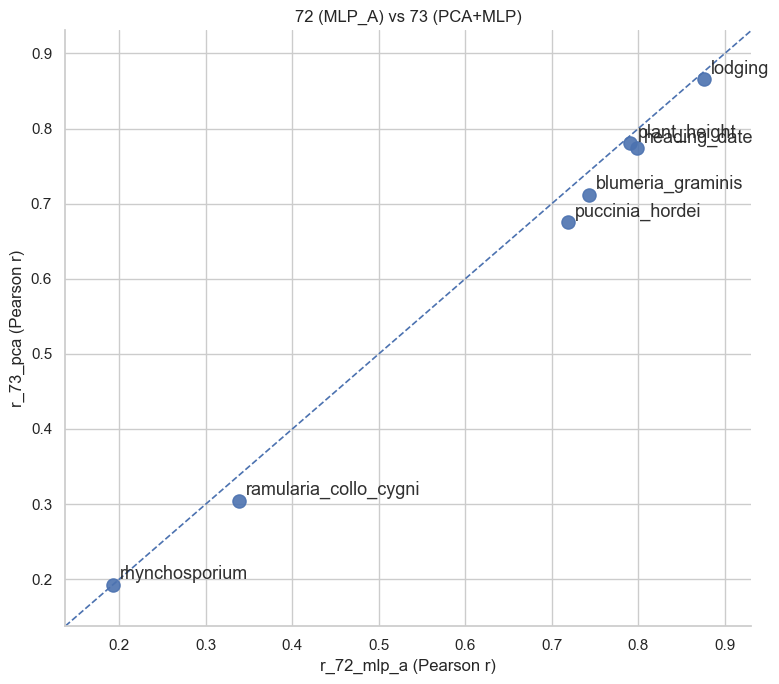

Guardado: outputs_nested5x3\_comparativas\scatter_72_vs_73_pearson.png


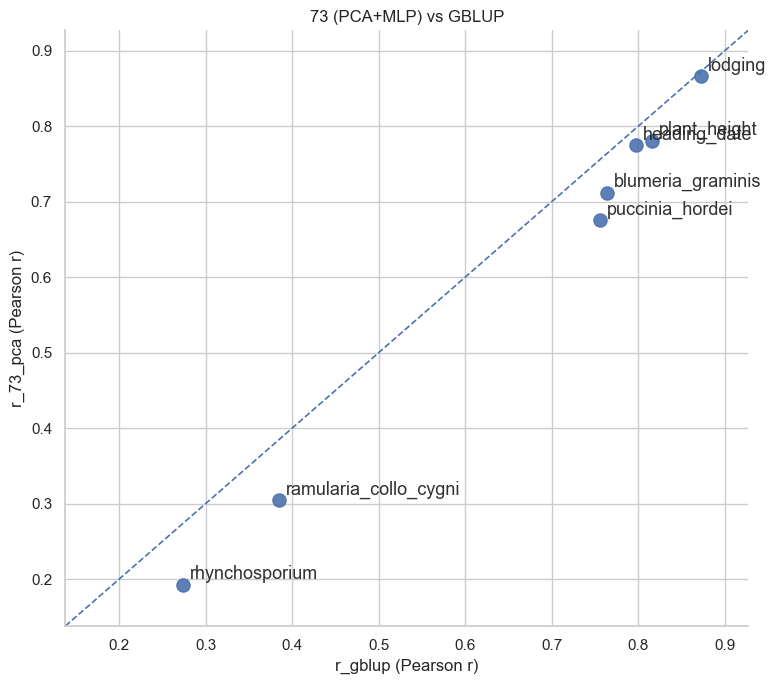

Guardado: outputs_nested5x3\_comparativas\scatter_73_vs_gblup_pearson.png


In [85]:
# =========================
# Scatterplots separados: 72 vs 73 y 73 vs GBLUP (Pearson por trait)
# =========================
if 'cmp73' not in globals() or cmp73.empty:
    print('[WARN] cmp73 no disponible para scatter.')
else:
    def _scatter_trait(df, xcol, ycol, title, out_name):
        x = df[xcol]
        y = df[ycol]

        xy_min = float(np.nanmin([x.min(), y.min()]))
        xy_max = float(np.nanmax([x.max(), y.max()]))
        pad = max(0.02, 0.08 * (xy_max - xy_min if xy_max > xy_min else 1.0))

        plt.figure(figsize=(8, 7))
        ax = plt.gca()
        ax.scatter(x, y, s=90, alpha=0.9)
        ax.plot([xy_min - pad, xy_max + pad], [xy_min - pad, xy_max + pad], linestyle='--', linewidth=1.2)

        for _, row in df.iterrows():
            ax.annotate(
                row['trait'],
                (row[xcol], row[ycol]),
                xytext=(5, 4),
                textcoords='offset points',
                fontsize=13,
                alpha=0.95,
            )

        ax.set_xlim(xy_min - pad, xy_max + pad)
        ax.set_ylim(xy_min - pad, xy_max + pad)
        ax.set_xlabel(f'{xcol} (Pearson r)')
        ax.set_ylabel(f'{ycol} (Pearson r)')
        ax.set_title(title)
        sns.despine()
        plt.tight_layout()

        out_png = EXPORT_DIR / out_name
        plt.savefig(out_png, dpi=300, bbox_inches='tight')
        plt.show()
        print('Guardado:', out_png)

    _scatter_trait(
        cmp73,
        xcol='r_72_mlp_a',
        ycol='r_73_pca',
        title='72 (MLP_A) vs 73 (PCA+MLP)',
        out_name='scatter_72_vs_73_pearson.png',
    )

    _scatter_trait(
        cmp73,
        xcol='r_gblup',
        ycol='r_73_pca',
        title='73 (PCA+MLP) vs GBLUP',
        out_name='scatter_73_vs_gblup_pearson.png',
    )
